In [1]:
import os
for v in ('OMP_NUM_THREADS', 'OPENBLAS_NUM_THREADS', 'MKL_NUM_THREADS',
          'VECLIB_MAXIMUM_THREADS', 'NUMEXPR_NUM_THREADS'):
    os.environ[v] = '1'
# then numpy / xso / ssh imports BELOW this line

In [2]:
import os, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import sys, os, time, warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
sys.path.insert(0, os.path.abspath('../model'))
sys.path.insert(0, os.path.abspath('../parameter_scan'))

sys.path.insert(0, os.path.abspath('results/'))

In [9]:
%config InlineBackend.figure_format = 'retina'
import seasonal_scan_harness as ssh, fig4_panels as f4
importlib_reload = __import__('importlib').reload; importlib_reload(ssh); importlib_reload(f4)
f4.set_style()

# Rebuild with (pre=0.4, post=0.1); preserves the old pickle's pre-side zoo coverage
# while addressing the post r_F=0 multistability/biological-defensibility issue.
D = f4.build_output(eras={'pre+recovery': 0.5, 'post': 0.1})
print(f"\nrebuilt with fish = {D['meta']['fish']}")

[fig4] model output saved -> /Users/aoop/Documents/GitHub/Research/SSMCariaco/plots/results/fig4_modeloutput.pkl
       {'construct': 'maranon_ward', 'params': {'GGE': 0.31, 'mP': 0.0015, 'm_Z': 0.1, 'KsZ': 0.23, 'sigma_log': 0.2}, 'fish': {'pre+recovery': 0.5, 'post': 0.1}, 'solver_floor': -0.001, 'regimes': None, 'forcing_complete': True, 'created': '2026-06-25 15:32'}

rebuilt with fish = {'pre+recovery': 0.5, 'post': 0.1}


[fig4] loaded /Users/aoop/Documents/GitHub/Research/SSMCariaco/plots/results/fig4_modeloutput.pkl
       {'construct': 'maranon_ward', 'params': {'GGE': 0.31, 'mP': 0.0015, 'm_Z': 0.1, 'KsZ': 0.23, 'sigma_log': 0.2}, 'fish': {'pre+recovery': 0.5, 'post': 0.1}, 'solver_floor': -0.001, 'regimes': None, 'forcing_complete': True, 'created': '2026-06-25 15:32'}


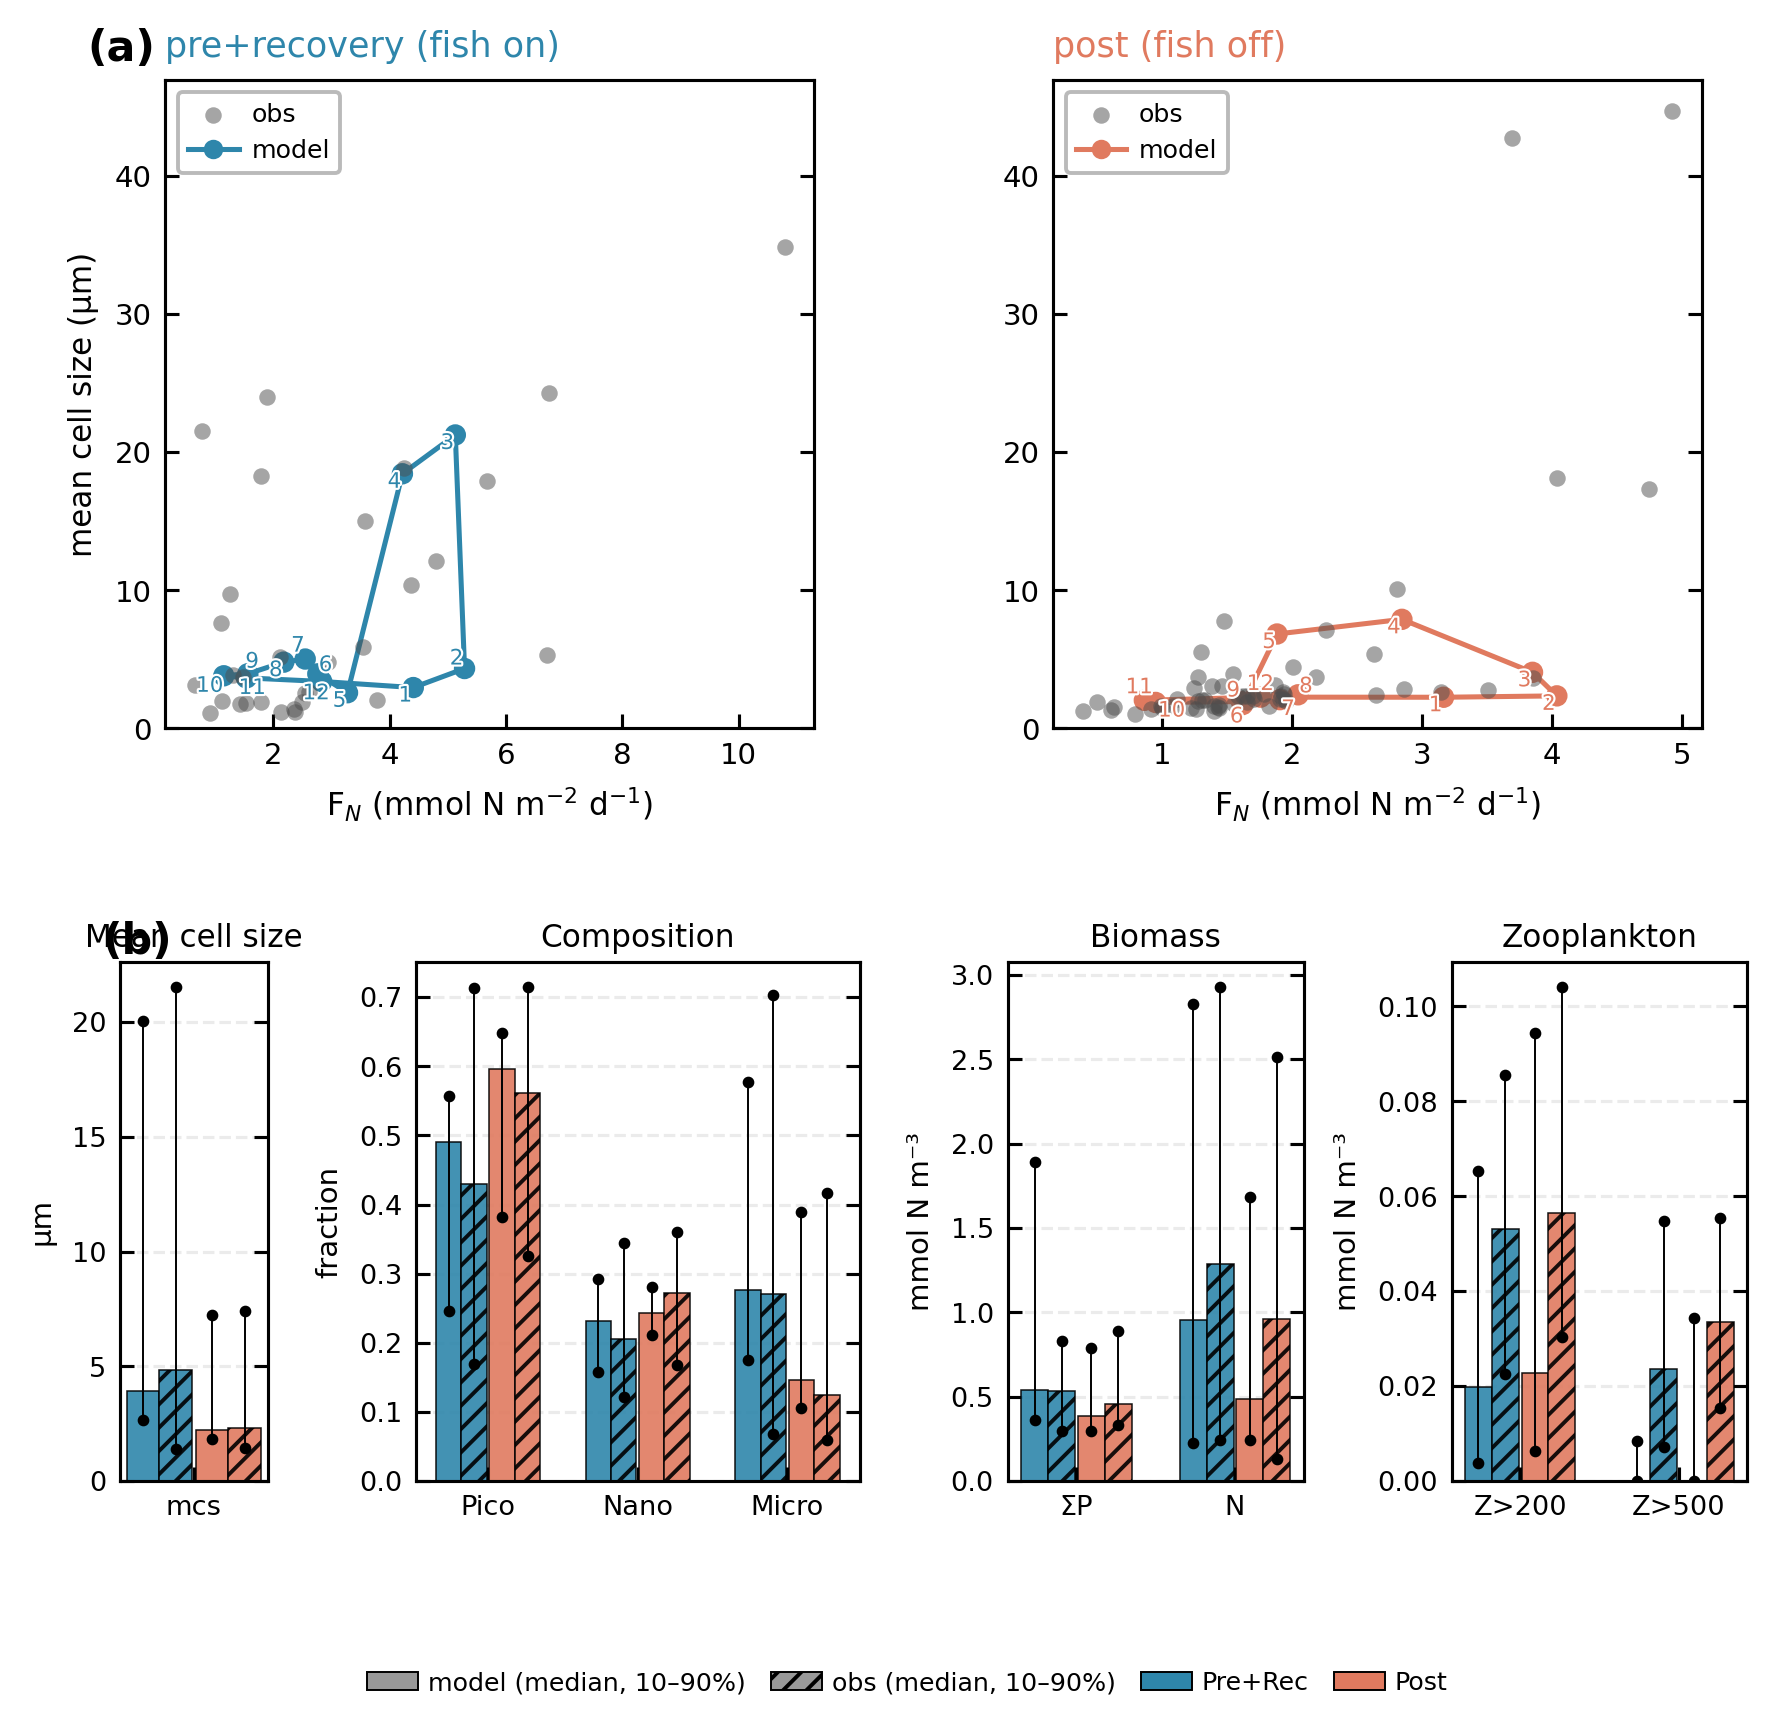


── Fig 4 composite diagnostics ──
Construct D: maranon_ward + Dutkiewicz Type III, GGE=0.31, mP=0.0015, m_Z=0.1, KsZ=0.23, σ=0.2
Fish: pre+rec r_F=0.5, post r_F=0.1
metric   era             obs_med  mod_med   ratio        obs 10-90%       mod 10-90% n_obs n_mod
────────────────────────────────────────────────────────────────────────────────────────────────
mcs      pre+recovery     4.8412   3.9016   0.806  [ 1.4103, 21.5385]  [ 2.6584, 20.0522]     31   540
mcs      post             2.3179   2.2384   0.966  [ 1.4243,  7.3929]  [ 1.8185,  7.2205]     57   540

Pico     pre+recovery     0.4291   0.4907   1.144  [ 0.1690,  0.7131]  [ 0.2465,  0.5566]     31   540
Pico     post             0.5617   0.5957   1.061  [ 0.3262,  0.7152]  [ 0.3826,  0.6481]     57   540
Nano     pre+recovery     0.2053   0.2318   1.129  [ 0.1212,  0.3450]  [ 0.1574,  0.2916]     31   540
Nano     post             0.2722   0.2433   0.894  [ 0.1682,  0.3596]  [ 0.2115,  0.2807]     57   540
Micro    pre+recovery

In [10]:
# ── Fig 4 COMPOSITE: phase plots (a) + model-vs-obs bars (b) ────────────
%config InlineBackend.figure_format = 'retina'
import numpy as np, matplotlib.pyplot as plt, matplotlib.patheffects as pe
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from matplotlib.gridspec import GridSpec
from adjustText import adjust_text
import fig4_panels as f4, seasonal_scan_harness as ssh

plt.rcParams.update({'figure.dpi': 140, 'savefig.dpi': 300, 'font.size': 9,
                     'axes.titlesize': 9, 'axes.labelsize': 8, 'legend.frameon': False})

# ══════════════════════════════════════════════════════════════════════════
#  BEHAVIOUR FLAGS
# ══════════════════════════════════════════════════════════════════════════
BOXPLOT              = False   # True → boxplots; False → bars + 10-90%
MARK_REGIMES         = False
SHOW_MISSING_FORCING = False
LOG_Y                = False
SHARE_X              = False
XLIM                 = None
OBS_C                = '0.30'
UM_TICKS             = [1, 2, 5, 10, 20, 40]

# ══════════════════════════════════════════════════════════════════════════
#  DATA
# ══════════════════════════════════════════════════════════════════════════
D     = f4.load_output()
obs_m = ssh.build_obs_monthly(['pre+recovery', 'post'], forcing_complete=not SHOW_MISSING_FORCING)

ERAS    = ['pre+recovery', 'post']
FISH    = D['meta']['fish']
ERA_COL = {'pre+recovery': '#2E86AB', 'post': '#E07A5F'}
ERA_LAB = {'pre+recovery': 'pre+recovery (fish on)', 'post': 'post (fish off)'}
ERA_SHORT = {'pre+recovery': 'Pre+Rec', 'post': 'Post'}
_MO     = np.arange(1, 13)
TINY    = [pe.withStroke(linewidth=0.6, foreground='white')]
LBLH    = [pe.withStroke(linewidth=1.1, foreground='white')]

runs  = {e: D['runs'][(e, FISH[e])][1] for e in ERAS}

# ── phase-plot helpers ──
def monthly(r, key, spin=15):
    keep = r['t'] >= spin * 365.0
    mo = np.clip(np.searchsorted(ssh._MEDGES, np.mod(r['t'][keep], 365.0), 'right') + 1, 1, 12)
    v = np.asarray(r[key], float)[keep]
    return np.array([np.nanmean(v[mo == m]) if np.any(mo == m) else np.nan for m in _MO])

def emptiest_corner(ax, P):
    x0, x1 = ax.get_xlim(); y0, y1 = ax.get_ylim()
    xm = 0.5*(x0+x1); ym = 0.5*(y0+y1)
    P = np.asarray(P, float); P = P[np.isfinite(P).all(1)]
    P = P[(P[:,0]>=x0)&(P[:,0]<=x1)&(P[:,1]>=y0)&(P[:,1]<=y1)]
    cnt = {'upper left':((P[:,0]<xm)&(P[:,1]>ym)).sum(),  'upper right':((P[:,0]>xm)&(P[:,1]>ym)).sum(),
           'lower left':((P[:,0]<xm)&(P[:,1]<ym)).sum(),  'lower right':((P[:,0]>xm)&(P[:,1]<ym)).sum()}
    return min(cnt, key=cnt.get)

fnmod = {e: monthly(runs[e], 'FN')  for e in ERAS}
mcmod = {e: monthly(runs[e], 'mcs') for e in ERAS}
allmcs = np.concatenate([obs_m[e]['mcs'].dropna().values for e in ERAS] +
                        [mcmod[e][np.isfinite(mcmod[e])] for e in ERAS])
TOP = allmcs.max() * 1.05
BOT = allmcs.min() * 0.90 if LOG_Y else 0.0
allfn = np.concatenate([fnmod[e][np.isfinite(fnmod[e])] for e in ERAS] +
                       [obs_m[e]['FN'].dropna().values for e in ERAS])
allfn = allfn[np.isfinite(allfn)]
_padx = 0.04 * (allfn.max() - allfn.min())
XBOUNDS = XLIM if XLIM is not None else ((allfn.min()-_padx, allfn.max()+_padx) if SHARE_X else None)

# ── bar/boxplot helpers (parscan_plots grammar) ──
def model_monthly_vals(r, key, spin=15):
    t = np.asarray(r['t'], float); keep = t >= spin * 365.0
    v = np.asarray(r[key], float)[keep]; tk = t[keep]
    mo = np.clip(np.searchsorted(ssh._MEDGES, np.mod(tk, 365.0), 'right') + 1, 1, 12)
    yr = (tk / 365.0).astype(int)
    return np.array([np.nanmean(v[(yr == y) & (mo == m)])
                     for y in np.unique(yr) for m in _MO
                     if np.any((yr == y) & (mo == m))])

def draw_bar(ax, x, vals, color, hatch=None, width=0.17):
    v = np.asarray(vals, float); v = v[np.isfinite(v)]
    if v.size == 0:
        ax.text(x, 0.02, 'no\ndata', transform=ax.get_xaxis_transform(),
                ha='center', va='bottom', fontsize=5.5, color='grey')
        return
    lo, hi = np.percentile(v, [10, 90])
    ax.bar(x, np.median(v), width, color=color, alpha=0.9, hatch=hatch,
           edgecolor='k', linewidth=0.4, zorder=2)
    ax.plot([x, x], [lo, hi], color='k', lw=0.5, zorder=4)
    ax.scatter([x, x], [lo, hi], color='k', s=4, zorder=5)

def draw_box(ax, x, vals, color, hatch=None, width=0.17):
    v = np.asarray(vals, float); v = v[np.isfinite(v)]
    if v.size == 0:
        return
    bp = ax.boxplot([v], positions=[x], widths=width*0.88,
                    patch_artist=True, showfliers=False, whis=[10, 90],
                    whiskerprops=dict(lw=0.6, color='k'),
                    capprops=dict(lw=0.6, color='k'),
                    medianprops=dict(color='k', lw=1.0))
    bp['boxes'][0].set(facecolor=color, alpha=0.9, edgecolor='k',
                       linewidth=0.5, hatch=hatch)

# ── metric distributions ──
BPANELS = [
    ('Mean cell size',  [('mcs',  'mcs',  'mcs')],                             'µm'),
    ('Composition',     [('Pico', 'pico', 'pico'), ('Nano', 'nano', 'nano'),
                         ('Micro','micro','micro')],                            'fraction'),
    ('Biomass',         [('ΣP',   'sumP', 'sumP'), ('N',    'N',    'N')],      'mmol N m⁻³'),
    ('Zooplankton',     [('Z>200','Z200', 'Z200'), ('Z>500','Z500', 'Z500')],   'mmol N m⁻³'),
]

dist = {}
for era in ERAS:
    for _, metrics, _ in BPANELS:
        for label, obs_col, mod_key in metrics:
            o = obs_m[era][obs_col].dropna().values.astype(float)
            m = model_monthly_vals(runs[era], mod_key)
            dist[(era, label)] = {'obs': o[np.isfinite(o)], 'mod': m[np.isfinite(m)]}

# ══════════════════════════════════════════════════════════════════════════
#  FIGURE LAYOUT
# ══════════════════════════════════════════════════════════════════════════
#  Row 0: (a1) phase pre+rec  |  (a2) phase post
#  Row 1: (b1) mcs  |  (b2) comp  |  (b3) biomass  |  (b4) zoo
# ══════════════════════════════════════════════════════════════════════════
fig = plt.figure(figsize=(7.5, 6.5))
gs = GridSpec(2, 4, figure=fig, height_ratios=[1, 0.8],
              width_ratios=[1, 3, 2, 2], hspace=0.40, wspace=0.50)

# row 0: phase plots span 2 columns each
ax_ph = [fig.add_subplot(gs[0, :2]), fig.add_subplot(gs[0, 2:])]
# row 1: one axis per bar-panel
ax_b = [fig.add_subplot(gs[1, j]) for j in range(4)]

# ── draw phase plots (row 0) ──
for ax, era, show_yl in zip(ax_ph, ERAS, [True, False]):
    col = ERA_COL[era]
    om  = obs_m[era].dropna(subset=['FN', 'mcs'])
    fn, mc = fnmod[era], mcmod[era]
    o = np.r_[np.arange(12), 0]
    ax.plot(fn[o], mc[o], '-', color=col, lw=1.3, zorder=3, path_effects=TINY)
    ax.plot(fn, mc, 'o', color=col, ms=4.5, zorder=4, path_effects=TINY)
    if MARK_REGIMES:
        reg = om['regime'].astype('object')
        norm = om[reg.isin(['upwelling','relaxed'])]
        tran = om[reg == 'transition']
        nanr = om[~reg.isin(['upwelling','relaxed','transition'])]
        ax.scatter(norm['FN'], norm['mcs'], s=18, color=OBS_C, alpha=0.5, lw=0, zorder=5, label='obs')
        if len(tran): ax.scatter(tran['FN'], tran['mcs'], s=28, facecolors='none', edgecolors=OBS_C, lw=1.1, zorder=6, label='transition')
        if len(nanr): ax.scatter(nanr['FN'], nanr['mcs'], s=18, marker='x', color='0.55', lw=0.9, zorder=6, label='unclassified')
    else:
        ax.scatter(om['FN'], om['mcs'], s=18, color=OBS_C, alpha=0.5, lw=0, zorder=5, label='obs')
    if LOG_Y:
        ax.set_yscale('log')
    ax.set_ylim(BOT, TOP)
    if LOG_Y:
        ticks = [t for t in UM_TICKS if BOT <= t <= TOP]
        ax.set_yticks(ticks); ax.set_yticklabels([str(t) for t in ticks])
        ax.yaxis.set_minor_formatter(plt.NullFormatter())
    if XBOUNDS is not None:
        ax.set_xlim(*XBOUNDS)
    ax.set_xlabel('F$_N$ (mmol N m$^{-2}$ d$^{-1}$)')
    ax.set_ylabel('mean cell size (µm)' if show_yl else '', fontsize=8)
    ax.set_title(ERA_LAB[era], fontsize=9, loc='left', color=col)
    ax.set_box_aspect(1)
    ax.tick_params(top=False, right=True, direction='in', labelsize=7.5)
    texts = [ax.text(fn[m-1], mc[m-1], str(m), fontsize=5.5, color=col, zorder=7,
                     ha='center', va='center', path_effects=LBLH) for m in _MO]
    adjust_text(texts, force_points=0.2, force_text=0.2, expand_points=(1,1), expand_text=(1,1),
                arrowprops=dict(arrowstyle='-', color=col, lw=0.5), ax=ax)
    h, l = ax.get_legend_handles_labels()
    h.append(Line2D([],[],color=col,marker='o',ms=4,lw=1.3)); l.append('model')
    P = np.vstack([om[['FN','mcs']].values, np.column_stack([fn, mc])])
    ax.legend(h, l, fontsize=6.5, loc=emptiest_corner(ax, P), frameon=True,
              edgecolor='0.7', framealpha=0.9, borderpad=0.4, handletextpad=0.5)

# ── draw bar/boxplot panels (row 1) ──
BAR_W = 0.17
DX_MOD = {'pre+recovery': -0.55*BAR_W - BAR_W,  'post':  0.55*BAR_W}
DX_OBS = {'pre+recovery': -0.55*BAR_W,          'post':  0.55*BAR_W + BAR_W}
draw = draw_box if BOXPLOT else draw_bar

for ax, (ptitle, metrics, ylabel) in zip(ax_b, BPANELS):
    xpos = np.arange(len(metrics))
    for i, (label, _, _) in enumerate(metrics):
        for era in ERAS:
            col = ERA_COL[era]
            draw(ax, i + DX_MOD[era], dist[(era, label)]['mod'],
                 color=col, hatch=None, width=BAR_W)
            draw(ax, i + DX_OBS[era], dist[(era, label)]['obs'],
                 color=col, hatch='////', width=BAR_W)
    ax.set_xticks(xpos)
    ax.set_xticklabels([m[0] for m in metrics], fontsize=7)
    ax.set_ylabel(ylabel, fontsize=7.5)
    ax.set_title(ptitle, fontsize=8, pad=4)
    ax.set_ylim(bottom=0)
    ax.tick_params(top=False, right=True, direction='in', labelsize=7)
    ax.grid(axis='y', ls='--', alpha=0.25, zorder=0)

# ── panel letters ──
for ax, letter in zip([ax_ph[0], ax_b[0]], ['(a)', '(b)']):
    ax.text(-0.12, 1.08, letter, transform=ax.transAxes,
            fontsize=11, fontweight='bold', va='top')

# ── shared legend for row 1 ──
leg_handles = [Patch(fc='0.6', ec='k', lw=0.5, label='model (median, 10–90%)'),
               Patch(fc='0.6', ec='k', lw=0.5, hatch='////', label='obs (median, 10–90%)')]
for era in ERAS:
    leg_handles.append(Patch(fc=ERA_COL[era], ec='k', lw=0.5, label=ERA_SHORT[era]))
fig.legend(handles=leg_handles, loc='lower center', ncol=4, fontsize=6.5,
           bbox_to_anchor=(0.5, -0.02), frameon=False,
           handletextpad=0.4, columnspacing=1.0)

#plt.savefig('fig4_composite_v1.pdf', bbox_inches='tight', dpi=300)
#plt.savefig('fig4_composite_v1.png', bbox_inches='tight', dpi=300)
plt.show()

# ══════════════════════════════════════════════════════════════════════════
#  DIAGNOSTIC TABLE
# ══════════════════════════════════════════════════════════════════════════
print("\n── Fig 4 composite diagnostics ──")
print(f"Construct D: maranon_ward + Dutkiewicz Type III, GGE=0.31, mP=0.0015, m_Z=0.1, KsZ=0.23, σ=0.2")
print(f"Fish: pre+rec r_F={FISH['pre+recovery']}, post r_F={FISH['post']}")
hdr = (f"{'metric':<8} {'era':<14} {'obs_med':>8} {'mod_med':>8} {'ratio':>7}  "
       f"{'obs 10-90%':>16} {'mod 10-90%':>16} {'n_obs':>5} {'n_mod':>5}")
print(hdr)
print("─" * len(hdr))
prev_p = None
for ptitle, metrics, _ in BPANELS:
    if prev_p is not None:
        print()
    prev_p = ptitle
    for label, _, _ in metrics:
        for era in ERAS:
            o, m = dist[(era, label)]['obs'], dist[(era, label)]['mod']
            om, mm = np.median(o), np.median(m)
            r = mm / om if om != 0 else np.nan
            olo, ohi = np.percentile(o, [10, 90]) if o.size else (np.nan, np.nan)
            mlo, mhi = np.percentile(m, [10, 90]) if m.size else (np.nan, np.nan)
            print(f"{label:<8} {era:<14} {om:8.4f} {mm:8.4f} {r:7.3f}  "
                  f"[{olo:7.4f}, {ohi:7.4f}]  [{mlo:7.4f}, {mhi:7.4f}]  {len(o):5d} {len(m):5d}")

print("\n── Phase-plot monthly climatology (model) ──")
print(f"{'era':<14} {'mo':>3} {'F_N':>7} {'mcs':>7}")
for era in ERAS:
    for m in _MO:
        print(f"{era:<14} {m:3d} {fnmod[era][m-1]:7.3f} {mcmod[era][m-1]:7.2f}")
    print()

[fig4] loaded /Users/aoop/Documents/GitHub/Research/SSMCariaco/plots/results/fig4_modeloutput.pkl
       {'construct': 'maranon_ward', 'params': {'GGE': 0.31, 'mP': 0.0015, 'm_Z': 0.1, 'KsZ': 0.23, 'sigma_log': 0.2}, 'fish': {'pre+recovery': 0.5, 'post': 0.1}, 'solver_floor': -0.001, 'regimes': None, 'forcing_complete': True, 'created': '2026-06-25 15:32'}


/var/folders/98/6c9k3fxx2hl5k0_928yjt7qw0000gn/T/ipykernel_1954/247297298.py:180: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


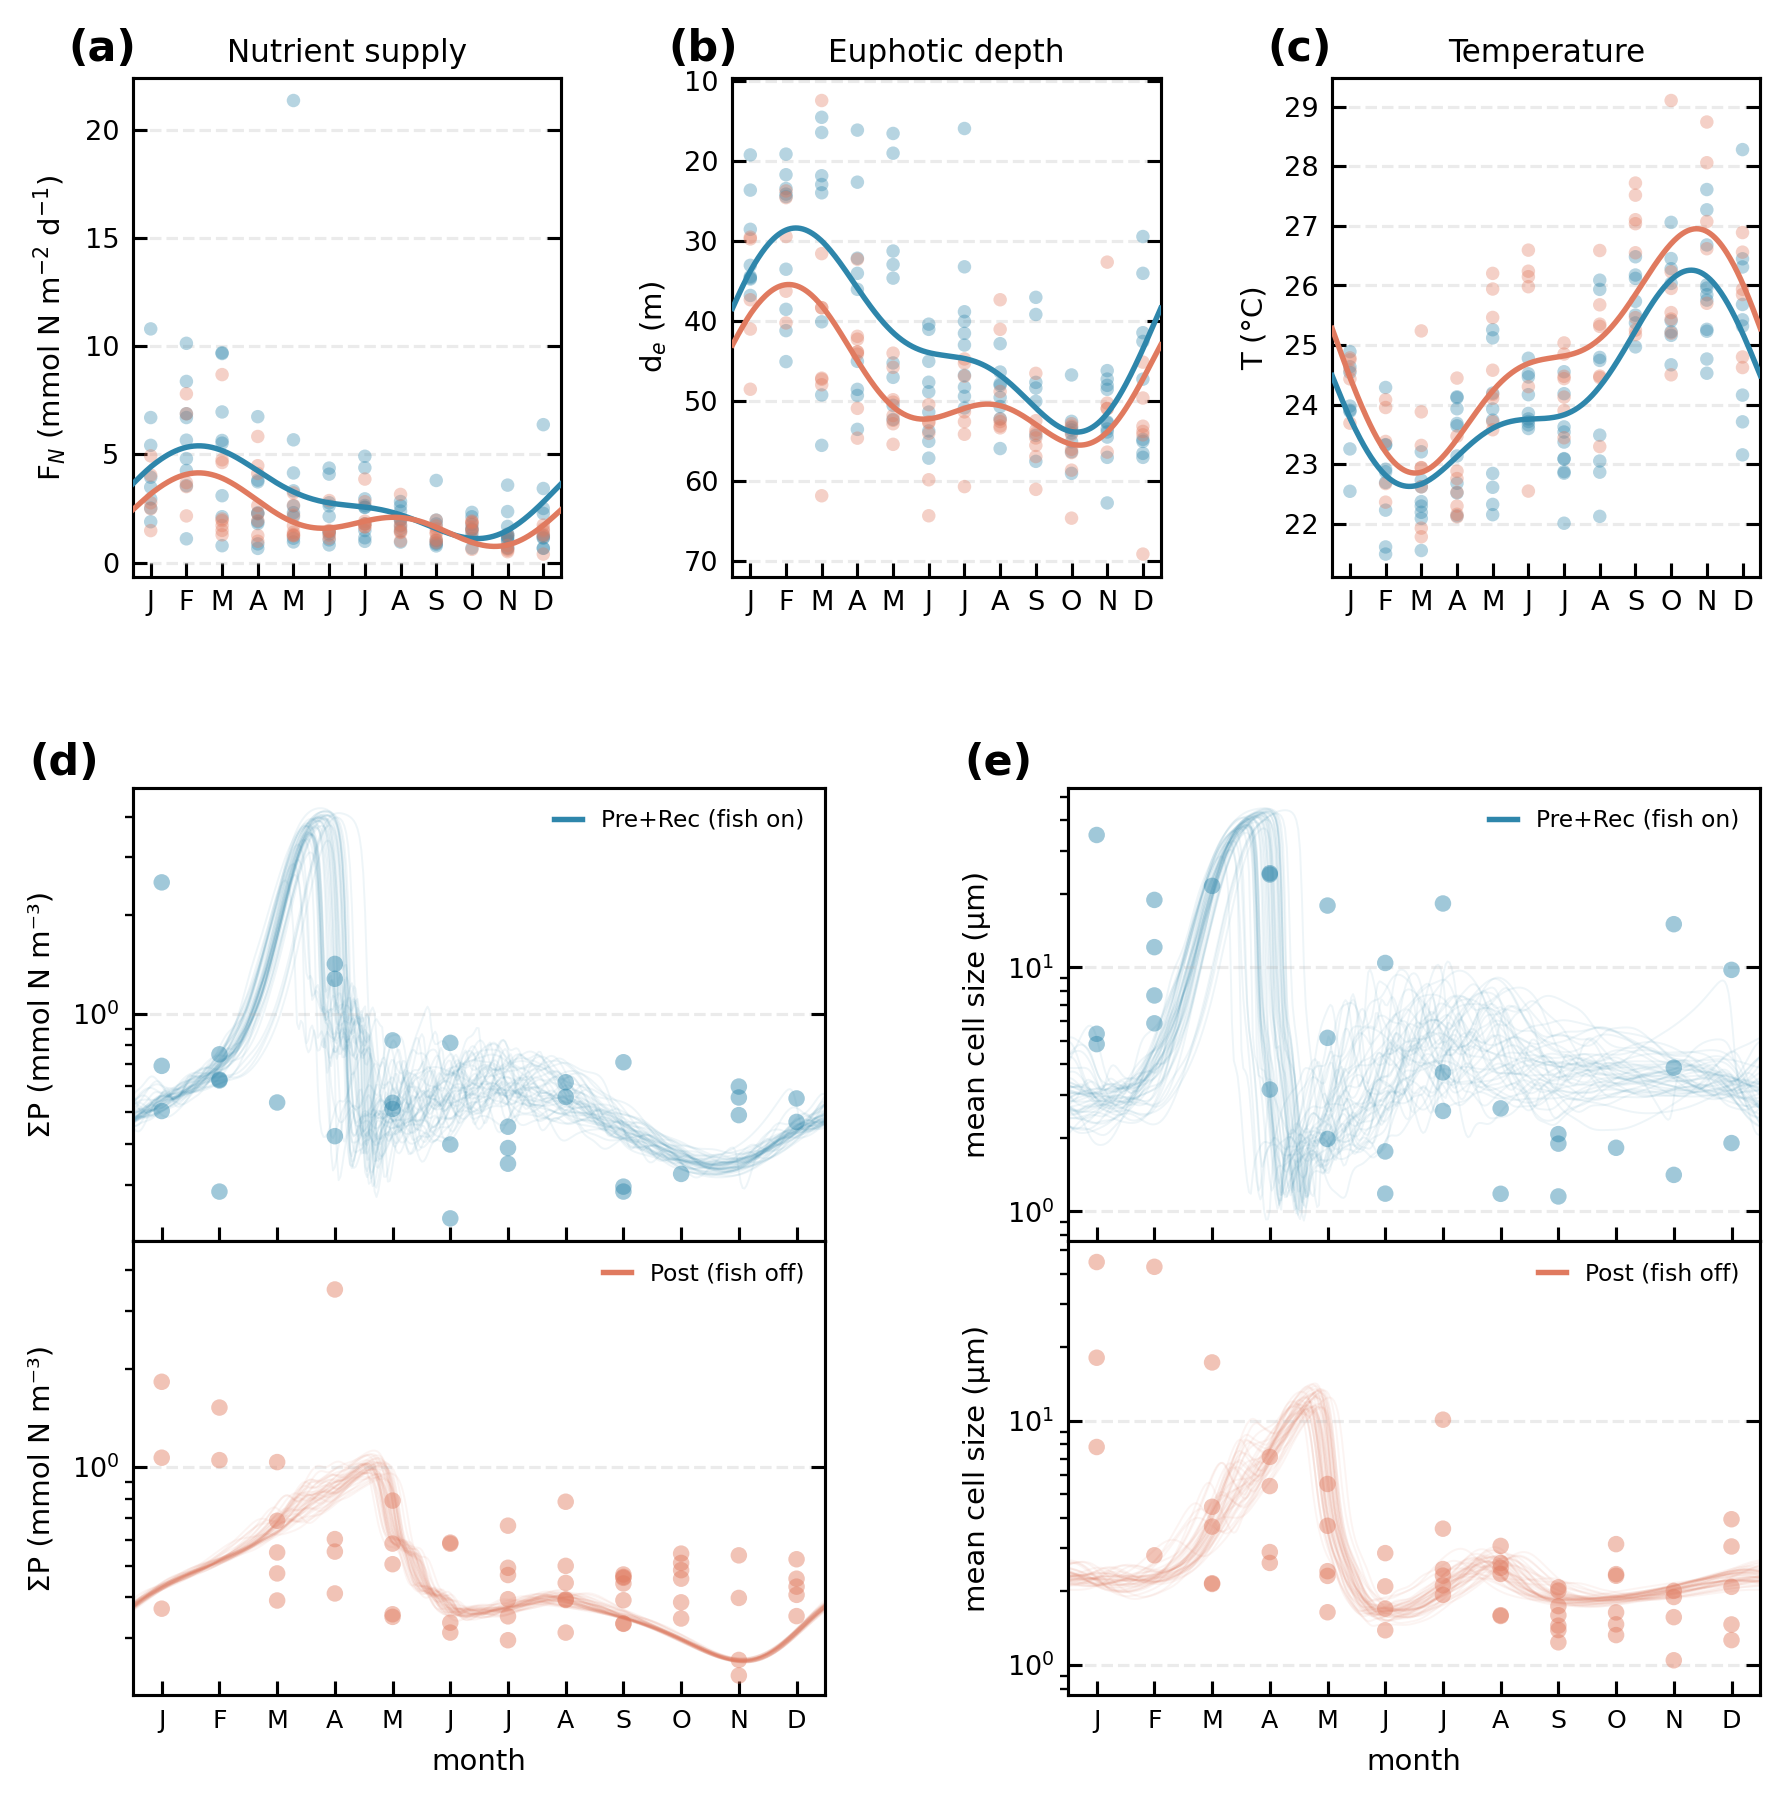


── Forcing + seasonal output diagnostics ──
Construct D: maranon_ward + Dutkiewicz Type III, GGE=0.31, mP=0.0015, m_Z=0.1, KsZ=0.23, σ=0.2
Fish: pre+rec r_F=0.5, post r_F=0.1
Forcing: 2-harmonic Fourier (N_HARMONICS=2)
Solver: {'method': 'RK45', 'atol': 1e-09, 'rtol': 1e-06, 'max_step': 1.0, 'instability_neg_threshold': -0.001}
Spinup: 15 yr dropped

── Forcing annual means (Fourier) ──
pre+recovery    F_N=3.063  d_e=42.1  T=24.22  F_N range=[1.10, 5.39]
post            F_N=2.202  d_e=47.6  T=24.87  F_N range=[0.74, 4.14]

── Model seasonal output (per-year annual means → median / mean / SD) ──
era            metric  ann_med ann_mean   ann_sd
pre+recovery   ΣP       0.7531   0.7534   0.0556
pre+recovery   mcs      6.4744   6.5192   0.7351

post           ΣP       0.4678   0.4679   0.0031
post           mcs      3.1532   3.1517   0.0518



In [11]:
# ── Forcing + Seasonal Model Output figure (v3: Fourier, stacked panels) ─
%config InlineBackend.figure_format = 'retina'
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.gridspec import GridSpec
import fig4_panels as f4, seasonal_scan_harness as ssh
from baseline_r0_seasonal_comps import _build_fourier_func, _MID_MONTH_DOY
from baseline_r0_seasonal_setups import N_HARMONICS, PERIOD

plt.rcParams.update({'figure.dpi': 140, 'savefig.dpi': 300, 'font.size': 9,
                     'axes.titlesize': 9, 'axes.labelsize': 8, 'legend.frameon': False})

# ══════════════════════════════════════════════════════════════════════════
#  BEHAVIOUR FLAGS
# ══════════════════════════════════════════════════════════════════════════
ALPHA_YEAR  = 0.08
ALPHA_OBS   = 0.45
ALPHA_FORC  = 0.35
SPINUP      = 15
MO_LABELS   = ['J','F','M','A','M','J','J','A','S','O','N','D']

# ══════════════════════════════════════════════════════════════════════════
#  DATA
# ══════════════════════════════════════════════════════════════════════════
D     = f4.load_output()
obs_m = ssh.build_obs_monthly(['pre+recovery', 'post'], forcing_complete=True)
forcings = ssh.build_forcings(['pre+recovery', 'post'])

ERAS    = ['pre+recovery', 'post']
#FISH    = {'pre+recovery': 0.5, 'post': 0.1}
ERA_COL = {'pre+recovery': '#2E86AB', 'post': '#E07A5F'}
ERA_LAB = {'pre+recovery': 'Pre+Rec (fish on)', 'post': 'Post (fish off)'}
_MO     = np.arange(1, 13)
_MEDGES = ssh._MEDGES

runs = {e: D['runs'][(e, FISH[e])][1] for e in ERAS}

# ── raw obs forcing (for scatter) ──
_csv = pd.read_csv(ssh.DEFAULT_CSV_PATH, parse_dates=['date'])
_csv['era'] = _csv['date'].dt.year.map(ssh.ERA_OF)
_csv['mo'] = _csv['date'].dt.month
obs_forc = {}
for era in ERAS:
    mask = _csv['era'].isin(ssh.GROUP_ERAS[era])
    obs_forc[era] = _csv[mask][['mo', 'FN_mmolN_m2_d', 'depth_cutoff', 'Temp_C']].dropna()

# ── smooth forcing curves (daily, 2-harmonic Fourier) ──
t_day = np.linspace(0, 365, 366)
mo_of_day = np.interp(t_day,
                       np.r_[0, _MID_MONTH_DOY, 365],
                       np.r_[0.5, _MO.astype(float), 12.5])
forc_curves = {}
for era in ERAS:
    f = forcings[era]
    forc_curves[era] = {
        'FN': _build_fourier_func(f['fn'], PERIOD, N_HARMONICS)(t_day),
        'de': _build_fourier_func(f['de'], PERIOD, N_HARMONICS)(t_day),
        'T':  _build_fourier_func(f['t'],  PERIOD, N_HARMONICS)(t_day),
    }

# ── per-year daily traces ──
def per_year_daily(r, key, spinup=SPINUP):
    t = np.asarray(r['t'], float); keep = t >= spinup * 365.0
    v = np.asarray(r[key], float)[keep]; tk = t[keep]
    doy = np.mod(tk, 365.0)
    yr = (tk / 365.0).astype(int)
    traces = []
    for y in np.unique(yr):
        m = yr == y
        order = np.argsort(doy[m])
        traces.append((doy[m][order], v[m][order]))
    return traces

def doy_to_mo(doy):
    return np.interp(doy, np.r_[0, _MID_MONTH_DOY, 365],
                     np.r_[0.5, _MO.astype(float), 12.5])

# ══════════════════════════════════════════════════════════════════════════
#  FIGURE: Row 0 = forcing (a,b,c).  Rows 1-2 = stacked output pairs:
#    (d) = ΣP (pre top, post bottom, zero gap)
#    (e) = mcs (pre top, post bottom, zero gap)
# ══════════════════════════════════════════════════════════════════════════
fig = plt.figure(figsize=(7.5, 7.5))

# outer grid: row 0 = forcing, row 1 = output pairs
outer = GridSpec(2, 1, figure=fig, height_ratios=[0.55, 1.0],
                hspace=0.30)

# row 0: 3 forcing panels
gs_forc = outer[0].subgridspec(1, 3, wspace=0.40)
ax_fn = fig.add_subplot(gs_forc[0])
ax_de = fig.add_subplot(gs_forc[1])
ax_t  = fig.add_subplot(gs_forc[2])

# row 1: two stacked pairs side by side, zero vertical gap
gs_out = outer[1].subgridspec(1, 2, wspace=0.35)
gs_sp  = gs_out[0].subgridspec(2, 1, hspace=0.0)   # ΣP: pre on top, post below
gs_mc  = gs_out[1].subgridspec(2, 1, hspace=0.0)   # mcs: pre on top, post below

ax_sp_pre  = fig.add_subplot(gs_sp[0])
ax_sp_post = fig.add_subplot(gs_sp[1], sharex=ax_sp_pre)
ax_mc_pre  = fig.add_subplot(gs_mc[0])
ax_mc_post = fig.add_subplot(gs_mc[1], sharex=ax_mc_pre)

# ── Row 0: forcing (Fourier curves + obs scatter) ───────────────────────
forcing_info = [
    (ax_fn, 'FN', 'FN_mmolN_m2_d', 'F$_N$ (mmol N m$^{-2}$ d$^{-1}$)', 'Nutrient supply',  False),
    (ax_de, 'de', 'depth_cutoff',   'd$_e$ (m)',                          'Euphotic depth',    True),
    (ax_t,  'T',  'Temp_C',         'T (°C)',                             'Temperature',       False),
]

for ax, fkey, obs_col, ylabel, title, invert in forcing_info:
    for era in ERAS:
        col = ERA_COL[era]
        ax.plot(mo_of_day, forc_curves[era][fkey], '-', color=col, lw=1.4, zorder=3)
        of = obs_forc[era]
        ax.scatter(of['mo'], of[obs_col], s=12, color=col, alpha=ALPHA_FORC,
                   edgecolors='none', zorder=2)
    ax.set_xlim(0.5, 12.5)
    ax.set_xticks(_MO)
    ax.set_xticklabels(MO_LABELS, fontsize=6.5)
    ax.set_ylabel(ylabel, fontsize=7.5)
    ax.set_title(title, fontsize=8, pad=4)
    if invert:
        ax.invert_yaxis()
    ax.tick_params(top=False, right=True, direction='in', labelsize=7)
    ax.grid(axis='y', ls='--', alpha=0.25, zorder=0)

# ── Rows 1-2: output (stacked, in-panel legends) ────────────────────────
output_panels = [
    (ax_sp_pre,  'pre+recovery', 'sumP', 'ΣP (mmol N m⁻³)'),
    (ax_sp_post, 'post',         'sumP', 'ΣP (mmol N m⁻³)'),
    (ax_mc_pre,  'pre+recovery', 'mcs',  'mean cell size (µm)'),
    (ax_mc_post, 'post',         'mcs',  'mean cell size (µm)'),
]

for ax, era, mod_key, ylabel in output_panels:
    col = ERA_COL[era]
    # per-year daily traces
    traces = per_year_daily(runs[era], mod_key)
    for doy, vals in traces:
        ax.plot(doy_to_mo(doy), vals, '-', color=col, alpha=ALPHA_YEAR, lw=0.5, zorder=1)
    # obs scatter
    om = obs_m[era].dropna(subset=[mod_key])
    ax.scatter(om['mo'], om[mod_key], s=18, color=col, alpha=ALPHA_OBS,
               edgecolors='none', zorder=2)
    ax.set_xlim(0.5, 12.5)
    ax.set_xticks(_MO)
    ax.set_ylabel(ylabel, fontsize=7.5)
    ax.set_yscale('log')
    ax.tick_params(top=False, right=True, direction='in', labelsize=7)
    ax.grid(axis='y', ls='--', alpha=0.25, zorder=0)
    # in-panel legend (era label)
    ax.legend([Line2D([], [], color=col, lw=1.4)], [ERA_LAB[era]],
              fontsize=6, loc='upper right', handlelength=1.2)

# top panels: hide x ticks/labels
for ax in [ax_sp_pre, ax_mc_pre]:
    plt.setp(ax.get_xticklabels(), visible=False)
    ax.tick_params(labelbottom=False)
# bottom panels: show x ticks/labels
for ax in [ax_sp_post, ax_mc_post]:
    ax.set_xticklabels(MO_LABELS, fontsize=6.5)
    ax.set_xlabel('month', fontsize=7.5)

# shared y-range within each stacked pair
for ax_top, ax_bot in [(ax_sp_pre, ax_sp_post), (ax_mc_pre, ax_mc_post)]:
    ylo = min(ax_top.get_ylim()[0], ax_bot.get_ylim()[0])
    yhi = max(ax_top.get_ylim()[1], ax_bot.get_ylim()[1])
    ax_top.set_ylim(ylo, yhi)
    ax_bot.set_ylim(ylo, yhi)

# ── panel letters ──
panels_letters = [(ax_fn, '(a)'), (ax_de, '(b)'), (ax_t, '(c)'),
                  (ax_sp_pre, '(d)'), (ax_mc_pre, '(e)')]
for ax, letter in panels_letters:
    ax.text(-0.15, 1.10, letter, transform=ax.transAxes,
            fontsize=11, fontweight='bold', va='top')

fig.tight_layout()
plt.savefig('fig_forcing_seasonal_v3.pdf', bbox_inches='tight', dpi=300)
plt.savefig('fig_forcing_seasonal_v3.png', bbox_inches='tight', dpi=300)
plt.show()

# ══════════════════════════════════════════════════════════════════════════
#  DIAGNOSTICS
# ══════════════════════════════════════════════════════════════════════════
print("\n── Forcing + seasonal output diagnostics ──")
print(f"Construct D: maranon_ward + Dutkiewicz Type III, GGE=0.31, mP=0.0015, m_Z=0.1, KsZ=0.23, σ=0.2")
print(f"Fish: pre+rec r_F={FISH['pre+recovery']}, post r_F={FISH['post']}")
print(f"Forcing: 2-harmonic Fourier (N_HARMONICS={N_HARMONICS})")
print(f"Solver: {ssh.SEASONAL_SOLVER_KWARGS}")
print(f"Spinup: {SPINUP} yr dropped\n")

print("── Forcing annual means (Fourier) ──")
for era in ERAS:
    fn_c = forc_curves[era]['FN']
    de_c = forc_curves[era]['de']
    t_c  = forc_curves[era]['T']
    print(f"{era:<14}  F_N={fn_c.mean():.3f}  d_e={de_c.mean():.1f}  T={t_c.mean():.2f}"
          f"  F_N range=[{fn_c.min():.2f}, {fn_c.max():.2f}]")

print("\n── Model seasonal output (per-year annual means → median / mean / SD) ──")
print(f"{'era':<14} {'metric':<6} {'ann_med':>8} {'ann_mean':>8} {'ann_sd':>8}")
for era in ERAS:
    for mod_key, label in [('sumP', 'ΣP'), ('mcs', 'mcs')]:
        t = np.asarray(runs[era]['t'], float); keep = t >= SPINUP * 365.0
        v = np.asarray(runs[era][mod_key], float)[keep]; tk = t[keep]
        yr = (tk / 365.0).astype(int)
        ann = np.array([np.nanmean(v[yr == y]) for y in np.unique(yr)])
        print(f"{era:<14} {label:<6} {np.median(ann):8.4f} {np.mean(ann):8.4f} {np.std(ann):8.4f}")
    print()

[fig4] loaded /Users/aoop/Documents/GitHub/Research/SSMCariaco/plots/results/fig4_modeloutput.pkl
       {'construct': 'maranon_ward', 'params': {'GGE': 0.31, 'mP': 0.0015, 'm_Z': 0.1, 'KsZ': 0.23, 'sigma_log': 0.2}, 'fish': {'pre+recovery': 0.5, 'post': 0.1}, 'solver_floor': -0.001, 'regimes': None, 'forcing_complete': True, 'created': '2026-06-25 15:32'}
pickle fish rates: {'pre+recovery': 0.5, 'post': 0.1}



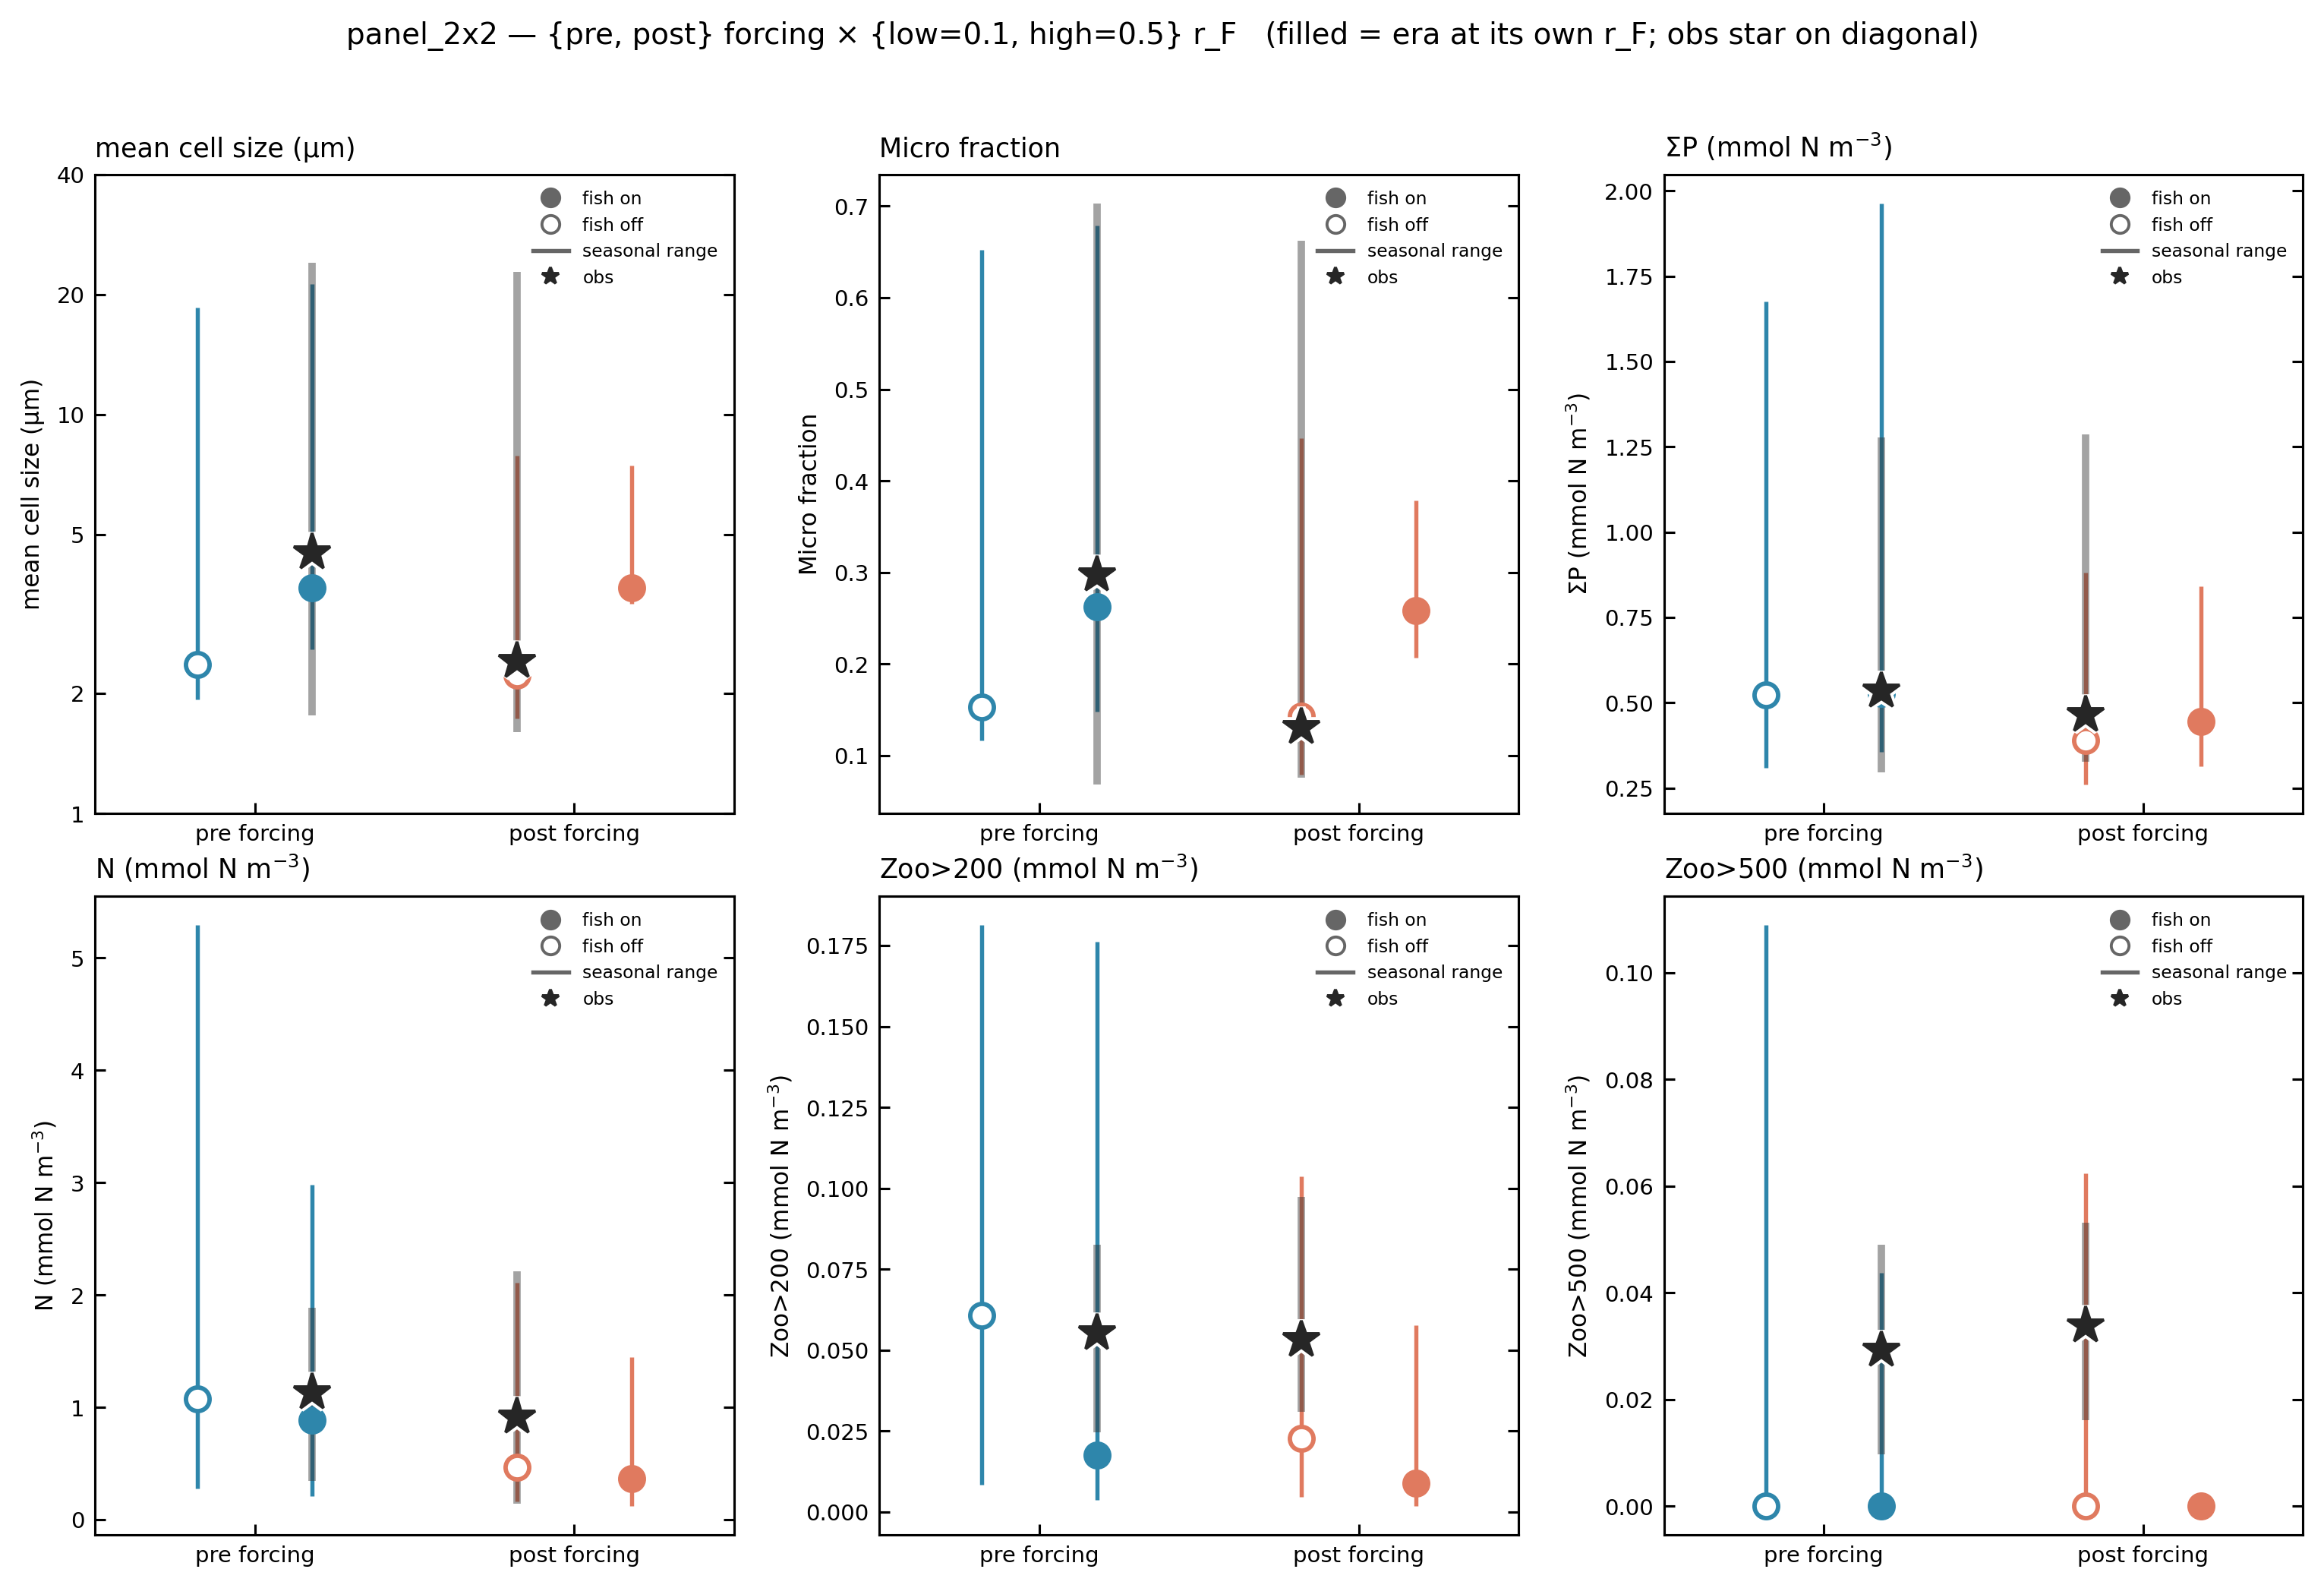


metric  cell                         r_F   mod_med   obs_med (diag only)
------------------------------------------------------------------------
mcs     ○ counter pre+recovery      0.10    2.3630                     —
mcs     ◆ diag pre+recovery         0.50    3.6749                4.8412
mcs     ◆ diag post                 0.10    2.2219                2.3179
mcs     ○ counter post              0.50    3.6736                     —

micro   ○ counter pre+recovery      0.10    0.1527                     —
micro   ◆ diag pre+recovery         0.50    0.2624                0.2706
micro   ◆ diag post                 0.10    0.1435                0.1239
micro   ○ counter post              0.50    0.2587                     —

sumP    ○ counter pre+recovery      0.10    0.5234                     —
sumP    ◆ diag pre+recovery         0.50    0.5274                0.5349
sumP    ◆ diag post                 0.10    0.3887                0.4589
sumP    ○ counter post              0.50    0.44

In [12]:
import matplotlib.pyplot as plt

# Use whatever pickle you just rebuilt
D = f4.load_output()
print(f"pickle fish rates: {D['meta']['fish']}\n")

metrics = ['mcs', 'micro', 'sumP', 'N', 'Z200', 'Z500']
nrows, ncols = 2, 3
fig, axes = plt.subplots(nrows, ncols, figsize=(11.0, 7.5))

for ax, m in zip(axes.flat, metrics):
    f4.panel_2x2(ax, D, metric=m)
    ax.set_title(f4.MLAB.get(m, m), fontsize=9, loc='left')

high = max(D['meta']['fish'].values())
low  = min(D['meta']['fish'].values())
fig.suptitle(f"panel_2x2 — {{pre, post}} forcing × {{low={low}, high={high}}} r_F   "
             f"(filled = era at its own r_F; obs star on diagonal)",
             fontsize=10)
fig.tight_layout(rect=(0, 0, 1, 0.96))
plt.show()

# numerical read-off — the four diagonal/off-diagonal medians per metric
print(f"\n{'metric':<8}{'cell':<26}{'r_F':>6}{'mod_med':>10}{'obs_med (diag only)':>22}")
print("-" * 72)
for m in metrics:
    om_pre  = float(D['obs_m']['pre+recovery'][m].median()) if m in D['obs_m']['pre+recovery'].columns else float('nan')
    om_post = float(D['obs_m']['post'][m].median())         if m in D['obs_m']['post'].columns          else float('nan')
    for era in ('pre+recovery', 'post'):
        for fish in sorted(set(D['meta']['fish'].values())):
            tag = '◆ diag' if fish == D['meta']['fish'][era] else '○ counter'
            obs_str = (f"{om_pre:.4f}" if era=='pre+recovery' else f"{om_post:.4f}") if tag.startswith('◆') else '—'
            md = D['runs'][(era, fish)][0].get(m + '_med', float('nan'))
            print(f"{m:<8}{tag+' '+era:<26}{fish:>6.2f}{md:>10.4f}{obs_str:>22}")
    print()

In [10]:
# ── Forcing + seasonal model output figure (v3: Fourier forcing) ─────────
# Row 0: forcing splines (now 2-harmonic Fourier) + obs scatter
# Rows 1-2: per-era daily trajectories (ΣP, mcs) + obs scatter
# ─────────────────────────────────────────────────────────────────────────
%config InlineBackend.figure_format = 'retina'
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import seasonal_scan_harness as ssh
from baseline_r0_seasonal_comps import _build_fourier_func, _MID_MONTH_DOY  # CHANGED
from baseline_r0_seasonal_setups import N_HARMONICS, PERIOD                 # CHANGED

plt.rcParams.update({'figure.dpi': 140, 'savefig.dpi': 200, 'font.size': 9,
                     'axes.titlesize': 9, 'axes.labelsize': 8, 'legend.frameon': False})

# ── FLAGS ────────────────────────────────────────────────────────────────
ALPHA_YEAR = 0.08       # per-year trajectory alpha
SAVE       = True       # save PDF + PNG
SAVE_STEM  = 'fig_forcing_seasonal_v3'

# ── DATA ─────────────────────────────────────────────────────────────────
import pickle, os
PKL = os.path.join(os.path.dirname(ssh.__file__), 'results', 'fig4_modeloutput.pkl')
with open(PKL, 'rb') as f:
    D = pickle.load(f)

ERAS     = ['pre+recovery', 'post']
ERA_COL  = {'pre+recovery': '#2E86AB', 'post': '#E07A5F'}
ERA_LAB  = {'pre+recovery': 'Pre+Rec', 'post': 'Post'}
ERA_FISH = {'pre+recovery': 0.4, 'post': 0.0}
SPINUP   = 15
_MO      = np.arange(1, 13)
_MEDGES  = np.cumsum([31, 28, 31, 30, 31, 30, 31, 31, 30, 31, 30, 31])

forcings = ssh.build_forcings(ERAS)
obs_m    = {era: ssh.build_obs_monthly([era]) for era in ERAS}

# ── helpers ──────────────────────────────────────────────────────────────
def doy_to_mo(doy):
    return np.interp(doy, np.r_[0, _MID_MONTH_DOY, 365],
                     np.r_[0.5, _MO.astype(float), 12.5])

def per_year_daily(r, key, spinup=SPINUP):
    """Per-year daily trajectories (list of (mo_axis, values) per year)."""
    t = r['t']; vals = r[key]
    years_out = []
    for yr_start in range(spinup * 365, int(t[-1]), 365):
        mask = (t >= yr_start) & (t < yr_start + 365)
        if mask.sum() < 300:
            continue
        doy = t[mask] - yr_start
        years_out.append((doy_to_mo(doy), vals[mask]))
    return years_out

def _style(ax):
    ax.tick_params(top=False, right=True, direction='in', labelsize=7)
    ax.grid(axis='y', ls='--', alpha=0.25, zorder=0)

# ══════════════════════════════════════════════════════════════════════════
#  FIGURE: 3 rows × 6 cols via GridSpec
#  Row 0 (a-c): F_N, d_e, T — forcing + obs scatter
#  Row 1 (d,e): ΣP per era (pre+rec top, post row 2)
#  Row 2 (f,g): mcs per era
# ══════════════════════════════════════════════════════════════════════════
fig = plt.figure(figsize=(10, 9))
gs = GridSpec(3, 6, figure=fig, height_ratios=[0.8, 1, 1],
              hspace=0.35, wspace=0.4)

# ── row 0: forcing ──────────────────────────────────────────────────────
t_day = np.linspace(0, 365, 366)
mo_day = doy_to_mo(t_day)

forcing_specs = [
    ('fn',  'FN_mmolN_m2_d', 'F$_N$ (mmol N m$^{-2}$ d$^{-1}$)', False),
    ('de',  'depth_cutoff',  'd$_e$ (m)',                          True),
    ('t',   'Temp_C',        'T (°C)',                             False),
]
panel_letters = list('abcdefg')
pl_idx = 0

csv_raw = pd.read_csv(ssh.DEFAULT_CSV_PATH, parse_dates=['date'])
csv_raw['era'] = csv_raw['date'].dt.year.map(ssh.ERA_OF)
csv_raw['mo']  = csv_raw['date'].dt.month

for j, (fkey, obs_col, ylabel, invert) in enumerate(forcing_specs):
    ax = fig.add_subplot(gs[0, j*2:(j+1)*2])
    for era in ERAS:
        col = ERA_COL[era]
        monthly = forcings[era][fkey]
        # CHANGED: Fourier instead of spline
        fn_func = _build_fourier_func(monthly, PERIOD, N_HARMONICS)
        ax.plot(mo_day, fn_func(t_day), '-', color=col, lw=1.4, zorder=4,
                label=ERA_LAB[era])
        # obs scatter
        emask = csv_raw['era'].isin(ssh.GROUP_ERAS[era])
        ax.scatter(csv_raw.loc[emask, 'mo'], csv_raw.loc[emask, obs_col],
                   s=10, color=col, alpha=0.25, edgecolors='none', zorder=1)
    if invert:
        ax.invert_yaxis()
    ax.set_xlim(0.5, 12.5); ax.set_xticks(_MO)
    ax.set_xticklabels(['J','F','M','A','M','J','J','A','S','O','N','D'], fontsize=6)
    ax.set_ylabel(ylabel, fontsize=7.5)
    ax.set_title(f'({panel_letters[pl_idx]})', fontsize=9, loc='left', fontweight='bold')
    pl_idx += 1
    _style(ax)
    if j == 0:
        ax.legend(fontsize=6, loc='upper right')

# ── rows 1-2: model trajectories + obs ──────────────────────────────────
metrics = [
    ('sumP', 'ΣP (mmol N m$^{-3}$)', True),
    ('mcs',  'MCS (µm)',              True),
]

for mi, (mkey, ylabel, logy) in enumerate(metrics):
    for ei, era in enumerate(ERAS):
        row = 1 + mi  # sumP = row 1, mcs = row 2
        # each era gets 3 cols
        ax = fig.add_subplot(gs[row, ei*3:(ei+1)*3])
        col = ERA_COL[era]

        # look up the right run key
        run_key = f"{era}_fish{ERA_FISH[era]}"
        if run_key not in D:
            # try alternative key formats
            for k in D:
                if era in k:
                    run_key = k
                    break

        r = D[run_key]

        # per-year daily lines
        yearly = per_year_daily(r, mkey)
        for mo_ax, vals in yearly:
            ax.plot(mo_ax, vals, '-', color=col, alpha=ALPHA_YEAR, lw=0.5, zorder=2)

        # obs scatter
        om = obs_m[era]
        if mkey in om.columns:
            ax.scatter(om['mo'], om[mkey], s=18, color='0.30', alpha=0.5,
                       edgecolors='none', zorder=5)

        if logy:
            ax.set_yscale('log')
        ax.set_xlim(0.5, 12.5); ax.set_xticks(_MO)
        ax.set_xticklabels(['J','F','M','A','M','J','J','A','S','O','N','D'], fontsize=6)
        ax.set_ylabel(ylabel, fontsize=7.5)
        ax.set_title(f'({panel_letters[pl_idx]}) {ERA_LAB[era]}', fontsize=9,
                     loc='left', fontweight='bold', color=col)
        pl_idx += 1
        _style(ax)

fig.tight_layout()

if SAVE:
    fig.savefig(f'{SAVE_STEM}.pdf', bbox_inches='tight')
    fig.savefig(f'{SAVE_STEM}.png', bbox_inches='tight')
    print(f"Saved {SAVE_STEM}.pdf/.png")

plt.show()

# ── diagnostics ──────────────────────────────────────────────────────────
print("\n── Forcing annual means (2-harmonic Fourier) ──")
for era in ERAS:
    fn_curve = _build_fourier_func(forcings[era]['fn'], PERIOD, N_HARMONICS)(t_day)
    de_curve = _build_fourier_func(forcings[era]['de'], PERIOD, N_HARMONICS)(t_day)
    t_curve  = _build_fourier_func(forcings[era]['t'],  PERIOD, N_HARMONICS)(t_day)
    print(f"{ERA_LAB[era]:<10}  F_N={fn_curve.mean():.3f}  "
          f"d_e={de_curve.mean():.1f}  T={t_curve.mean():.2f}")

ImportError: cannot import name '_build_fourier_func' from 'baseline_r0_seasonal_comps' (/Users/aoop/Documents/GitHub/SSMCariaco/model/baseline_r0_seasonal_comps.py)

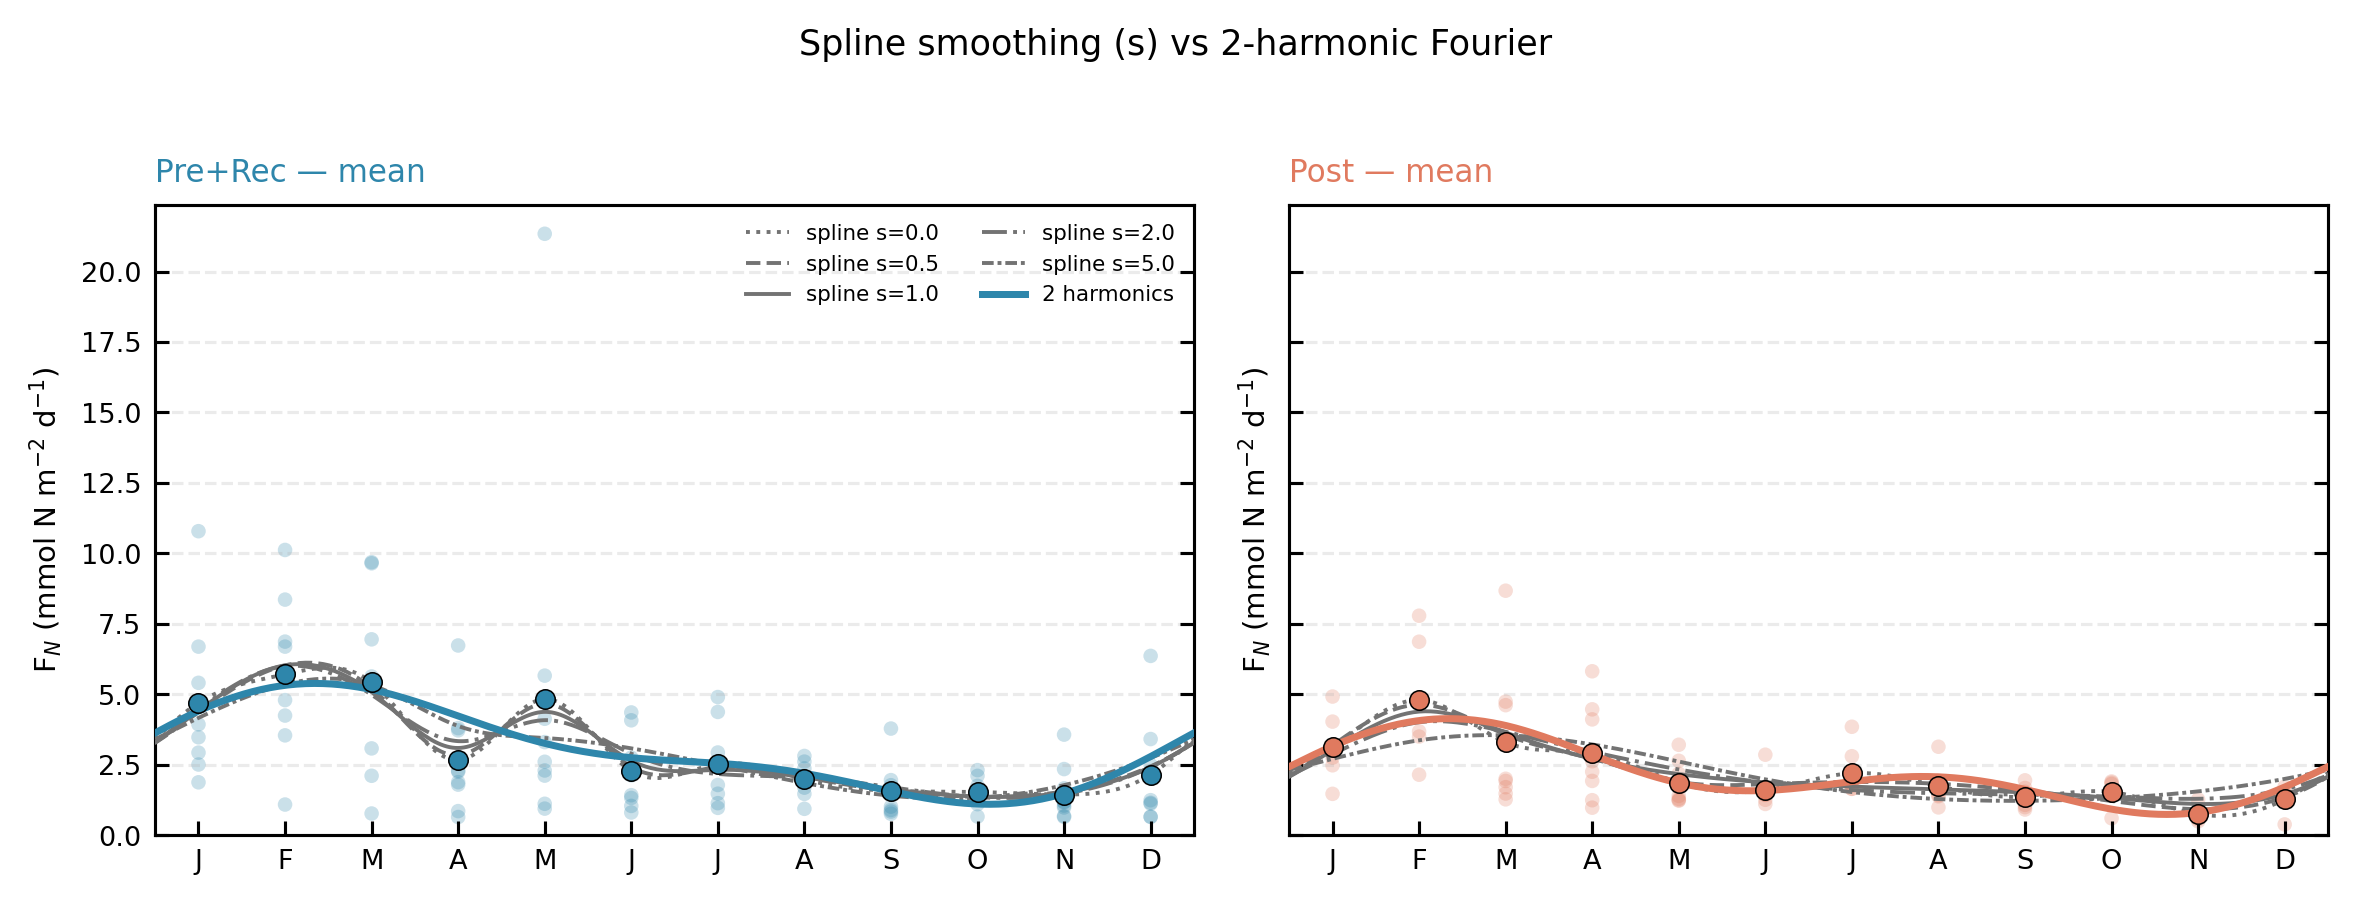

── Spline smoothing vs 2-harmonic (F_N, mean) ──
method              pre peak  post peak  pre ann  post ann   Δ ann   peak Δ
────────────────────────────────────────────────────────────────────────
spline s=0.0           5.950      4.802    3.060     2.202   0.858    3.023
spline s=0.5           6.127      4.634    3.070     2.207   0.863    2.786
spline s=1.0           6.075      4.402    3.069     2.208   0.861    2.220
spline s=2.0           6.019      4.052    3.067     2.206   0.862    1.991
spline s=5.0           5.563      3.556    3.063     2.193   0.869    2.044
2 harmonics            5.389      4.141    3.063     2.202   0.862    1.417


In [9]:
# ── Spline smoothing comparison (F_N only, mean) ────────────────────────
# s=0 (current, exact interpolation) vs a few smoothing levels vs 2-harmonic
from baseline_r0_seasonal_comps import _MID_MONTH_DOY
from scipy.interpolate import splrep, splev

S_VALS = [0.0, 0.5, 1.0, 2.0, 5.0]
S_LS   = {0.0: ':', 0.5: '--', 1.0: '-', 2.0: '-.', 5.0: (0,(3,1,1,1))}

fig3, axes3 = plt.subplots(1, 2, figsize=(8.5, 3.2), sharey=True)

for j, era in enumerate(ERAS):
    ax  = axes3[j]
    col = ERA_COL[era]
    monthly = stats[era]['FN_mmolN_m2_d']['mean']

    # obs scatter + monthly dots
    of = obs_raw[era]
    ax.scatter(of['mo'], of['FN_mmolN_m2_d'], s=14, color=col,
               alpha=0.25, edgecolors='none', zorder=1)
    ax.plot(_MO, monthly, 'o', color=col, ms=5, zorder=8,
            markeredgecolor='k', markeredgewidth=0.4)

    # splines at varying s
    x_spl = np.concatenate([[0.0], _MID_MONTH_DOY, [365.0]])
    wrap  = (monthly[0] + monthly[-1]) / 2.0
    y_spl = np.concatenate([[wrap], monthly, [wrap]])
    for s in S_VALS:
        tck = splrep(x_spl, y_spl, per=True, k=3, s=s)
        curve = np.maximum(splev(t_day_ref, tck), 0.0)
        ax.plot(mo_of_day, curve, ls=S_LS[s], color='0.45', lw=1.0,
                zorder=3, label=f'spline s={s}')

    # 2-harmonic (reference)
    _, h2_curve = curves[('mean', 2, era)]
    ax.plot(mo_of_day, h2_curve, '-', color=col, lw=1.8, zorder=5,
            label='2 harmonics')

    ax.set_ylim(bottom=0)
    ax.set_xlim(0.5, 12.5); ax.set_xticks(_MO)
    ax.set_xticklabels(['J','F','M','A','M','J','J','A','S','O','N','D'],
                       fontsize=6.5)
    ax.set_title(f'{ERA_LAB[era]} — mean', fontsize=8, loc='left', color=col)
    ax.set_ylabel('F$_N$ (mmol N m$^{{-2}}$ d$^{{-1}}$)', fontsize=7.5)
    ax.tick_params(top=False, right=True, direction='in', labelsize=7)
    ax.grid(axis='y', ls='--', alpha=0.25, zorder=0)
    if j == 0:
        ax.legend(fontsize=5.5, loc='upper right', ncol=2)

fig3.suptitle('Spline smoothing (s) vs 2-harmonic Fourier', fontsize=9, y=0.99)
fig3.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

# ── numeric: peak and annual mean for each s-value vs 2-harmonic ─────────
print("── Spline smoothing vs 2-harmonic (F_N, mean) ──")
print(f"{'method':<18} {'pre peak':>9} {'post peak':>10}"
      f" {'pre ann':>8} {'post ann':>9} {'Δ ann':>7} {'peak Δ':>8}")
print("─" * 72)

x_spl = np.concatenate([[0.0], _MID_MONTH_DOY, [365.0]])
for method_label, get_curve in [
    *[(f'spline s={s}',
       lambda era, _s=s: (lambda m: np.maximum(splev(t_day_ref,
           splrep(np.concatenate([[0.0], _MID_MONTH_DOY, [365.0]]),
                  np.concatenate([[(m[0]+m[-1])/2], m, [(m[0]+m[-1])/2]]),
                  per=True, k=3, s=_s)), 0.0))(
           stats[era]['FN_mmolN_m2_d']['mean']))
      for s in S_VALS],
    ('2 harmonics',
     lambda era: curves[('mean', 2, era)][1])]:
    pre_c  = get_curve('pre+recovery')
    post_c = get_curve('post')
    print(f"{method_label:<18} {pre_c.max():9.3f} {post_c.max():10.3f}"
          f" {pre_c.mean():8.3f} {post_c.mean():9.3f}"
          f" {pre_c.mean()-post_c.mean():7.3f}"
          f" {(pre_c-post_c).max():8.3f}")

[fig4] loaded /Users/aoop/Documents/GitHub/Research/SSMCariaco/plots/results/fig4_modeloutput.pkl
       {'construct': 'maranon_ward', 'params': {'GGE': 0.31, 'mP': 0.0015, 'm_Z': 0.1, 'KsZ': 0.23, 'sigma_log': 0.2}, 'fish': {'pre+recovery': 0.4, 'post': 0.0}, 'solver_floor': -0.01, 'created': '2026-06-23 12:09'}


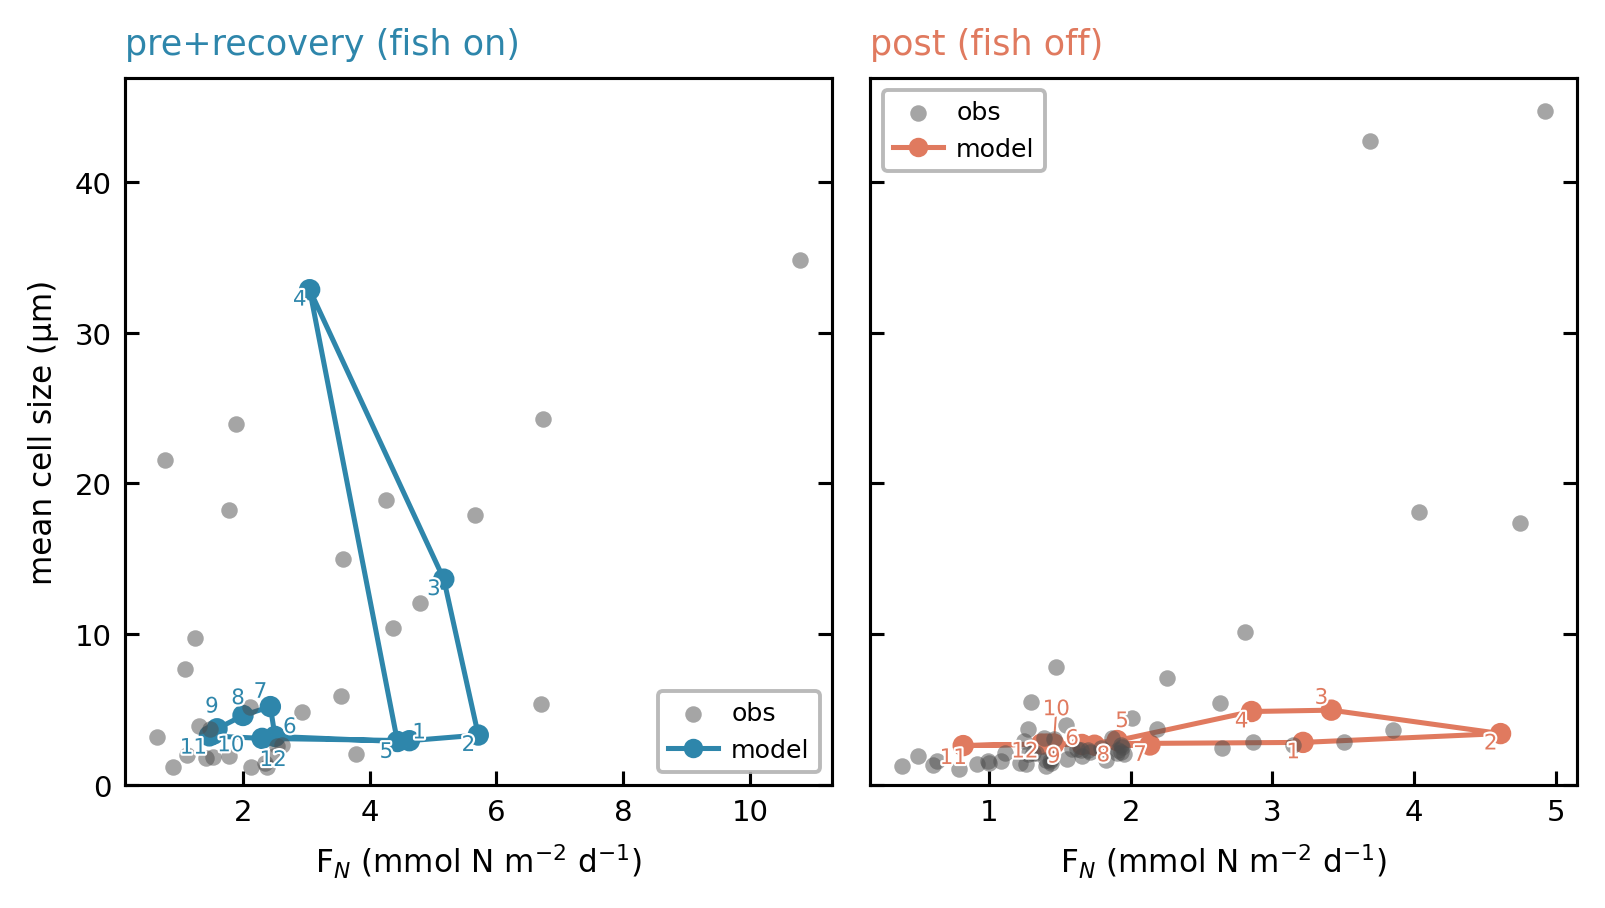

In [21]:
%config InlineBackend.figure_format = 'retina'
import numpy as np, matplotlib.pyplot as plt, matplotlib.patheffects as pe
from matplotlib.lines import Line2D
from adjustText import adjust_text
import fig4_panels as f4, seasonal_scan_harness as ssh
plt.rcParams.update({'figure.dpi': 140, 'savefig.dpi': 200, 'font.size': 9,
                     'axes.titlesize': 9, 'axes.labelsize': 8, 'legend.frameon': False})

MARK_REGIMES         = False   # False: one plain obs cloud; True: ring transition, x unclassified
SHOW_MISSING_FORCING = False   # False: forcing-complete months only; True: include FN-present incomplete
LOG_Y                = False   # True: log-µm y-axis (Fig 1/3 ticks); False: linear from 0
SHARE_X              = False    # True: both panels on one common x range (union, nothing cut)
XLIM                 = None#(0,11)    # custom (lo, hi) x-bounds; None = auto union when SHARE_X
OBS_C                = '0.30'  # obs grey (matches the seasonal cycle panel)
UM_TICKS             = [1, 2, 5, 10, 20, 40]

D     = f4.load_output()                              # model runs (settled construct D) from pickle
obs_m = ssh.build_obs_monthly(['pre+recovery', 'post'], forcing_complete=not SHOW_MISSING_FORCING)

ERAS    = {'pre+recovery': 0.4, 'post': 0.0}
ERA_COL = {'pre+recovery': '#2E86AB', 'post': '#E07A5F'}
ERA_LAB = {'pre+recovery': 'pre+recovery (fish on)', 'post': 'post (fish off)'}
_MO  = np.arange(1, 13)
TINY = [pe.withStroke(linewidth=0.6, foreground='white')]
LBLH = [pe.withStroke(linewidth=1.1, foreground='white')]     # month-number halo

def monthly(r, key, spin=15):
    keep = r['t'] >= spin * 365.0
    mo = np.clip(np.searchsorted(ssh._MEDGES, np.mod(r['t'][keep], 365.0), 'right') + 1, 1, 12)
    v = np.asarray(r[key], float)[keep]
    return np.array([np.nanmean(v[mo == m]) if np.any(mo == m) else np.nan for m in _MO])

def emptiest_corner(ax, P):
    x0, x1 = ax.get_xlim(); y0, y1 = ax.get_ylim()
    xm = np.sqrt(x0*x1) if ax.get_xscale()=='log' else 0.5*(x0+x1)
    ym = np.sqrt(y0*y1) if ax.get_yscale()=='log' else 0.5*(y0+y1)
    P = np.asarray(P, float); P = P[np.isfinite(P).all(1)]
    P = P[(P[:,0]>=min(x0,x1))&(P[:,0]<=max(x0,x1))&(P[:,1]>=min(y0,y1))&(P[:,1]<=max(y0,y1))]
    cnt = {'upper left':((P[:,0]<xm)&(P[:,1]>ym)).sum(),  'upper right':((P[:,0]>xm)&(P[:,1]>ym)).sum(),
           'lower left':((P[:,0]<xm)&(P[:,1]<ym)).sum(),  'lower right':((P[:,0]>xm)&(P[:,1]<ym)).sum()}
    return min(cnt, key=cnt.get)

runs  = {e: D['runs'][(e, ERAS[e])][1] for e in ERAS}
fnmod = {e: monthly(runs[e], 'FN')  for e in ERAS}
mcmod = {e: monthly(runs[e], 'mcs') for e in ERAS}
allmcs = np.concatenate([obs_m[e]['mcs'].dropna().values for e in ERAS] +
                        [mcmod[e][np.isfinite(mcmod[e])] for e in ERAS])
TOP = allmcs.max() * 1.05
BOT = allmcs.min() * 0.90 if LOG_Y else 0.0

allfn = np.concatenate([obs_m[e]['FN'].dropna().values for e in ERAS] +
                       [fnmod[e][np.isfinite(fnmod[e])] for e in ERAS])
allfn = allfn[np.isfinite(allfn)]
_padx = 0.04 * (allfn.max() - allfn.min())
XBOUNDS = XLIM if XLIM is not None else ((allfn.min() - _padx, allfn.max() + _padx) if SHARE_X else None)

def phase_panel(ax, era, show_ylabel=True):
    col = ERA_COL[era]
    om  = obs_m[era].dropna(subset=['FN', 'mcs'])
    fn, mc = fnmod[era], mcmod[era]
    o = np.r_[np.arange(12), 0]
    ax.plot(fn[o], mc[o], '-', color=col, lw=1.3, zorder=3, path_effects=TINY)
    ax.plot(fn, mc, 'o', color=col, ms=4.5, zorder=4, path_effects=TINY)
    if MARK_REGIMES:
        reg  = om['regime'].astype('object')
        norm = om[reg.isin(['upwelling','relaxed'])]; tran = om[reg == 'transition']
        nanr = om[~reg.isin(['upwelling','relaxed','transition'])]
        ax.scatter(norm['FN'], norm['mcs'], s=18, color=OBS_C, alpha=0.5, lw=0, zorder=5, label='obs')
        if len(tran): ax.scatter(tran['FN'], tran['mcs'], s=28, facecolors='none', edgecolors=OBS_C, lw=1.1, zorder=6, label='transition')
        if len(nanr): ax.scatter(nanr['FN'], nanr['mcs'], s=18, marker='x', color='0.55', lw=0.9, zorder=6, label='unclassified')
    else:
        ax.scatter(om['FN'], om['mcs'], s=18, color=OBS_C, alpha=0.5, lw=0, zorder=5, label='obs')
    if LOG_Y:
        ax.set_yscale('log')
    ax.set_ylim(BOT, TOP)
    if LOG_Y:
        ticks = [t for t in UM_TICKS if BOT <= t <= TOP]
        ax.set_yticks(ticks); ax.set_yticklabels([str(t) for t in ticks])
        ax.yaxis.set_minor_formatter(plt.NullFormatter())
    if XBOUNDS is not None:
        ax.set_xlim(*XBOUNDS)
    ax.set_xlabel('F$_N$ (mmol N m$^{-2}$ d$^{-1}$)')
    ax.set_ylabel('mean cell size (µm)' if show_ylabel else '', fontsize=8)
    ax.set_title(ERA_LAB[era], fontsize=9, loc='left', color=col)
    ax.set_box_aspect(1); ax.tick_params(top=False, right=True, direction='in', labelsize=7.5)
    texts = [ax.text(fn[m-1], mc[m-1], str(m), fontsize=5.5, color=col, zorder=7,
                     ha='center', va='center', path_effects=LBLH) for m in _MO]
    adjust_text(texts, force_points=0.2, force_text=0.2, expand_points=(1,1), expand_text=(1,1),
                arrowprops=dict(arrowstyle='-', color=col, lw=0.5), ax=ax)
    h, l = ax.get_legend_handles_labels()
    h.append(Line2D([],[],color=col,marker='o',ms=4,lw=1.3)); l.append('model')
    P = np.vstack([om[['FN','mcs']].values, np.column_stack([fn, mc])])
    ax.legend(h, l, fontsize=6.5, loc=emptiest_corner(ax, P), frameon=True,
              edgecolor='0.7', framealpha=0.9, borderpad=0.4, handletextpad=0.5)

fig, axs = plt.subplots(1, 2, figsize=(5.8, 3.4), sharey=True)
phase_panel(axs[0], 'pre+recovery', show_ylabel=True)
phase_panel(axs[1], 'post',         show_ylabel=False)
fig.tight_layout(); plt.show()

[fig4] loaded /Users/aoop/Documents/GitHub/Research/SSMCariaco/plots/results/fig4_modeloutput.pkl
       {'construct': 'maranon_ward', 'params': {'GGE': 0.31, 'mP': 0.0015, 'm_Z': 0.1, 'KsZ': 0.23, 'sigma_log': 0.2}, 'fish': {'pre+recovery': 0.4, 'post': 0.0}, 'solver_floor': -0.01, 'created': '2026-06-23 12:09'}


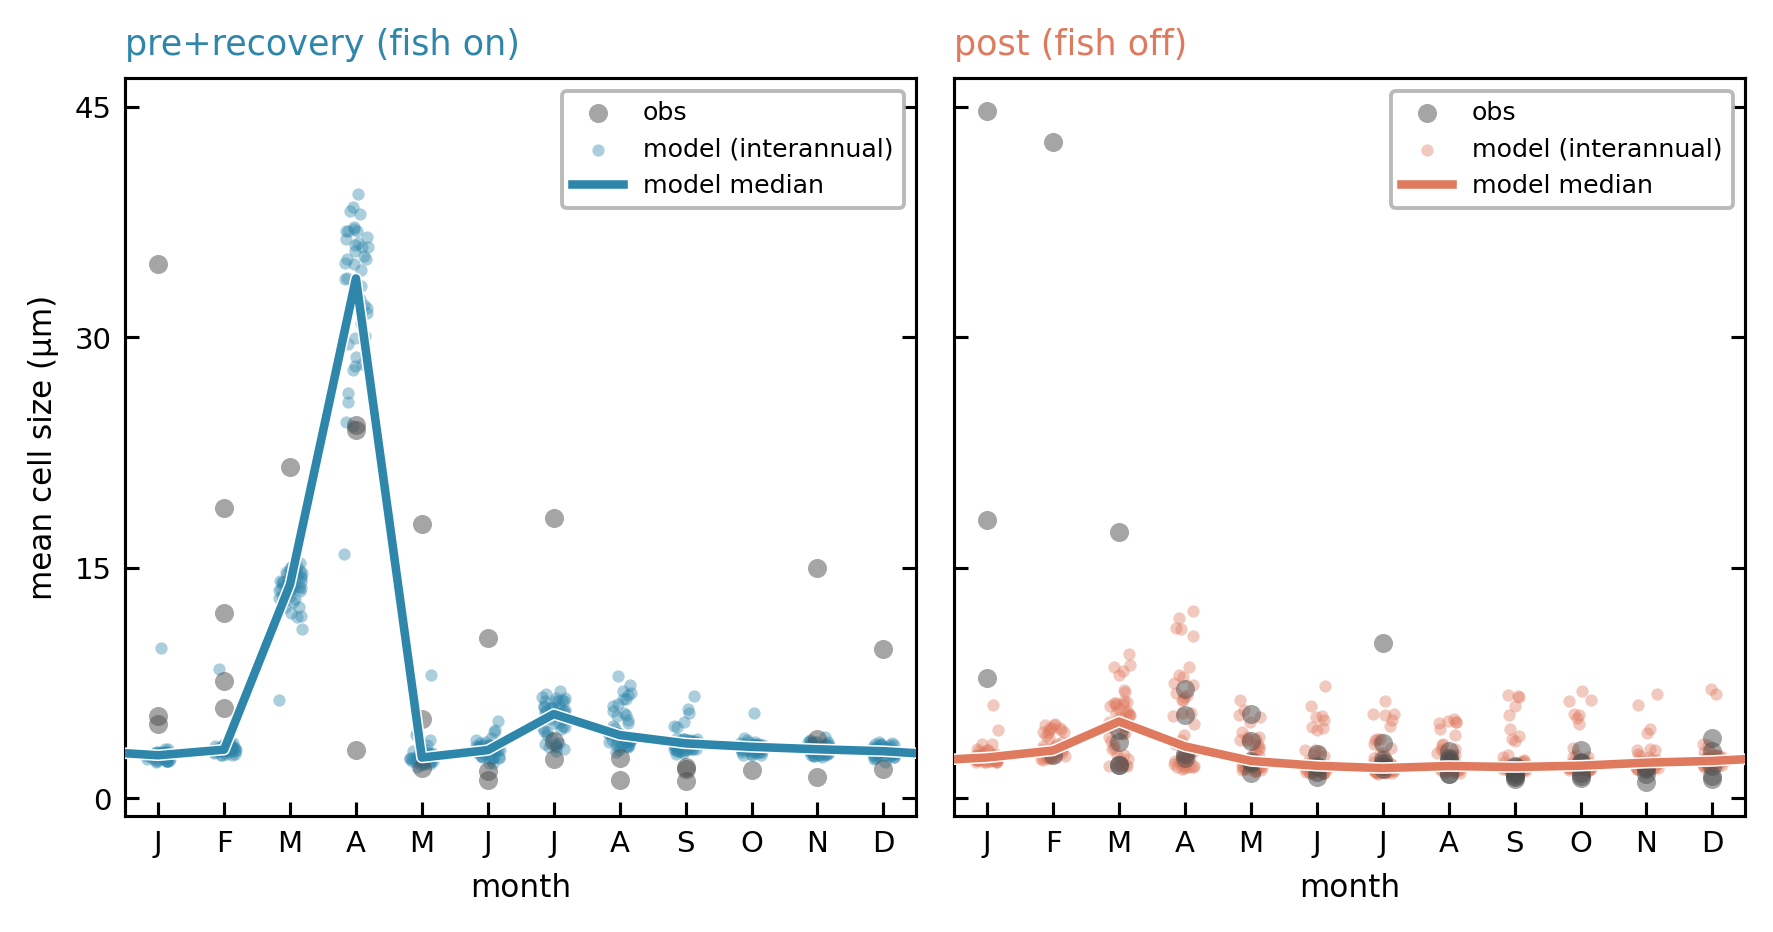

In [25]:
%config InlineBackend.figure_format = 'retina'
import numpy as np, matplotlib.pyplot as plt, matplotlib.patheffects as pe
from matplotlib.ticker import NullLocator, MaxNLocator
import fig4_panels as f4, seasonal_scan_harness as ssh
plt.rcParams.update({'figure.dpi': 140, 'savefig.dpi': 200, 'font.size': 9,
                     'axes.titlesize': 9, 'axes.labelsize': 8, 'legend.frameon': False})

MARK_REGIMES         = False   # False: one plain obs cloud; True: ring transition, x unclassified
SHOW_MISSING_FORCING = False   # False: forcing-complete months only; True: include FN-present incomplete
LOG_Y                = False    # True: log-µm y-axis (Fig 1/3 ticks); False: linear
METRIC               = 'mcs'   # obs/model series to cycle (mcs, micro, Z200, sumP, PP, ...)
OBS_C                = '0.30'  # obs grey (matches the seasonal cycle panel)
UM_TICKS             = [1, 2, 5, 10, 20, 40]
MLAB                 = {'mcs': 'mean cell size (µm)'}

D     = f4.load_output()
obs_m = ssh.build_obs_monthly(['pre+recovery', 'post'], forcing_complete=not SHOW_MISSING_FORCING)

ERAS    = {'pre+recovery': 0.4, 'post': 0.0}
ERA_COL = {'pre+recovery': '#2E86AB', 'post': '#E07A5F'}
ERA_LAB = {'pre+recovery': 'pre+recovery (fish on)', 'post': 'post (fish off)'}
_MO  = np.arange(1, 13); _MONTH_INI = list('JFMAMJJASOND')
_RNG = np.random.default_rng(0)
HALO3 = [pe.withStroke(linewidth=3.0, foreground='white')]

def peryear_month(r, key, spin=15):
    keep = r['t'] >= spin * 365.0
    t, v = r['t'][keep], np.asarray(r[key], float)[keep]
    mo = np.clip(np.searchsorted(ssh._MEDGES, np.mod(t, 365.0), 'right') + 1, 1, 12)
    yr = (t // 365.0).astype(int); out = []
    for y in np.unique(yr):
        for m in _MO:
            sel = v[(yr == y) & (mo == m)]; sel = sel[np.isfinite(sel)]
            if sel.size: out.append((m, sel.mean()))
    return np.array(out) if out else np.empty((0, 2))

def emptiest_corner(ax, P):
    x0, x1 = ax.get_xlim(); y0, y1 = ax.get_ylim()
    xm = np.sqrt(x0*x1) if ax.get_xscale()=='log' else 0.5*(x0+x1)
    ym = np.sqrt(y0*y1) if ax.get_yscale()=='log' else 0.5*(y0+y1)
    P = np.asarray(P, float); P = P[np.isfinite(P).all(1)]
    P = P[(P[:,0]>=min(x0,x1))&(P[:,0]<=max(x0,x1))&(P[:,1]>=min(y0,y1))&(P[:,1]<=max(y0,y1))]
    cnt = {'upper left':((P[:,0]<xm)&(P[:,1]>ym)).sum(),  'upper right':((P[:,0]>xm)&(P[:,1]>ym)).sum(),
           'lower left':((P[:,0]<xm)&(P[:,1]<ym)).sum(),  'lower right':((P[:,0]>xm)&(P[:,1]<ym)).sum()}
    return min(cnt, key=cnt.get)

def cycle_panel(ax, era, show_ylabel=True):
    col = ERA_COL[era]; r = D['runs'][(era, ERAS[era])][1]
    om = obs_m[era].dropna(subset=[METRIC])
    if MARK_REGIMES:
        reg  = om['regime'].astype('object')
        norm = om[reg.isin(['upwelling','relaxed'])]; tran = om[reg == 'transition']
        nanr = om[~reg.isin(['upwelling','relaxed','transition'])]
        ax.scatter(norm['mo'], norm[METRIC], s=24, color=OBS_C, alpha=0.5, lw=0, zorder=3, label='obs')
        if len(tran): ax.scatter(tran['mo'], tran[METRIC], s=34, facecolors='none', edgecolors=OBS_C, lw=1.1, zorder=4, label='transition')
        if len(nanr): ax.scatter(nanr['mo'], nanr[METRIC], s=24, marker='x', color='0.55', lw=0.9, zorder=4, label='unclassified')
    else:
        ax.scatter(om['mo'], om[METRIC], s=24, color=OBS_C, alpha=0.5, lw=0, zorder=3, label='obs')
    ym = peryear_month(r, METRIC)
    if len(ym):
        ax.scatter(ym[:,0] + _RNG.uniform(-0.18, 0.18, len(ym)), ym[:,1],
                   s=10, color=col, alpha=0.40, lw=0, zorder=2, label='model (interannual)')
        med = np.array([np.nanmedian(ym[ym[:,0]==m, 1]) if np.any(ym[:,0]==m) else np.nan for m in _MO])
        w = (med[0] + med[11]) / 2.0                                  # Dec<->Jan wrap
        xw = np.r_[0.5, _MO, 12.5]; mw = np.r_[w, med, w]             # extend to both spines
        ax.plot(xw, mw, '-', color=col, lw=2.2, zorder=4, path_effects=HALO3, label='model median')
    ax.set_xlim(0.5, 12.5); ax.set_xticks(_MO); ax.set_xticklabels(_MONTH_INI, fontsize=7); ax.set_xlabel('month')
    if LOG_Y and METRIC == 'mcs':
        ax.set_yscale('log'); ax.set_yticks(UM_TICKS); ax.set_yticklabels([str(u) for u in UM_TICKS])
        ax.yaxis.set_minor_locator(NullLocator())
    else:
        ax.yaxis.set_major_locator(MaxNLocator(nbins=4))
    ax.set_ylabel(MLAB.get(METRIC, METRIC) if show_ylabel else '', fontsize=8)
    ax.set_title(ERA_LAB[era], fontsize=9, loc='left', color=col)
    ax.tick_params(top=False, right=True, direction='in', labelsize=7.5)
    P = np.vstack([om[['mo', METRIC]].values, ym]) if len(ym) else om[['mo', METRIC]].values
    ax.legend(fontsize=6.5, loc=emptiest_corner(ax, P), frameon=True, edgecolor='0.7', framealpha=0.9, borderpad=0.4)

fig, axs = plt.subplots(1, 2, figsize=(6.4, 3.4), sharey=True)
cycle_panel(axs[0], 'pre+recovery', show_ylabel=True)
cycle_panel(axs[1], 'post',         show_ylabel=False)
fig.tight_layout(); plt.show()

[fig4] loaded /Users/aoop/Documents/GitHub/Research/SSMCariaco/plots/results/fig4_modeloutput.pkl
       {'construct': 'maranon_ward', 'params': {'GGE': 0.31, 'mP': 0.0015, 'm_Z': 0.1, 'KsZ': 0.23, 'sigma_log': 0.2}, 'fish': {'pre+recovery': 0.4, 'post': 0.0}, 'solver_floor': -0.01, 'created': '2026-06-23 12:09'}


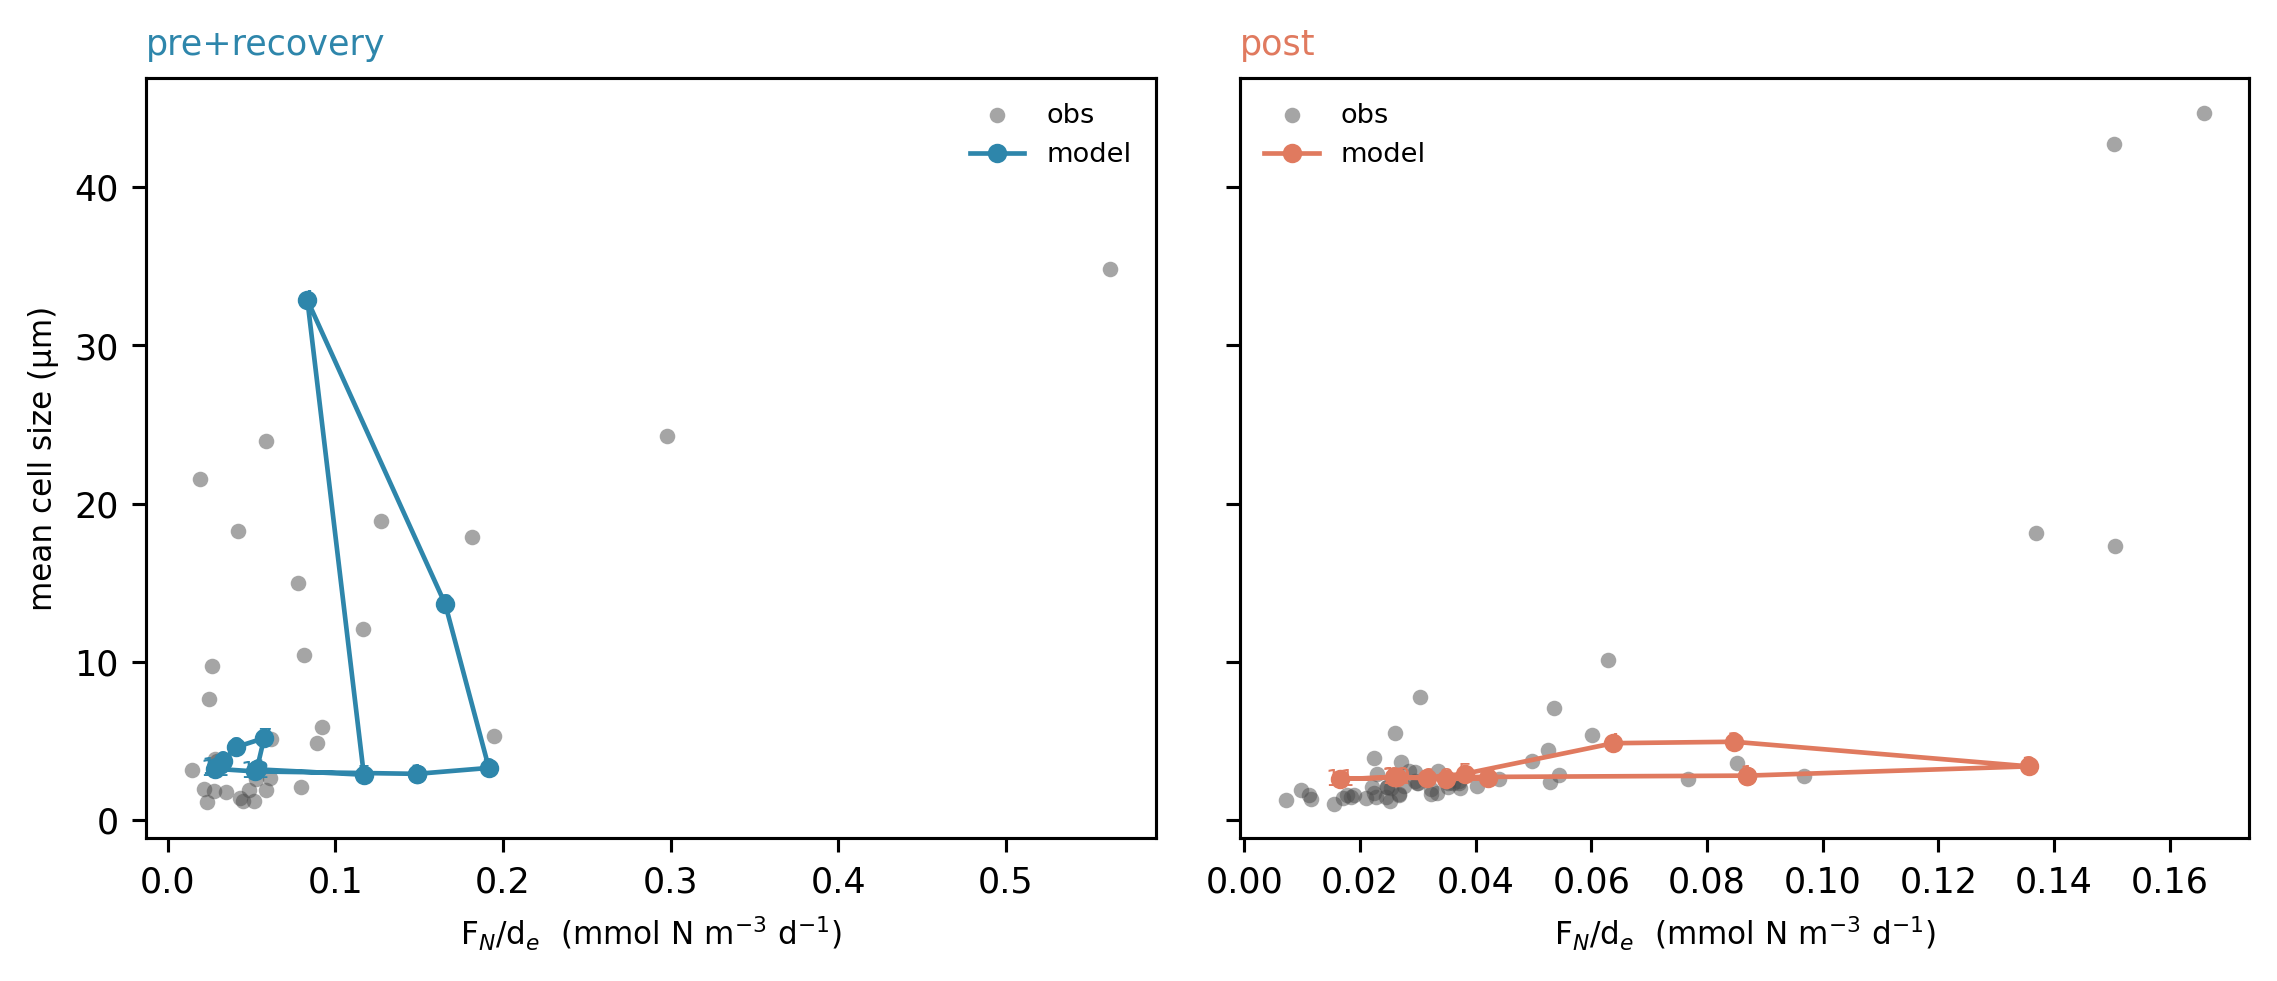

In [10]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import fig4_panels as f4, seasonal_scan_harness as ssh

D    = f4.load_output()
ERAS = {'pre+recovery': 0.4, 'post': 0.0}
COL  = {'pre+recovery': '#2E86AB', 'post': '#E07A5F'}
GEOM = np.array([0.63, 6.3, 63.0])

# obs: compute mcs + volumetric supply F_N/d_e straight from the CSV (forcing-complete months)
df = pd.read_csv(ssh.DEFAULT_CSV_PATH, parse_dates=['date'])
df['era'] = df['date'].dt.year.map(ssh.ERA_OF)
df = df[df[['FN_mmolN_m2_d', 'depth_cutoff', 'Temp_C']].notna().all(axis=1)].copy()
A = df[['pico_mmolN', 'nano_mmolN', 'micro_mmolN']].to_numpy(float); tot = A.sum(1)
fr = np.where(tot[:, None] > 0, A / tot[:, None], np.nan)
df['mcs']    = np.where(tot > 0, 10.0 ** (fr @ np.log10(GEOM)), np.nan)
df['supply'] = df['FN_mmolN_m2_d'] / df['depth_cutoff']

def monthly(r, k, spin=15):
    keep = r['t'] >= spin * 365.0
    mo = np.clip(np.searchsorted(ssh._MEDGES, np.mod(r['t'][keep], 365.0), 'right') + 1, 1, 12)
    v = np.asarray(r[k], float)[keep]
    return np.array([np.nanmean(v[mo == m]) if np.any(mo == m) else np.nan for m in range(1, 13)])

fig, axs = plt.subplots(1, 2, figsize=(8.2, 3.6), sharey=True)
for ax, (era, fish) in zip(axs, ERAS.items()):
    col = COL[era]; r = D['runs'][(era, fish)][1]
    o = df[df['era'].isin(ssh.GROUP_ERAS[era])]
    ax.scatter(o['supply'], o['mcs'], s=16, color='0.30', alpha=0.5, lw=0, label='obs')
    sup = monthly(r, 'FN') / monthly(r, 'de'); mc = monthly(r, 'mcs')
    k = np.r_[np.arange(12), 0]
    ax.plot(sup[k], mc[k], '-o', color=col, ms=4, lw=1.2, label='model')
    for m in range(1, 13):
        ax.text(sup[m-1], mc[m-1], str(m), fontsize=6, color=col, ha='center', va='center')
    ax.set_title(era, color=col, loc='left'); ax.set_xlabel('F$_N$/d$_e$  (mmol N m$^{-3}$ d$^{-1}$)')
    ax.legend(fontsize=7, frameon=False)
axs[0].set_ylabel('mean cell size (µm)')
plt.tight_layout(); plt.show()

# New Plot Ideas:

[fig4] loaded /Users/aoop/Documents/GitHub/Research/SSMCariaco/plots/results/fig4_modeloutput.pkl
       {'construct': 'maranon_ward', 'params': {'GGE': 0.31, 'mP': 0.0015, 'm_Z': 0.1, 'KsZ': 0.23, 'sigma_log': 0.2}, 'fish': {'pre+recovery': 0.4, 'post': 0.0}, 'solver_floor': -0.01, 'created': '2026-06-23 12:09'}


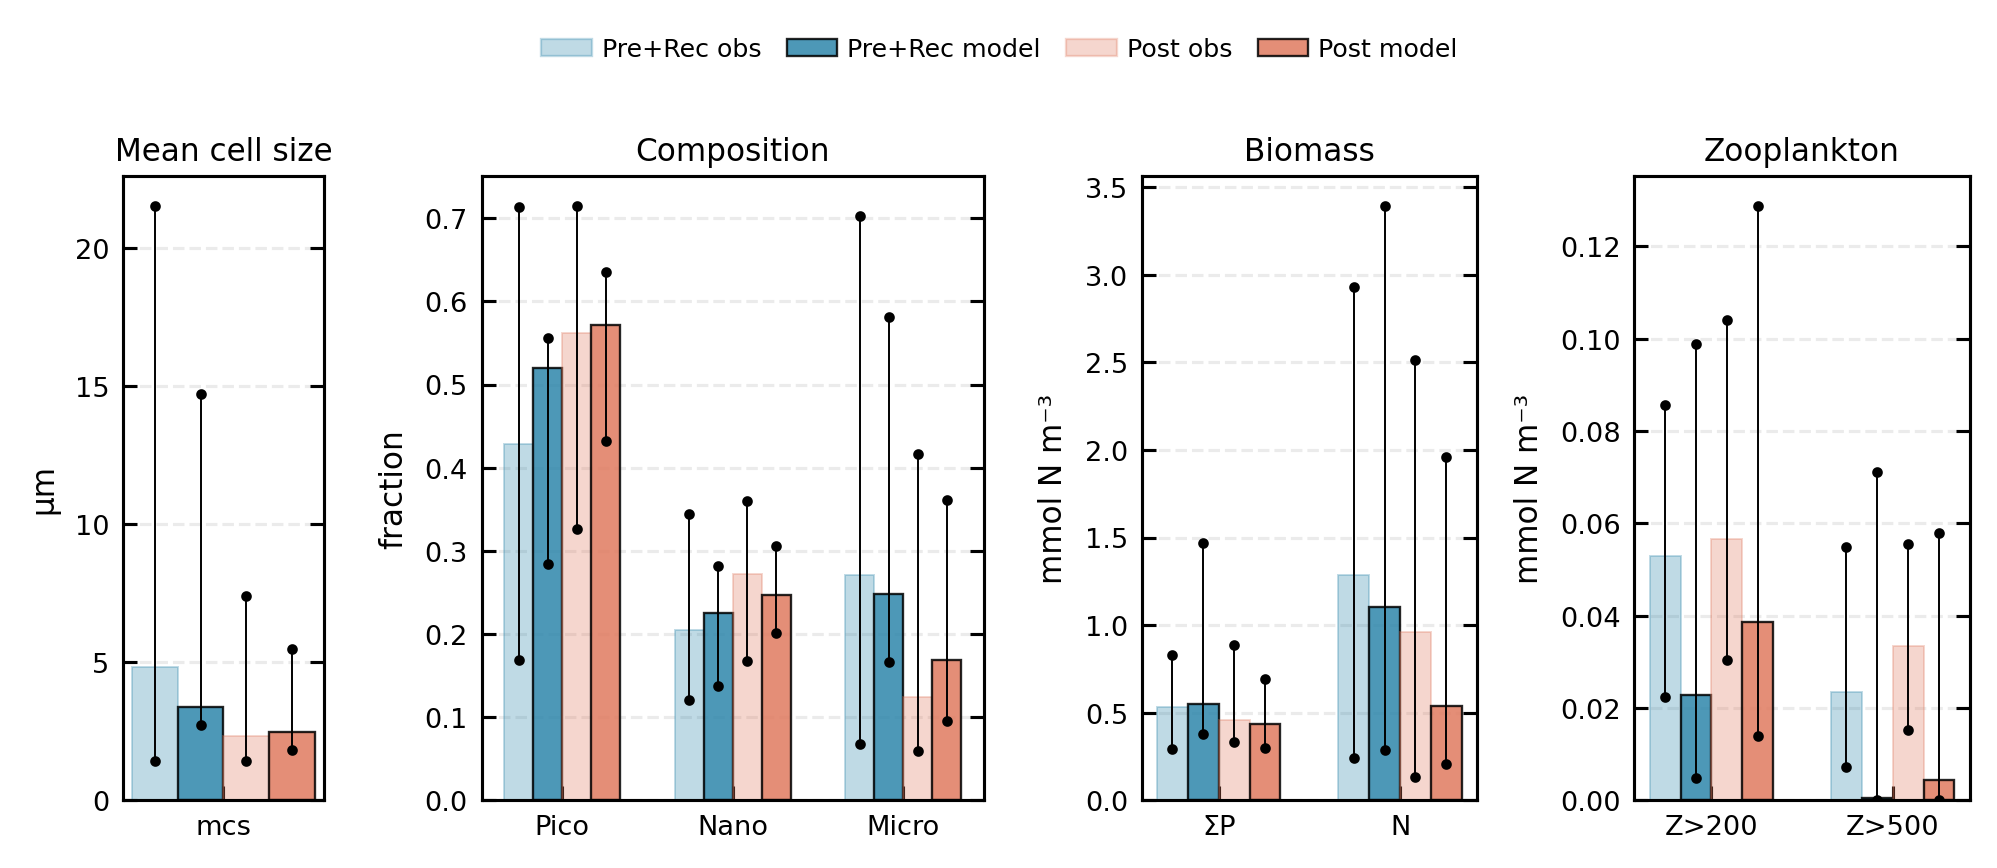


── Panel (b) diagnostics ──
metric   era             obs_med  mod_med   ratio        obs 10-90%       mod 10-90% n_obs n_mod
────────────────────────────────────────────────────────────────────────────────────────────────
mcs      pre+recovery     4.8412   3.3904   0.700  [ 1.4103, 21.5385]  [ 2.7166, 14.7185]     31   540
mcs      post             2.3179   2.4849   1.072  [ 1.4243,  7.3929]  [ 1.8384,  5.4865]     57   540

Pico     pre+recovery     0.4291   0.5200   1.212  [ 0.1690,  0.7131]  [ 0.2843,  0.5558]     31   540
Pico     post             0.5617   0.5715   1.017  [ 0.3262,  0.7152]  [ 0.4325,  0.6360]     57   540
Nano     pre+recovery     0.2053   0.2253   1.098  [ 0.1212,  0.3450]  [ 0.1378,  0.2820]     31   540
Nano     post             0.2722   0.2468   0.907  [ 0.1682,  0.3596]  [ 0.2015,  0.3060]     57   540
Micro    pre+recovery     0.2706   0.2485   0.919  [ 0.0677,  0.7029]  [ 0.1669,  0.5818]     31   540
Micro    post             0.1239   0.1685   1.360  [ 0.

In [32]:
# ── Fig 4, Panel (b): model vs obs grouped bars ─────────────────────────
import numpy as np, matplotlib.pyplot as plt
from matplotlib.patches import Patch
import fig4_panels as f4, seasonal_scan_harness as ssh

plt.rcParams.update({'figure.dpi': 140, 'savefig.dpi': 200, 'font.size': 9,
                     'axes.titlesize': 9, 'axes.labelsize': 8, 'legend.frameon': False})

# ── behaviour flags ──
BOXPLOT   = False   # True → boxplots (IQR + 10-90% whiskers); False → bars (median + 10-90%)
LOG_POOLS = False    # True → log y on the pools panel

# ── data ──
D     = f4.load_output()
obs_m = ssh.build_obs_monthly(['pre+recovery', 'post'], forcing_complete=True)
ERAS    = ['pre+recovery', 'post']
FISH    = {'pre+recovery': 0.4, 'post': 0.0}
ERA_COL = {'pre+recovery': '#2E86AB', 'post': '#E07A5F'}
ERA_LAB = {'pre+recovery': 'Pre+Rec', 'post': 'Post'}
_MO     = np.arange(1, 13)

def model_monthly_vals(r, key, spin=15):
    """Per-year, per-calendar-month means from the post-spinup trajectory → flat array.
    One value per (year, month) pair — comparable to individual obs monthly values."""
    t = np.asarray(r['t'], float); keep = t >= spin * 365.0
    v = np.asarray(r[key], float)[keep]; tk = t[keep]
    mo = np.clip(np.searchsorted(ssh._MEDGES, np.mod(tk, 365.0), 'right') + 1, 1, 12)
    yr = (tk / 365.0).astype(int)
    return np.array([np.nanmean(v[(yr == y) & (mo == m)])
                     for y in np.unique(yr) for m in _MO
                     if np.any((yr == y) & (mo == m))])

runs = {e: D['runs'][(e, FISH[e])][1] for e in ERAS}

PANELS = [
    ('Mean cell size',  [('mcs',  'mcs',  'mcs')],                             'µm',          False),
    ('Composition',     [('Pico', 'pico', 'pico'), ('Nano', 'nano', 'nano'),
                         ('Micro','micro','micro')],                            'fraction',    False),
    ('Biomass',         [('ΣP',   'sumP', 'sumP'), ('N',    'N',    'N')],      'mmol N m⁻³',  False),
    ('Zooplankton',     [('Z>200','Z200', 'Z200'), ('Z>500','Z500', 'Z500')],   'mmol N m⁻³',  False),
]
# Gather distributions
dist = {}
for era in ERAS:
    for _, metrics, _, _ in PANELS:
        for label, obs_col, mod_key in metrics:
            o = obs_m[era][obs_col].dropna().values.astype(float)
            m = model_monthly_vals(runs[era], mod_key)
            dist[(era, label)] = {'obs': o[np.isfinite(o)], 'mod': m[np.isfinite(m)]}

# ── figure ──
width_ratios = [max(len(metrics), 1.2) for _, metrics, _, _ in PANELS]
fig, axes = plt.subplots(1, len(PANELS), figsize=(7.2, 3.0),
                         gridspec_kw={'width_ratios': width_ratios})

BAR_W = 0.17
DX = {('pre+recovery', 'obs'): -1.5*BAR_W,  ('pre+recovery', 'mod'): -0.5*BAR_W,
      ('post',         'obs'):  0.5*BAR_W,   ('post',         'mod'):  1.5*BAR_W}

for ax, (ptitle, metrics, ylabel, log_y) in zip(axes, PANELS):
    xpos = np.arange(len(metrics))

    for i, (label, _, _) in enumerate(metrics):
        for era in ERAS:
            col = ERA_COL[era]
            for src in ('obs', 'mod'):
                vals = dist[(era, label)][src]
                if vals.size == 0:
                    continue
                x = i + DX[(era, src)]
                is_obs = (src == 'obs')

                if BOXPLOT:
                    bp = ax.boxplot(
                        [vals], positions=[x], widths=BAR_W * 0.88,
                        patch_artist=True, showfliers=False, whis=[10, 90],
                        whiskerprops=dict(lw=0.6, color='k'),
                        capprops=dict(lw=0.6, color='k'),
                        medianprops=dict(color='k', lw=1.0))
                    bp['boxes'][0].set(
                        facecolor=col, alpha=0.3 if is_obs else 0.85,
                        edgecolor=col if is_obs else 'k',
                        linewidth=0.5 if is_obs else 0.6)
                else:
                    med = np.median(vals)
                    lo, hi = np.percentile(vals, [10, 90])
                    ax.bar(x, med, BAR_W,
                           color=col, alpha=0.3 if is_obs else 0.85,
                           edgecolor=col if is_obs else 'k',
                           linewidth=0.5 if is_obs else 0.6, zorder=2)
                    ax.plot([x, x], [lo, hi], color='k', lw=0.5, zorder=3)
                    ax.scatter([x, x], [lo, hi], color='k', s=3, zorder=4)

    ax.set_xticks(xpos)
    ax.set_xticklabels([m[0] for m in metrics], fontsize=7)
    ax.set_ylabel(ylabel, fontsize=8)
    ax.set_title(ptitle, fontsize=8, pad=4)
    if log_y:
        ax.set_yscale('log')
        all_v = np.concatenate([dist[(e, m[0])][s]
                                for e in ERAS for m in metrics for s in ('obs','mod')
                                if dist[(e, m[0])][s].size > 0])
        all_v = all_v[all_v > 0]
        if all_v.size:
            ax.set_ylim(bottom=10**(np.floor(np.log10(all_v.min())) - 0.3))
    ax.tick_params(top=False, right=True, direction='in', labelsize=7)
    ax.grid(axis='y', ls='--', alpha=0.25, zorder=0)

# ── legend ──
handles = []
for era in ERAS:
    c = ERA_COL[era]
    handles.append(Patch(fc=c, alpha=0.3,  ec=c,   lw=0.6, label=f'{ERA_LAB[era]} obs'))
    handles.append(Patch(fc=c, alpha=0.85, ec='k',  lw=0.6, label=f'{ERA_LAB[era]} model'))
fig.legend(handles=handles, loc='upper center', ncol=4, fontsize=6.5,
           bbox_to_anchor=(0.5, 1.03), frameon=False,
           handletextpad=0.4, columnspacing=1.0)

fig.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()

# ── diagnostic table ──
print("\n── Panel (b) diagnostics ──")
hdr = f"{'metric':<8} {'era':<14} {'obs_med':>8} {'mod_med':>8} {'ratio':>7}  {'obs 10-90%':>16} {'mod 10-90%':>16} {'n_obs':>5} {'n_mod':>5}"
print(hdr)
print("─" * len(hdr))
for _, metrics, _, _ in PANELS:
    for label, _, _ in metrics:
        for era in ERAS:
            o, m = dist[(era, label)]['obs'], dist[(era, label)]['mod']
            om, mm = np.median(o), np.median(m)
            r = mm / om if om != 0 else np.nan
            olo, ohi = np.percentile(o, [10, 90]) if o.size else (np.nan, np.nan)
            mlo, mhi = np.percentile(m, [10, 90]) if m.size else (np.nan, np.nan)
            print(f"{label:<8} {era:<14} {om:8.4f} {mm:8.4f} {r:7.3f}  "
                  f"[{olo:7.4f}, {ohi:7.4f}]  [{mlo:7.4f}, {mhi:7.4f}]  {len(o):5d} {len(m):5d}")
    print()

[fig4] loaded /Users/aoop/Documents/GitHub/Research/SSMCariaco/plots/results/fig4_modeloutput.pkl
       {'construct': 'maranon_ward', 'params': {'GGE': 0.31, 'mP': 0.0015, 'm_Z': 0.1, 'KsZ': 0.23, 'sigma_log': 0.2}, 'fish': {'pre+recovery': 0.4, 'post': 0.0}, 'solver_floor': -0.01, 'created': '2026-06-23 12:09'}


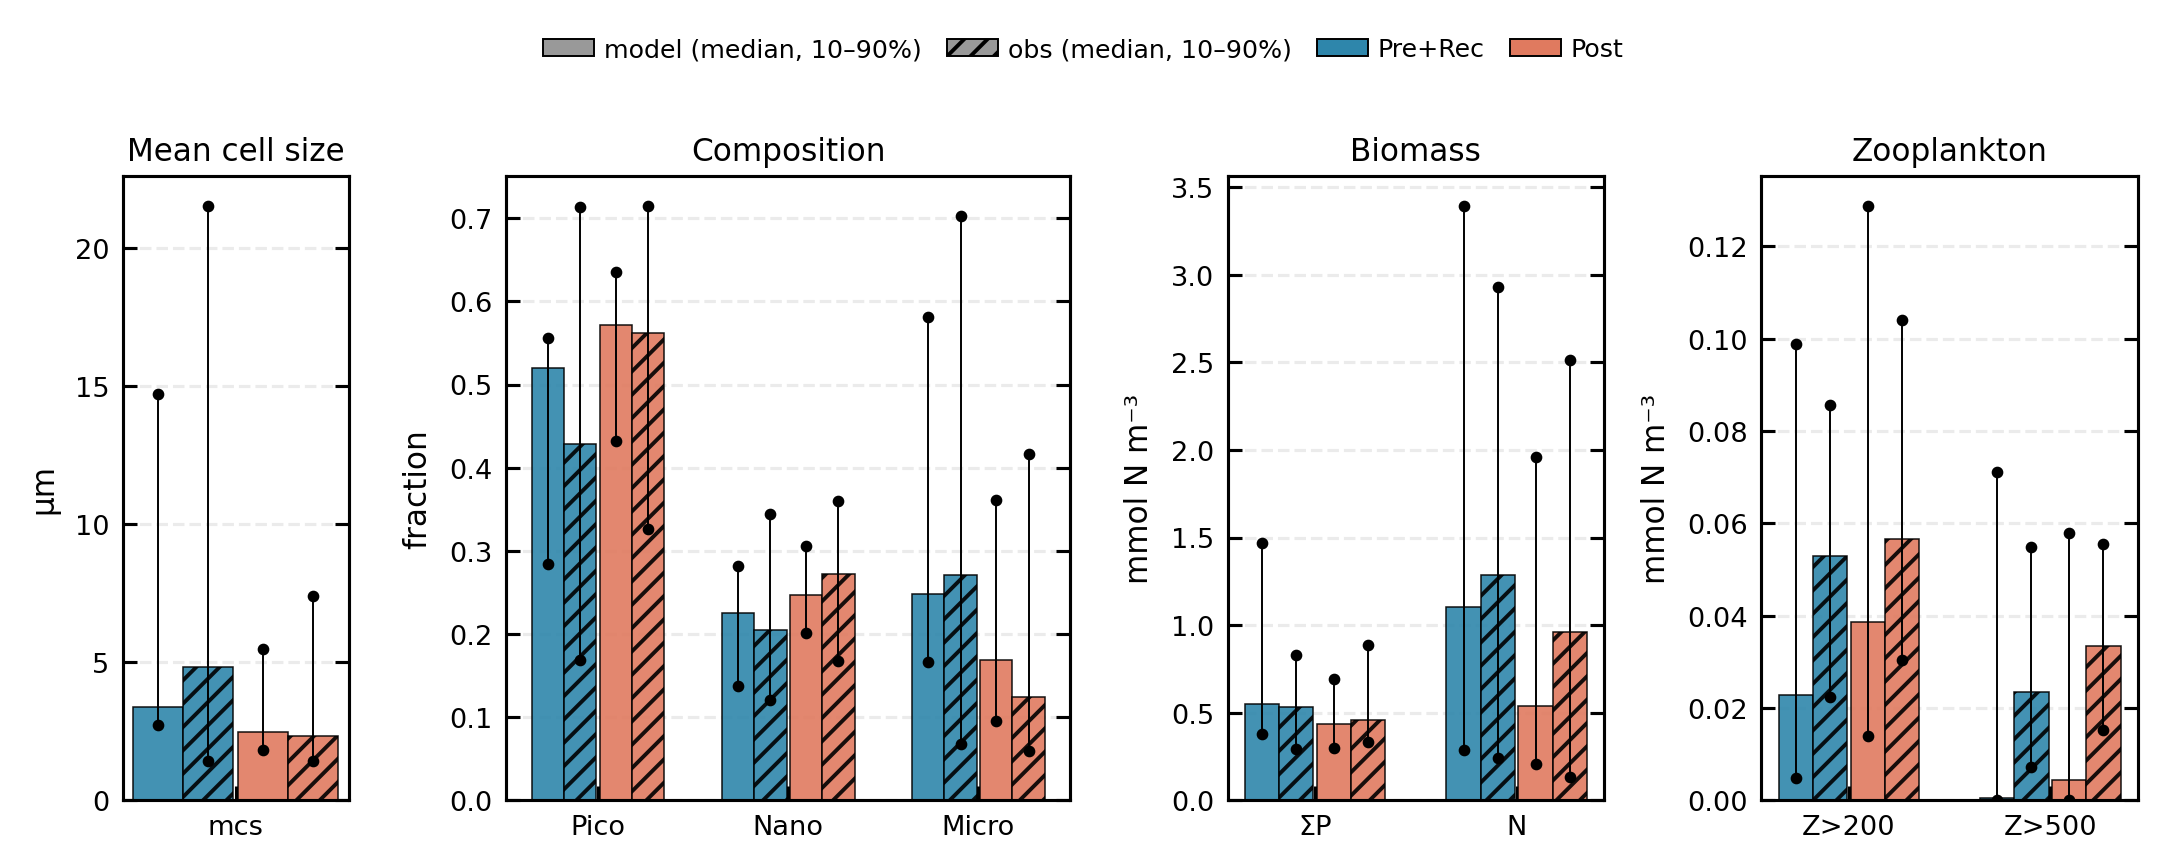


── Panel (b) diagnostics ──
metric   era             obs_med  mod_med   ratio        obs 10-90%       mod 10-90% n_obs n_mod
────────────────────────────────────────────────────────────────────────────────────────────────
mcs      pre+recovery     4.8412   3.3904   0.700  [ 1.4103, 21.5385]  [ 2.7166, 14.7185]     31   540
mcs      post             2.3179   2.4849   1.072  [ 1.4243,  7.3929]  [ 1.8384,  5.4865]     57   540

Pico     pre+recovery     0.4291   0.5200   1.212  [ 0.1690,  0.7131]  [ 0.2843,  0.5558]     31   540
Pico     post             0.5617   0.5715   1.017  [ 0.3262,  0.7152]  [ 0.4325,  0.6360]     57   540
Nano     pre+recovery     0.2053   0.2253   1.098  [ 0.1212,  0.3450]  [ 0.1378,  0.2820]     31   540
Nano     post             0.2722   0.2468   0.907  [ 0.1682,  0.3596]  [ 0.2015,  0.3060]     57   540
Micro    pre+recovery     0.2706   0.2485   0.919  [ 0.0677,  0.7029]  [ 0.1669,  0.5818]     31   540
Micro    post             0.1239   0.1685   1.360  [ 0.

In [33]:
# ── Fig 4, Panel (b): model vs obs grouped bars ─────────────────────────
import numpy as np, matplotlib.pyplot as plt
from matplotlib.patches import Patch
import fig4_panels as f4, seasonal_scan_harness as ssh

plt.rcParams.update({'figure.dpi': 140, 'savefig.dpi': 200, 'font.size': 9,
                     'axes.titlesize': 9, 'axes.labelsize': 8, 'legend.frameon': False})

# ── behaviour flags ──
BOXPLOT = False   # True → boxplots (IQR + 10-90% whiskers); False → bars (median + 10-90%)

# ── data ──
D     = f4.load_output()
obs_m = ssh.build_obs_monthly(['pre+recovery', 'post'], forcing_complete=True)
ERAS    = ['pre+recovery', 'post']
FISH    = {'pre+recovery': 0.4, 'post': 0.0}
ERA_COL = {'pre+recovery': '#2E86AB', 'post': '#E07A5F'}
ERA_LAB = {'pre+recovery': 'Pre+Rec', 'post': 'Post'}
_MO     = np.arange(1, 13)

def model_monthly_vals(r, key, spin=15):
    """Per-year, per-calendar-month means from the post-spinup trajectory → flat array."""
    t = np.asarray(r['t'], float); keep = t >= spin * 365.0
    v = np.asarray(r[key], float)[keep]; tk = t[keep]
    mo = np.clip(np.searchsorted(ssh._MEDGES, np.mod(tk, 365.0), 'right') + 1, 1, 12)
    yr = (tk / 365.0).astype(int)
    return np.array([np.nanmean(v[(yr == y) & (mo == m)])
                     for y in np.unique(yr) for m in _MO
                     if np.any((yr == y) & (mo == m))])

runs = {e: D['runs'][(e, FISH[e])][1] for e in ERAS}

# ── metric definitions per panel ──
PANELS = [
    ('Mean cell size',  [('mcs',  'mcs',  'mcs')],                             'µm',          False),
    ('Composition',     [('Pico', 'pico', 'pico'), ('Nano', 'nano', 'nano'),
                         ('Micro','micro','micro')],                            'fraction',    False),
    ('Biomass',         [('ΣP',   'sumP', 'sumP'), ('N',    'N',    'N')],      'mmol N m⁻³',  False),
    ('Zooplankton',     [('Z>200','Z200', 'Z200'), ('Z>500','Z500', 'Z500')],   'mmol N m⁻³',  False),
]

# Gather distributions
dist = {}
for era in ERAS:
    for _, metrics, _, _ in PANELS:
        for label, obs_col, mod_key in metrics:
            o = obs_m[era][obs_col].dropna().values.astype(float)
            m = model_monthly_vals(runs[era], mod_key)
            dist[(era, label)] = {'obs': o[np.isfinite(o)], 'mod': m[np.isfinite(m)]}

# ── bar drawing (parscan_plots grammar) ──
def draw_bar(ax, x, vals, color, hatch=None, width=0.17):
    """Median bar + 10-90% whisker. Solid = model, hatched = obs."""
    v = np.asarray(vals, float); v = v[np.isfinite(v)]
    if v.size == 0:
        ax.text(x, 0.02, 'no\ndata', transform=ax.get_xaxis_transform(),
                ha='center', va='bottom', fontsize=5.5, color='grey')
        return
    lo, hi = np.percentile(v, [10, 90])
    ax.bar(x, np.median(v), width, color=color, alpha=0.9, hatch=hatch,
           edgecolor='k', linewidth=0.4, zorder=2)
    ax.plot([x, x], [lo, hi], color='k', lw=0.5, zorder=4)
    ax.scatter([x, x], [lo, hi], color='k', s=4, zorder=5)

def draw_box(ax, x, vals, color, hatch=None, width=0.17):
    """Boxplot with 10-90% whiskers. Solid = model, hatched = obs."""
    v = np.asarray(vals, float); v = v[np.isfinite(v)]
    if v.size == 0:
        return
    bp = ax.boxplot([v], positions=[x], widths=width * 0.88,
                    patch_artist=True, showfliers=False, whis=[10, 90],
                    whiskerprops=dict(lw=0.6, color='k'),
                    capprops=dict(lw=0.6, color='k'),
                    medianprops=dict(color='k', lw=1.0))
    bp['boxes'][0].set(facecolor=color, alpha=0.9, edgecolor='k',
                       linewidth=0.5, hatch=hatch)

# ── figure ──
width_ratios = [max(len(m), 1.2) for _, m, _, _ in PANELS]
fig, axes = plt.subplots(1, len(PANELS), figsize=(7.8, 3.0),
                         gridspec_kw={'width_ratios': width_ratios})

BAR_W = 0.17
# within each x-group: model left, obs (hatched) right — per era
# pre+rec group on the left, post group on the right
DX_MOD = {'pre+recovery': -0.55*BAR_W - BAR_W,  'post':  0.55*BAR_W}
DX_OBS = {'pre+recovery': -0.55*BAR_W,          'post':  0.55*BAR_W + BAR_W}

draw = draw_box if BOXPLOT else draw_bar

for ax, (ptitle, metrics, ylabel, _) in zip(axes, PANELS):
    xpos = np.arange(len(metrics))

    for i, (label, _, _) in enumerate(metrics):
        for era in ERAS:
            col = ERA_COL[era]
            # model: solid, left
            draw(ax, i + DX_MOD[era], dist[(era, label)]['mod'],
                 color=col, hatch=None, width=BAR_W)
            # obs: hatched, right
            draw(ax, i + DX_OBS[era], dist[(era, label)]['obs'],
                 color=col, hatch='////', width=BAR_W)

    ax.set_xticks(xpos)
    ax.set_xticklabels([m[0] for m in metrics], fontsize=7)
    ax.set_ylabel(ylabel, fontsize=8)
    ax.set_title(ptitle, fontsize=8, pad=4)
    ax.set_ylim(bottom=0)
    ax.tick_params(top=False, right=True, direction='in', labelsize=7)
    ax.grid(axis='y', ls='--', alpha=0.25, zorder=0)

# ── legend ──
handles = [Patch(fc='0.6', ec='k', lw=0.5, label='model (median, 10–90%)'),
           Patch(fc='0.6', ec='k', lw=0.5, hatch='////', label='obs (median, 10–90%)')]
for era in ERAS:
    handles.append(Patch(fc=ERA_COL[era], ec='k', lw=0.5, label=ERA_LAB[era]))
fig.legend(handles=handles, loc='upper center', ncol=4, fontsize=6.5,
           bbox_to_anchor=(0.5, 1.03), frameon=False,
           handletextpad=0.4, columnspacing=1.0)

fig.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()

# ── diagnostic table ──
print("\n── Panel (b) diagnostics ──")
hdr = (f"{'metric':<8} {'era':<14} {'obs_med':>8} {'mod_med':>8} {'ratio':>7}  "
       f"{'obs 10-90%':>16} {'mod 10-90%':>16} {'n_obs':>5} {'n_mod':>5}")
print(hdr)
print("─" * len(hdr))
prev_p = None
for ptitle, metrics, _, _ in PANELS:
    if prev_p is not None:
        print()
    prev_p = ptitle
    for label, _, _ in metrics:
        for era in ERAS:
            o, m = dist[(era, label)]['obs'], dist[(era, label)]['mod']
            om, mm = np.median(o), np.median(m)
            r = mm / om if om != 0 else np.nan
            olo, ohi = np.percentile(o, [10, 90]) if o.size else (np.nan, np.nan)
            mlo, mhi = np.percentile(m, [10, 90]) if m.size else (np.nan, np.nan)
            print(f"{label:<8} {era:<14} {om:8.4f} {mm:8.4f} {r:7.3f}  "
                  f"[{olo:7.4f}, {ohi:7.4f}]  [{mlo:7.4f}, {mhi:7.4f}]  {len(o):5d} {len(m):5d}")

[fig4] loaded /Users/aoop/Documents/GitHub/Research/SSMCariaco/plots/results/fig4_modeloutput.pkl
       {'construct': 'maranon_ward', 'params': {'GGE': 0.31, 'mP': 0.0015, 'm_Z': 0.1, 'KsZ': 0.23, 'sigma_log': 0.2}, 'fish': {'pre+recovery': 0.4, 'post': 0.0}, 'solver_floor': -0.01, 'created': '2026-06-23 12:09'}


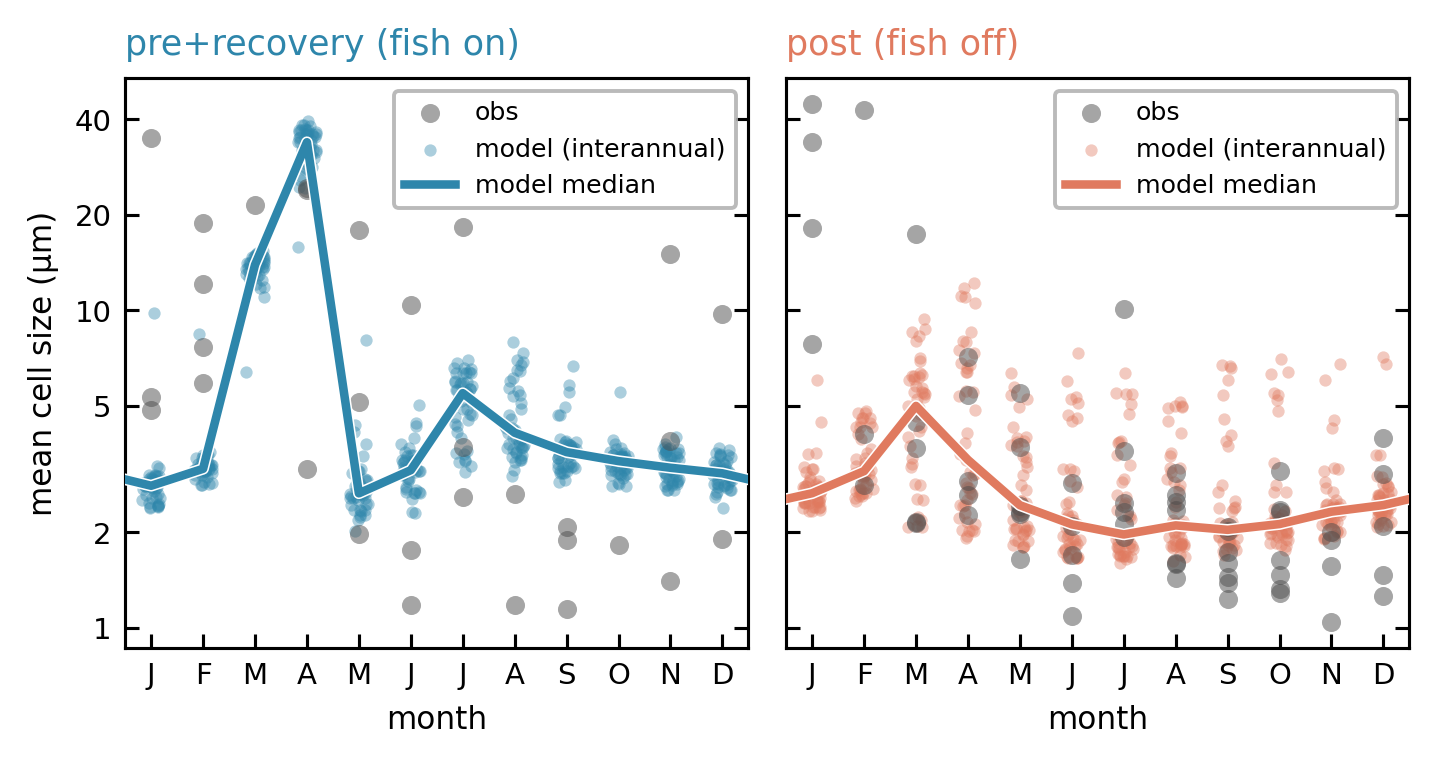

Looks like you are using a tranform that doesn't support FancyArrowPatch, using ax.annotate instead. The arrows might strike through texts. Increasing shrinkA in arrowprops might help.


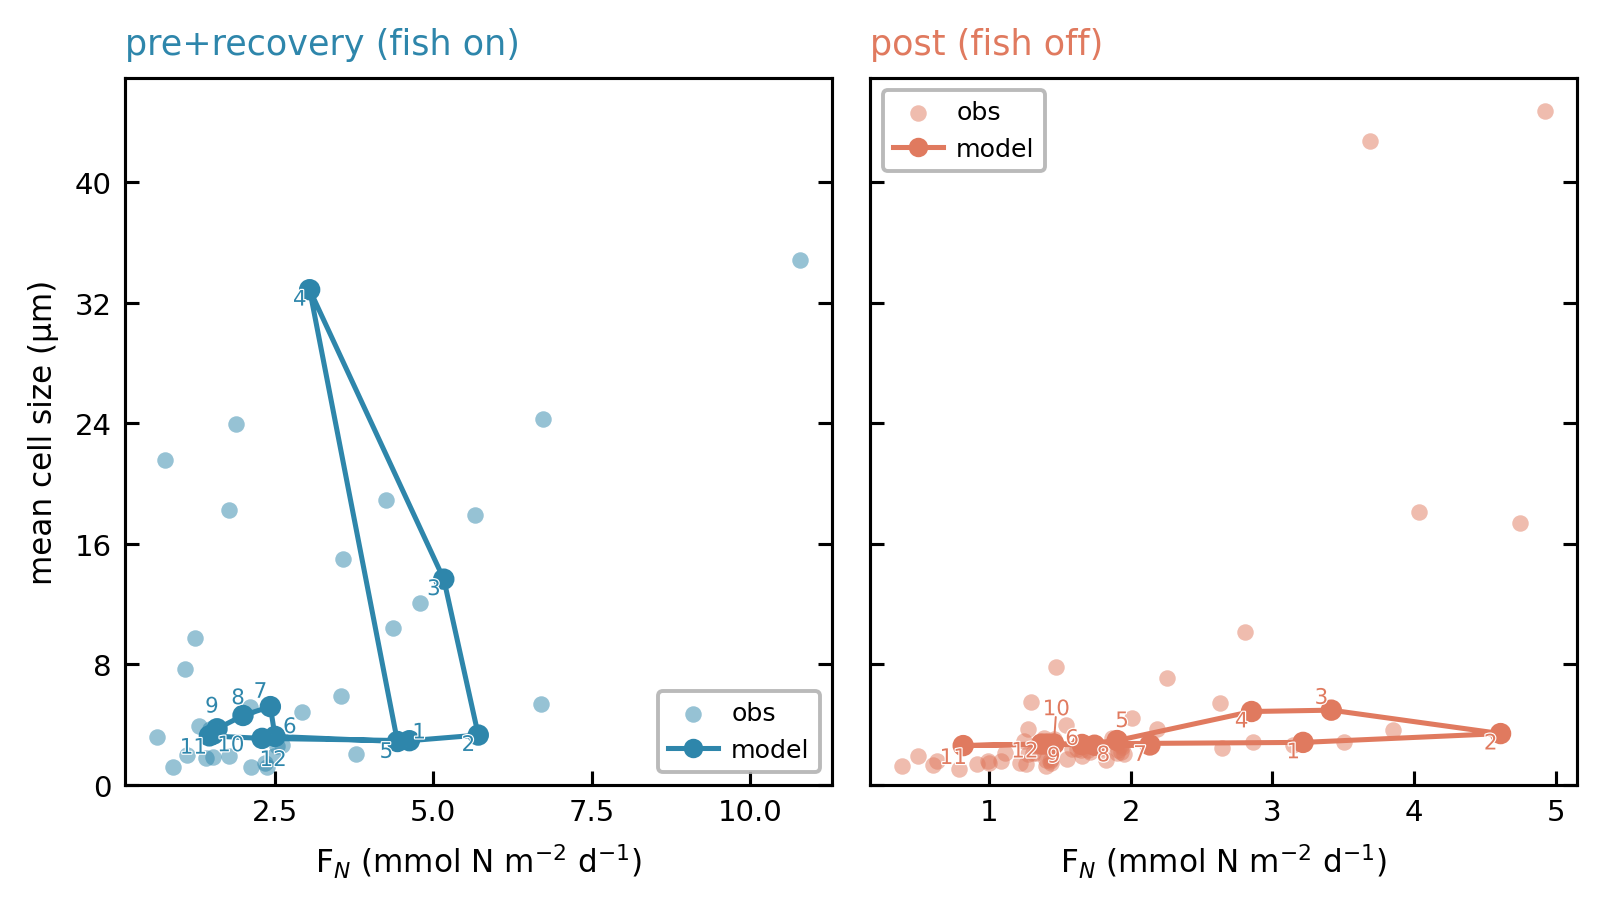

In [3]:
%config InlineBackend.figure_format = 'retina'
import matplotlib.pyplot as plt, fig4_panels as f4
__import__('importlib').reload(f4); f4.set_style()
D = f4.load_output()

# Cycle, pre | post — auto-corner legend, median wrapped
fig, axs = plt.subplots(1, 2, figsize=(5.2, 2.8), sharey=True)
f4.panel_cycle(axs[0], D, 'pre+recovery', 'mcs', show_ylabel=True,  show_legend=True)
f4.panel_cycle(axs[1], D, 'post',         'mcs', show_ylabel=False, show_legend=True)
fig.tight_layout(); plt.show()

# Phase, pre | post — 2D-nudged month labels, auto-corner legend, shared y to global obs max
top = max(D['obs_m'][e]['mcs'].max() for e in ('pre+recovery', 'post')) * 1.05
fig, axs = plt.subplots(1, 2, figsize=(5.8, 3.4), sharey=True)
f4.panel_mcs_fn(axs[0], D, 'pre+recovery', show_ylabel=True,  ymax=top)
f4.panel_mcs_fn(axs[1], D, 'post',         show_ylabel=False, ymax=top)
fig.tight_layout(); plt.show()

In [4]:
import pandas as pd, numpy as np
from cariaco_obs import DEFAULT_CSV_PATH

df = pd.read_csv(DEFAULT_CSV_PATH, parse_dates=['date'])
print("CSV:", DEFAULT_CSV_PATH)
cand = [c for c in df.columns if any(k in c.lower() for k in ('regime', 'upwell', 'transition', 'scenario')) or c.lower() == 'ui']
print("regime-like columns:", cand)
for c in cand:
    print(f"\n  {c}:\n{df[c].value_counts(dropna=False).to_string()}")

df['era'] = df['date'].dt.year.map(lambda y: 'pre' if y < 2005 else ('post' if y < 2014 else 'recovery'))
GE = {'pre+recovery': ['pre', 'recovery'], 'post': ['post']}
RC = next((c for c in ('regime_adjusted', 'upwelling') if c in df.columns), (cand[0] if cand else None))
print("\nusing regime column:", RC)

binc = ['pico_mmolN', 'nano_mmolN', 'micro_mmolN']; GEOM = np.array([0.63, 6.3, 63.0])
A = df[binc].to_numpy(float); tot = A.sum(1)
with np.errstate(invalid='ignore', divide='ignore'):
    fr = np.where(tot[:, None] > 0, A / tot[:, None], np.nan)
df['mcs'] = np.where(tot > 0, 10.0 ** (fr @ np.log10(GEOM)), np.nan)

if RC:
    for g, eras in GE.items():
        d = df[df['era'].isin(eras)]
        print(f"\n=== {g} ===  (months with mcs = {d['mcs'].notna().sum()})")
        print(pd.crosstab(d[RC], d['mcs'].notna()).to_string())
        tr = d[d[RC].astype(str).str.lower().str.contains('trans')].dropna(subset=['mcs'])
        print(f"  transition months with mcs (n={len(tr)}):")
        if len(tr):
            print(tr[['date', RC, 'FN_mmolN_m2_d', 'mcs']].to_string(index=False))

CSV: /Users/aoop/Documents/GitHub/Research/SSMCariaco/parameter_scan/../data/processed/cariaco_monthly_euphotic_dynamic.csv
regime-like columns: ['upwelling', 'ui', 'regime_adjusted']

  upwelling:
upwelling
relaxed      141
upwelling     87
NaN           27

  ui:
ui
relaxed     141
weak         50
moderate     33
NaN          27
strong        4

  regime_adjusted:
regime_adjusted
relaxed       127
upwelling      87
NaN            27
transition     14

using regime column: regime_adjusted

=== pre+recovery ===  (months with mcs = 31)
mcs              False  True 
regime_adjusted              
relaxed             50     12
transition           6      4
upwelling           42     15
  transition months with mcs (n=4):
      date regime_adjusted  FN_mmolN_m2_d       mcs
1997-01-01      transition      10.789882 34.814346
1997-06-01      transition       2.130114  1.181576
1998-04-01      transition       0.651520  3.155322
2000-01-01      transition       6.695399  5.337390

=== post ===

In [5]:
import pandas as pd, numpy as np
from cariaco_obs import DEFAULT_CSV_PATH

df = pd.read_csv(DEFAULT_CSV_PATH, parse_dates=['date'])
df['era'] = df['date'].dt.year.map(lambda y: 'pre' if y<2005 else ('post' if y<2014 else 'recovery'))
GE = {'pre+recovery': ['pre','recovery'], 'post': ['post']}
FORC = ['FN_mmolN_m2_d', 'depth_cutoff', 'Temp_C']
binc = ['pico_mmolN','nano_mmolN','micro_mmolN']; GEOM = np.array([0.63,6.3,63.0])
A = df[binc].to_numpy(float); tot = A.sum(1)
with np.errstate(invalid='ignore', divide='ignore'):
    fr = np.where(tot[:,None]>0, A/tot[:,None], np.nan)
df['mcs'] = np.where(tot>0, 10.0**(fr@np.log10(GEOM)), np.nan)
print("forcing cols present:", [c for c in FORC if c in df.columns])
df['forc_ok'] = df[[c for c in FORC if c in df.columns]].notna().all(axis=1)

for g, eras in GE.items():
    d = df[df['era'].isin(eras) & df['mcs'].notna()]
    print(f"\n=== {g} === ({len(d)} months with mcs)")
    print(f"  forcing-complete (F_N & d_e & T all present): {int(d['forc_ok'].sum())} / {len(d)}")
    for c in FORC:
        if c in d: print(f"    missing {c}: {int(d[c].isna().sum())}")
    inc = d[~d['forc_ok']]
    if len(inc):
        print(f"  forcing-INCOMPLETE months (n={len(inc)}) -- note their regime:")
        print(inc[['date','regime_adjusted','mcs']+[c for c in FORC if c in d]].to_string(index=False))
    out = d[d['date'].isin(pd.to_datetime(['1997-01-01','2012-01-01']))]
    if len(out):
        print("  the two Jan outliers:")
        print(out[['date','regime_adjusted','mcs','forc_ok']].to_string(index=False))

forcing cols present: ['FN_mmolN_m2_d', 'depth_cutoff', 'Temp_C']

=== pre+recovery === (31 months with mcs)
  forcing-complete (F_N & d_e & T all present): 31 / 31
    missing FN_mmolN_m2_d: 0
    missing depth_cutoff: 0
    missing Temp_C: 0
  the two Jan outliers:
      date regime_adjusted       mcs  forc_ok
1997-01-01      transition 34.814346     True

=== post === (64 months with mcs)
  forcing-complete (F_N & d_e & T all present): 57 / 64
    missing FN_mmolN_m2_d: 7
    missing depth_cutoff: 0
    missing Temp_C: 1
  forcing-INCOMPLETE months (n=7) -- note their regime:
      date regime_adjusted       mcs  FN_mmolN_m2_d  depth_cutoff    Temp_C
2008-06-01         relaxed  1.088575            NaN     36.787000 25.445085
2008-10-01         relaxed  1.286689            NaN     55.501632 27.426029
2009-02-01       upwelling  4.088679            NaN     47.005907       NaN
2009-04-01       upwelling  2.273371            NaN     46.786423 23.047842
2009-05-01       upwelling  2.2783

In [6]:
import pandas as pd, numpy as np
from cariaco_obs import DEFAULT_CSV_PATH

df = pd.read_csv(DEFAULT_CSV_PATH, parse_dates=['date'])
df['era'] = df['date'].dt.year.map(lambda y: 'pre' if y<2005 else ('post' if y<2014 else 'recovery'))
GE = {'pre+recovery': ['pre','recovery'], 'post': ['post']}
binc = ['pico_mmolN','nano_mmolN','micro_mmolN']; GEOM = np.array([0.63,6.3,63.0])
A = df[binc].to_numpy(float); tot = A.sum(1)
with np.errstate(invalid='ignore', divide='ignore'):
    fr = np.where(tot[:,None]>0, A/tot[:,None], np.nan)
df['mcs'] = np.where(tot>0, 10.0**(fr@np.log10(GEOM)), np.nan)
df['sumP'] = np.where(tot>0, tot, np.nan)
df['micro'] = fr[:,2]

METRICS = [('sumP','sumP (total P)'), ('mcs','mcs'), ('micro','micro frac'),
           ('NO3_mmolN','N'), ('PP_mmolN_m3_d','PP'), ('export_flux_corrected_mmolN','Export'),
           ('zoo_gt200_mmolN','Zoo>200'), ('FN_mmolN_m2_d','F_N')]
OUTLIERS = {'pre+recovery': '1997-01-01', 'post': '2012-01-01'}

for g, eras in GE.items():
    d = df[df['era'].isin(eras)]
    row = d[d['date'] == pd.Timestamp(OUTLIERS[g])].iloc[0]
    print(f"\n=== {g}: outlier {OUTLIERS[g]} (regime={row.get('regime_adjusted')}) ===")
    print(f"  {'metric':14} {'value':>9} {'era med':>9} {'era max':>9} {'%ile':>6}  (n)")
    for c, lab in METRICS:
        if c not in d.columns: continue
        s = d[c].dropna(); v = row[c]
        if pd.isna(v):
            print(f"  {lab:14} {'na':>9}"); continue
        pct = (s < v).mean() * 100
        print(f"  {lab:14} {v:9.2f} {s.median():9.2f} {s.max():9.2f} {pct:5.0f}%  ({len(s)})")


=== pre+recovery: outlier 1997-01-01 (regime=transition) ===
  metric             value   era med   era max   %ile  (n)
  sumP (total P)      2.52      0.53      2.52    97%  (31)
  mcs                34.81      4.84     34.81    97%  (31)
  micro frac          0.85      0.27      0.85    97%  (31)
  N                   2.37      1.20      6.79    84%  (98)
  PP                  2.97      0.29      5.21    97%  (107)
  Export              3.34      2.68     18.39    68%  (74)
  Zoo>200               na
  F_N                10.79      2.26     21.34    98%  (105)

=== post: outlier 2012-01-01 (regime=transition) ===
  metric             value   era med   era max   %ile  (n)
  sumP (total P)      1.82      0.46      3.49    97%  (64)
  mcs                44.71      2.30     44.71    98%  (64)
  micro frac          0.90      0.13      0.90    98%  (64)
  N                   0.30      1.09      5.19    20%  (83)
  PP                  0.93      0.20      3.15    95%  (81)
  Export         

[fig4] loaded /Users/aoop/Documents/GitHub/Research/SSMCariaco/plots/results/fig4_modeloutput.pkl
       {'construct': 'maranon_ward', 'params': {'GGE': 0.31, 'mP': 0.0015, 'm_Z': 0.1, 'KsZ': 0.23, 'sigma_log': 0.2}, 'fish': {'pre+recovery': 0.4, 'post': 0.0}, 'solver_floor': -0.01, 'created': '2026-06-23 12:09'}


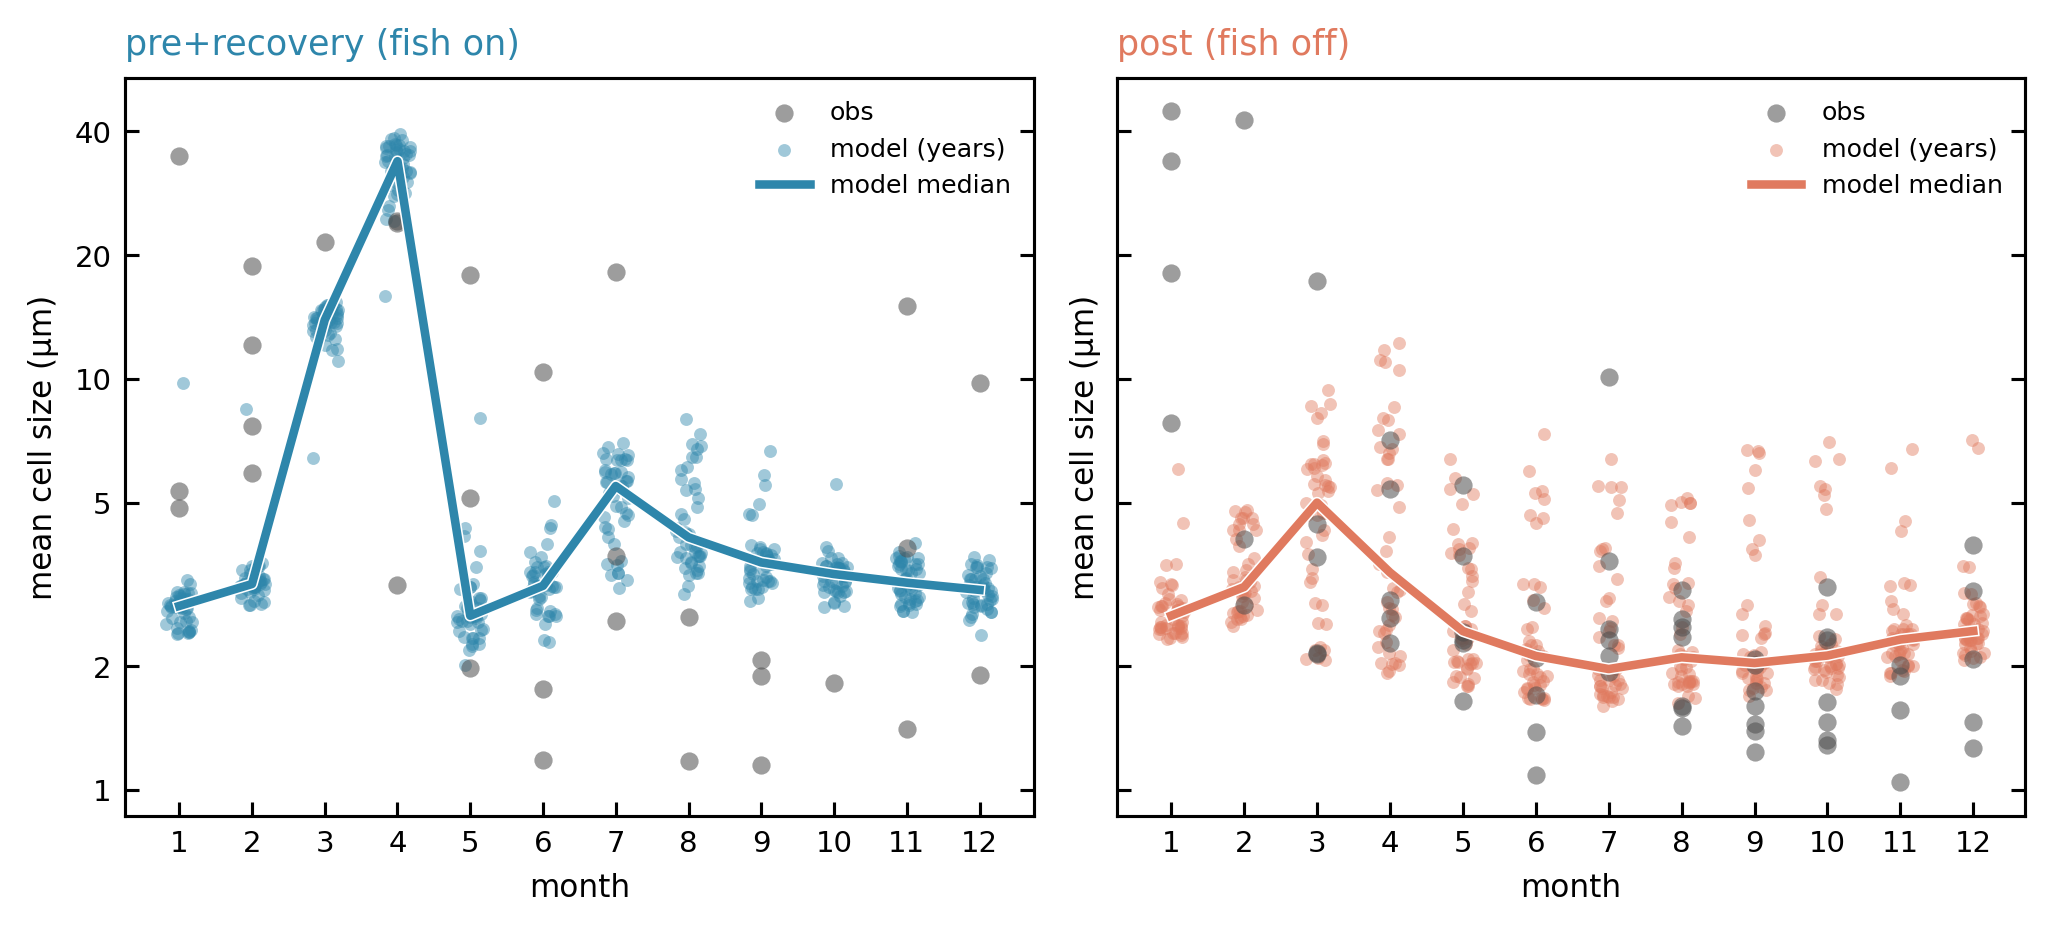

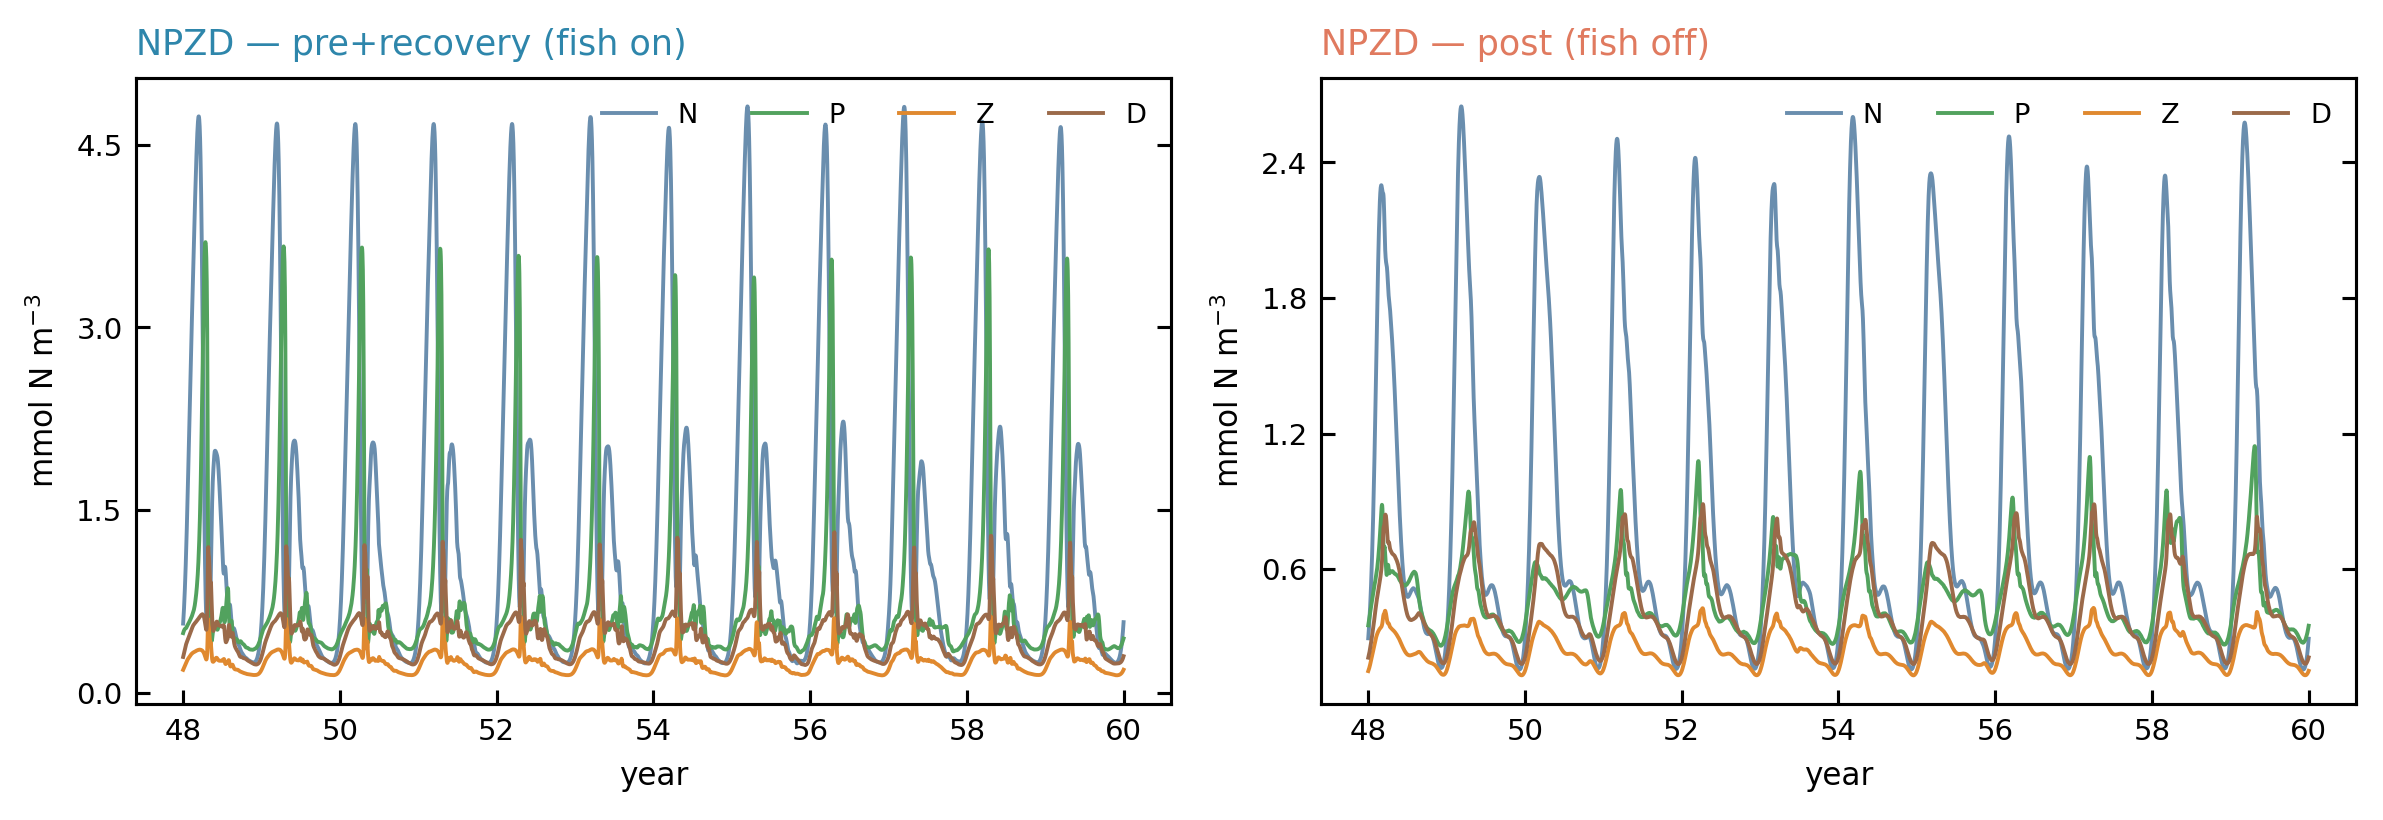

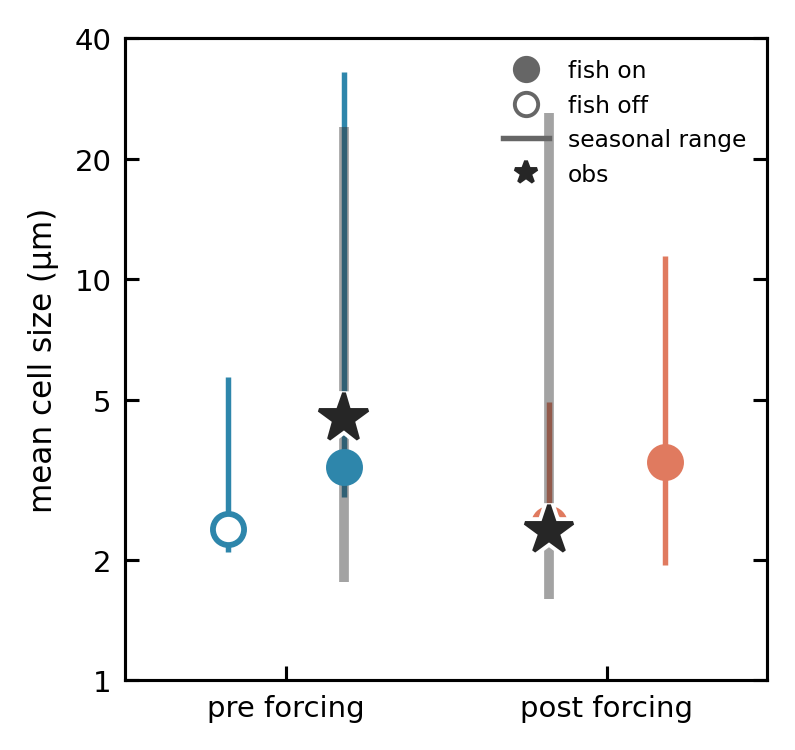

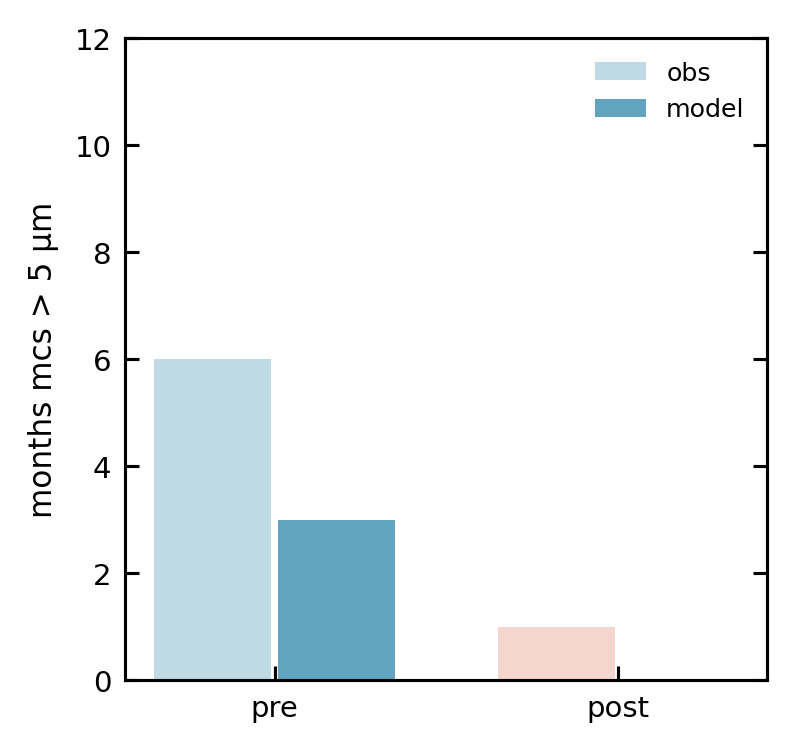

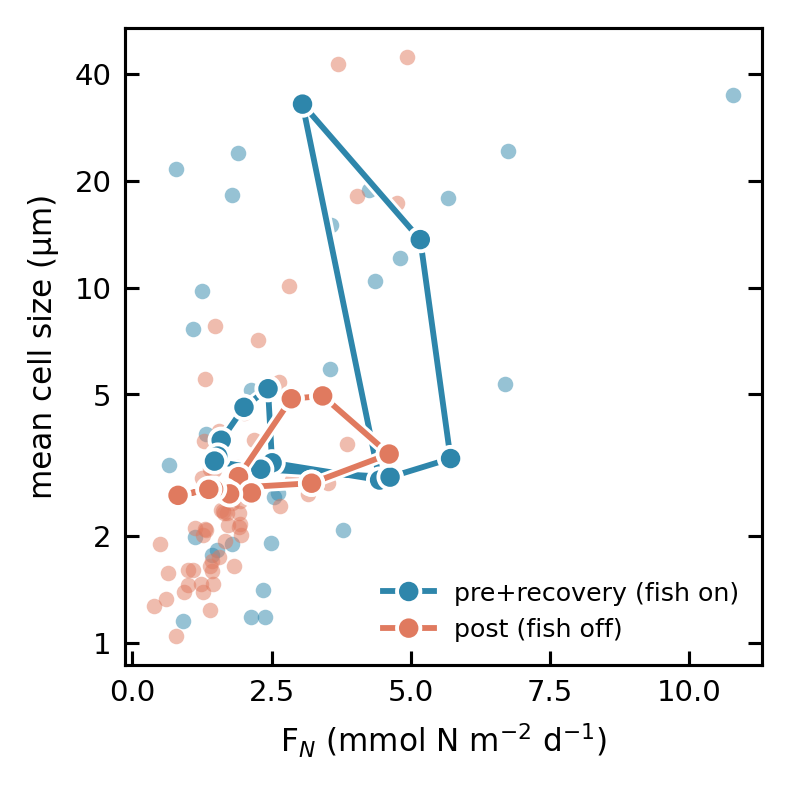

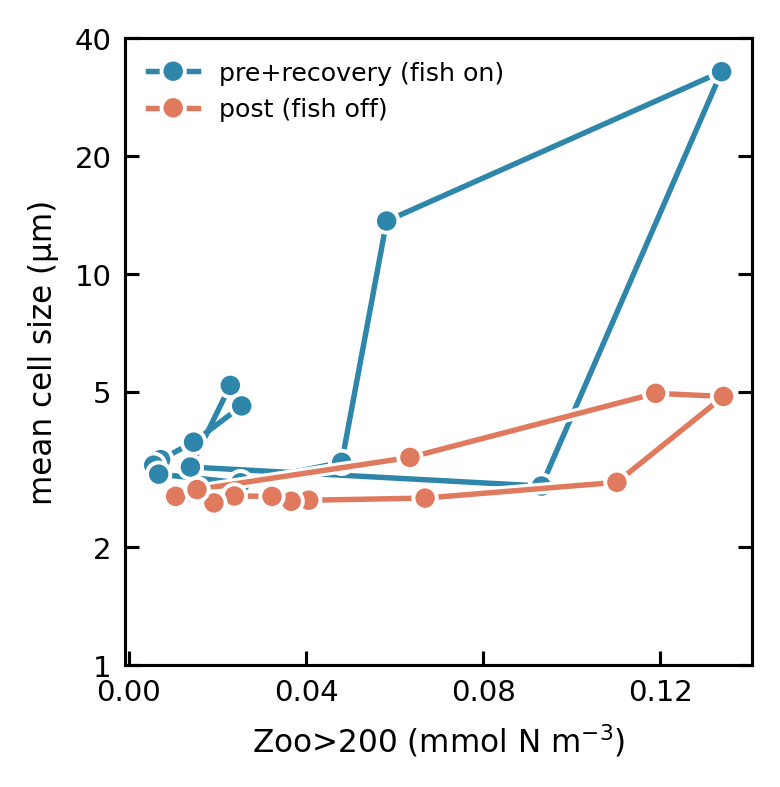

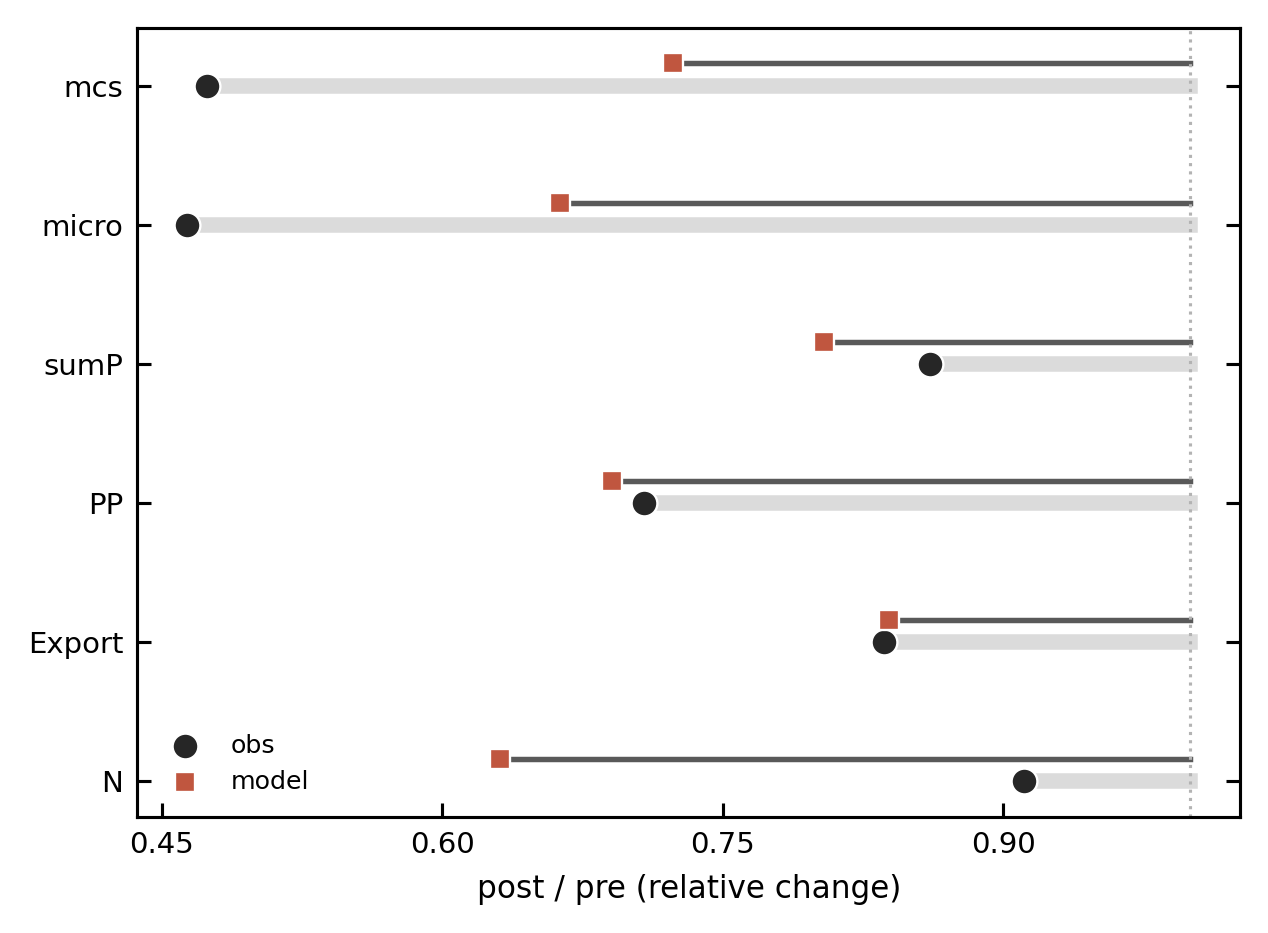

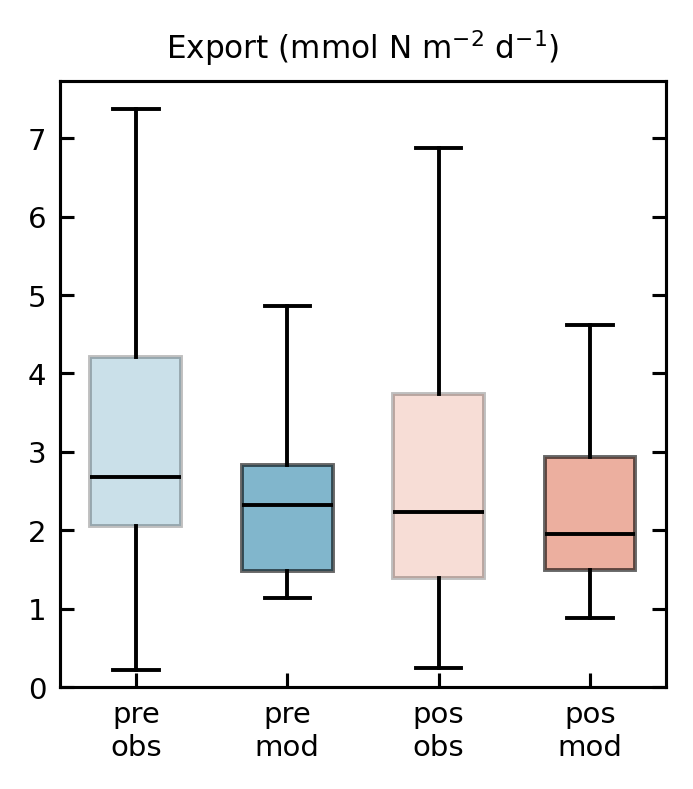

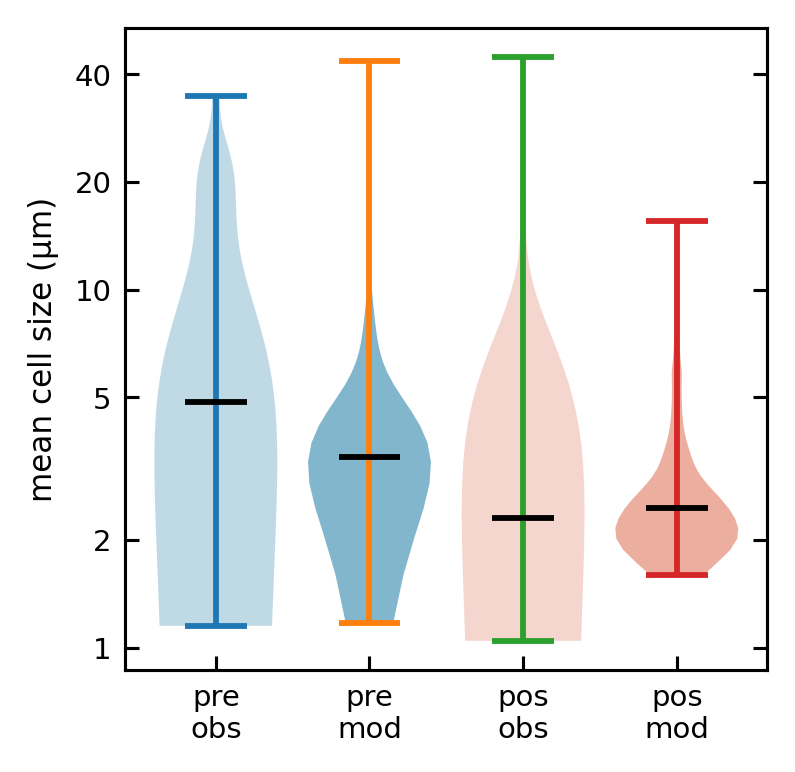

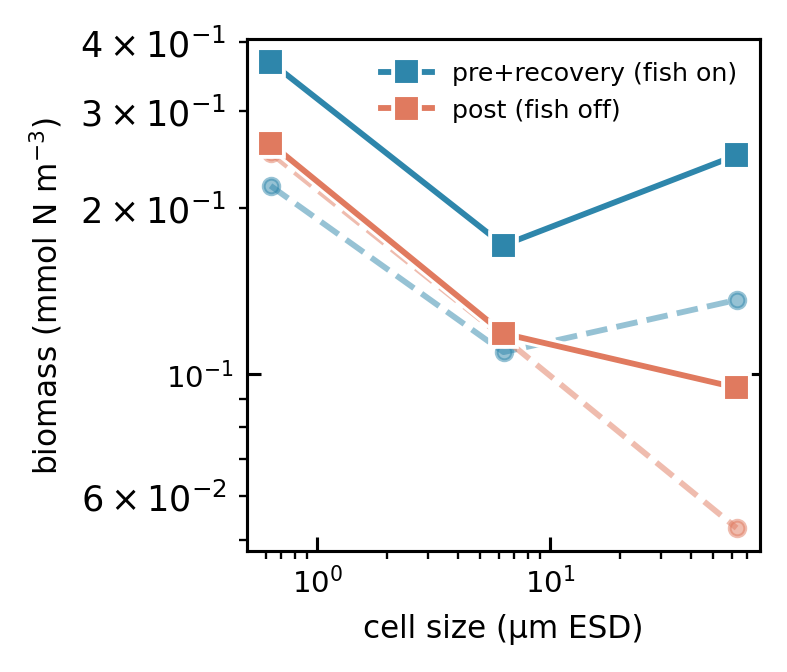

In [4]:
%config InlineBackend.figure_format = 'retina'
import matplotlib.pyplot as plt, fig4_panels as f4
__import__('importlib').reload(f4); f4.set_style()
D = f4.load_output()            # prints metadata; warns if stale vs module PARAMS

fig, axs = plt.subplots(1, 2, figsize=(7.4, 3.4), sharey=True)
f4.panel_cycle(axs[0], D, 'pre+recovery', 'mcs'); f4.panel_cycle(axs[1], D, 'post', 'mcs')
fig.tight_layout(); plt.show()

# NPZD state time series: pre | post  (add logy=True if N dwarfs Z/D)
fig, axs = plt.subplots(1, 2, figsize=(8.6, 3.0))
f4.panel_npzd(axs[0], D, 'pre+recovery'); f4.panel_npzd(axs[1], D, 'post')
fig.tight_layout(); plt.show()

def show(fn, *a, figsize=(2.9, 2.9), **k):             # ~Fig 3 per-panel scale
    fig, ax = plt.subplots(figsize=figsize); fn(ax, D, *a, **k); fig.tight_layout(); plt.show()

show(f4.panel_2x2, 'mcs')
show(f4.panel_duration)
show(f4.panel_mcs_fn, loop=True)
show(f4.panel_phase)
show(f4.panel_dumbbell, figsize=(4.6, 3.4))            # appendix
# appendix: show(f4.panel_box,'Export'); show(f4.panel_violin,'mcs'); show(f4.panel_spectrum)
show(f4.panel_box,'Export')
show(f4.panel_violin,'mcs')
show(f4.panel_spectrum)

In [5]:
import numpy as np, seasonal_scan_harness as ssh, fig4_panels as f4
forc = ssh.build_forcings(['pre+recovery'])['pre+recovery']
spec = ssh.allometry(f4.CONSTRUCT); P = f4.PARAMS
print(f"{'fish+eps':>9} {'mcs@2000d':>10} {'mcs@5000d':>10} {'mcs_mean':>9} {'mcs_med':>8} {'micro_med':>10} {'Z200_med':>9} {'nan':>5}")
for eps in (0.0, 0.0, 1e-9, 1e-8, 1e-7):
    clim, r = ssh.run_one(spec, forc, fish_rate=0.4 + eps, years=60, spinup=15,
                          mP=P['mP'], m_Z=P['m_Z'],
                          grazing={'KsZ': P['KsZ'], 'sigma_log': P['sigma_log']},
                          iv_overrides={'GrazingRouter': {'gge': P['GGE']}},
                          solver_kwargs=f4.SK, return_traj=True)
    print(f"{eps:9.0e} {r['mcs'][2000]:10.4f} {r['mcs'][5000]:10.4f} "
          f"{clim.get('mcs', np.nan):9.3f} {clim.get('mcs_med', np.nan):8.3f} "
          f"{clim.get('micro_med', np.nan):10.3f} {clim.get('Z200_med', np.nan):9.4f} {str(clim.get('has_nan')):>5}")

 fish+eps  mcs@2000d  mcs@5000d  mcs_mean  mcs_med  micro_med  Z200_med   nan
    0e+00     5.1894     3.1639     6.820    3.398      0.250    0.0177 False
    0e+00     5.1894     3.1639     6.820    3.398      0.250    0.0177 False
    1e-09     5.1192     5.5047     6.808    3.368      0.248    0.0164 False


/Users/aoop/Documents/GitHub/Research/xarray-simlab-ode/src/xso/core.py:148: UserWarning: Instability event triggered at t=7422 on Z[1] = -0.122. Run terminated, remaining time points NaN-padded. To loosen the safety threshold pass solver_kwargs={'instability_neg_threshold': -1e-3} to xso.setup; to disable, pass float('-inf').
  self.solver.solve(self.model, time_step)


    1e-08     5.6414     3.7775       nan      nan        nan       nan  True
    1e-07     5.4513     6.1247     6.810    3.403      0.250    0.0170 False


In [26]:
import numpy as np
import fig4_panels as f4, seasonal_scan_harness as ssh

D     = f4.load_output()
obs_m = ssh.build_obs_monthly(['pre+recovery', 'post'])     # forcing-complete
DIAG  = {'pre+recovery': 0.4, 'post': 0.0}                  # era -> fish r_F (diagonal runs)
SPIN  = 15
POOLS = ['sumP', 'N', 'Z200', 'Z500']
FRAC  = ['pico', 'nano', 'micro']

def q(v):
    v = np.asarray(v, float); v = v[np.isfinite(v)]
    return (np.nan,)*3 if v.size == 0 else (np.median(v), np.percentile(v, 25), np.percentile(v, 75))

print("run keys:", sorted(k for k in D['runs'][('post', 0.0)][1]))
for era, fish in DIAG.items():
    r = D['runs'][(era, fish)][1]; keep = r['t'] >= SPIN*365.0; om = obs_m[era]
    print(f"\n=== {era}  (fish r_F={fish}) ===   model days={int(keep.sum())}  obs months={len(om)}")
    print(f"{'metric':6s} | {'model med [IQR]':>28s} | {'obs med [IQR]':>28s} |  m/o")
    for k in POOLS:
        mm, ml, mh = q(r[k][keep]); oo, ol, oh = q(om[k])
        ratio = mm/oo if (np.isfinite(oo) and oo > 0) else np.nan
        print(f"{k:6s} | {mm:9.3f} [{ml:8.3f},{mh:8.3f}] | {oo:9.3f} [{ol:8.3f},{oh:8.3f}] | {ratio:5.2f}")
    mf = [np.nanmedian(r[k][keep]) for k in FRAC]; of = [np.nanmedian(om[k]) for k in FRAC]
    print("frac   | model " + "  ".join(f"{k}={v:.2f}" for k, v in zip(FRAC, mf)) +
          "   | obs " + "  ".join(f"{k}={v:.2f}" for k, v in zip(FRAC, of)))

[fig4] loaded /Users/aoop/Documents/GitHub/Research/SSMCariaco/plots/results/fig4_modeloutput.pkl
       {'construct': 'maranon_ward', 'params': {'GGE': 0.31, 'mP': 0.0015, 'm_Z': 0.1, 'KsZ': 0.23, 'sigma_log': 0.2}, 'fish': {'pre+recovery': 0.4, 'post': 0.0}, 'solver_floor': -0.01, 'created': '2026-06-23 12:09'}
run keys: ['D', 'Export', 'FN', 'N', 'PP', 'T', 'Z200', 'Z500', 'Ztot', 'de', 'mcs', 'micro', 'minP', 'minZ', 'nano', 'pico', 'sumP', 't']

=== pre+recovery  (fish r_F=0.4) ===   model days=16425  obs months=105
metric |              model med [IQR] |                obs med [IQR] |  m/o
sumP   |     0.534 [   0.411,   0.690] |     0.535 [   0.410,   0.660] |  1.00
N      |     0.827 [   0.361,   1.848] |     1.286 [   0.629,   1.857] |  0.64
Z200   |     0.018 [   0.009,   0.049] |     0.053 [   0.028,   0.068] |  0.33
Z500   |     0.000 [   0.000,   0.010] |     0.024 [   0.015,   0.041] |  0.01
frac   | model pico=0.52  nano=0.23  micro=0.25   | obs pico=0.43  nano=0.21  mic

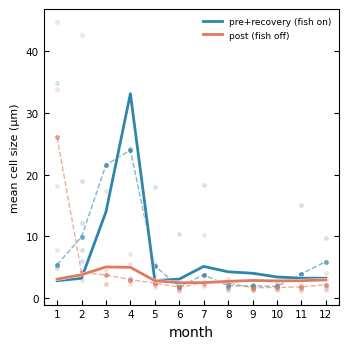

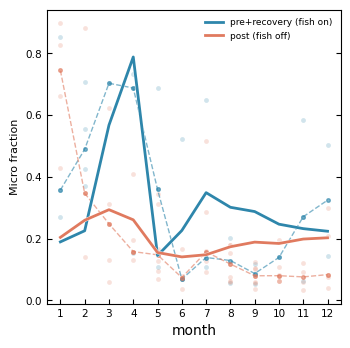

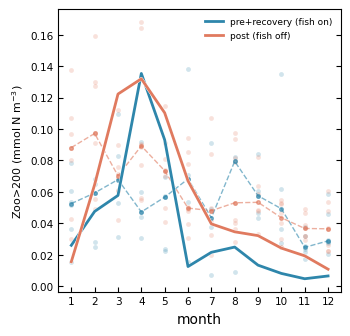

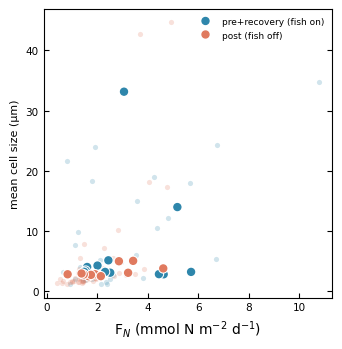

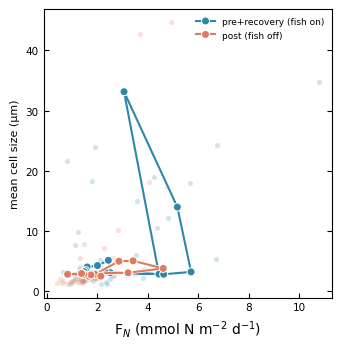

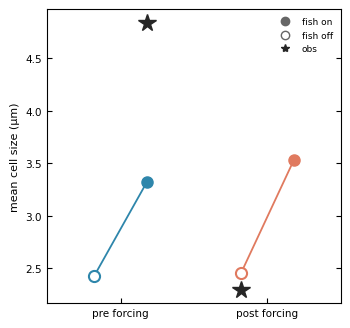

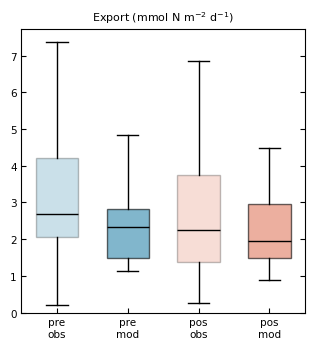

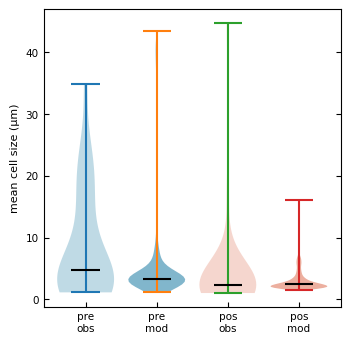

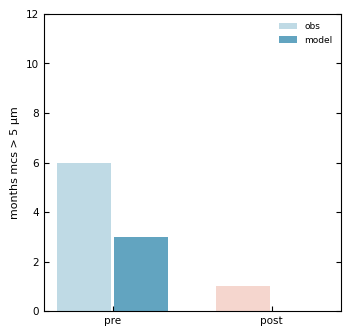

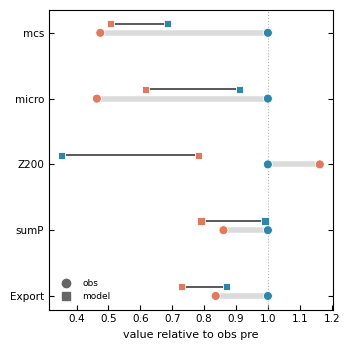

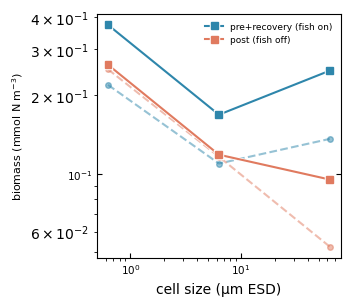

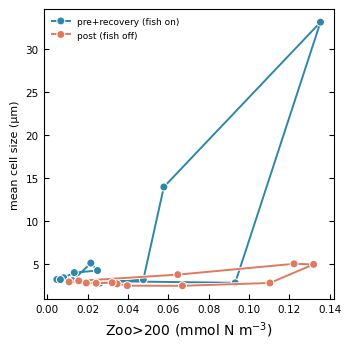

In [2]:
import importlib, matplotlib.pyplot as plt
import fig4_panels as f4
importlib.reload(f4)                       # (1-thread header must be active above this)

D = f4.prep()                              # 4 x 60-yr runs + obs, ~1-2 min

def show(fn, *a, figsize=(3.6, 3.6), **k):
    fig, ax = plt.subplots(figsize=figsize)
    fn(ax, D, *a, **k); fig.tight_layout(); plt.show()

show(f4.panel_cycle, 'mcs')                # 1  mcs seasonal cycle  (headline)
show(f4.panel_cycle, 'micro')              # 2  Micro-fraction cycle
show(f4.panel_cycle, 'Z200')               # 3  Zoo>200 cycle
show(f4.panel_mcs_fn)                       # 4  mcs vs F_N scatter
show(f4.panel_mcs_fn, loop=True)            # 5  (F_N, mcs) within-year loop
show(f4.panel_2x2, 'mcs')                   # 6  the 2x2 (model completes the experiment)
show(f4.panel_box, 'Export')                # 7  multi-metric boxplot (appendix) -- swap metric
show(f4.panel_violin, 'mcs')                # 8  mcs distribution violin (appendix)
show(f4.panel_duration)                     # 9  bloom-duration bar (era contrast)
show(f4.panel_dumbbell)                     # 10 pre->post dumbbell (appendix)
show(f4.panel_spectrum)                     # 11 3-bin biomass spectrum (appendix)
show(f4.panel_phase)                        # 12 mcs-Zoo>200 phase loop

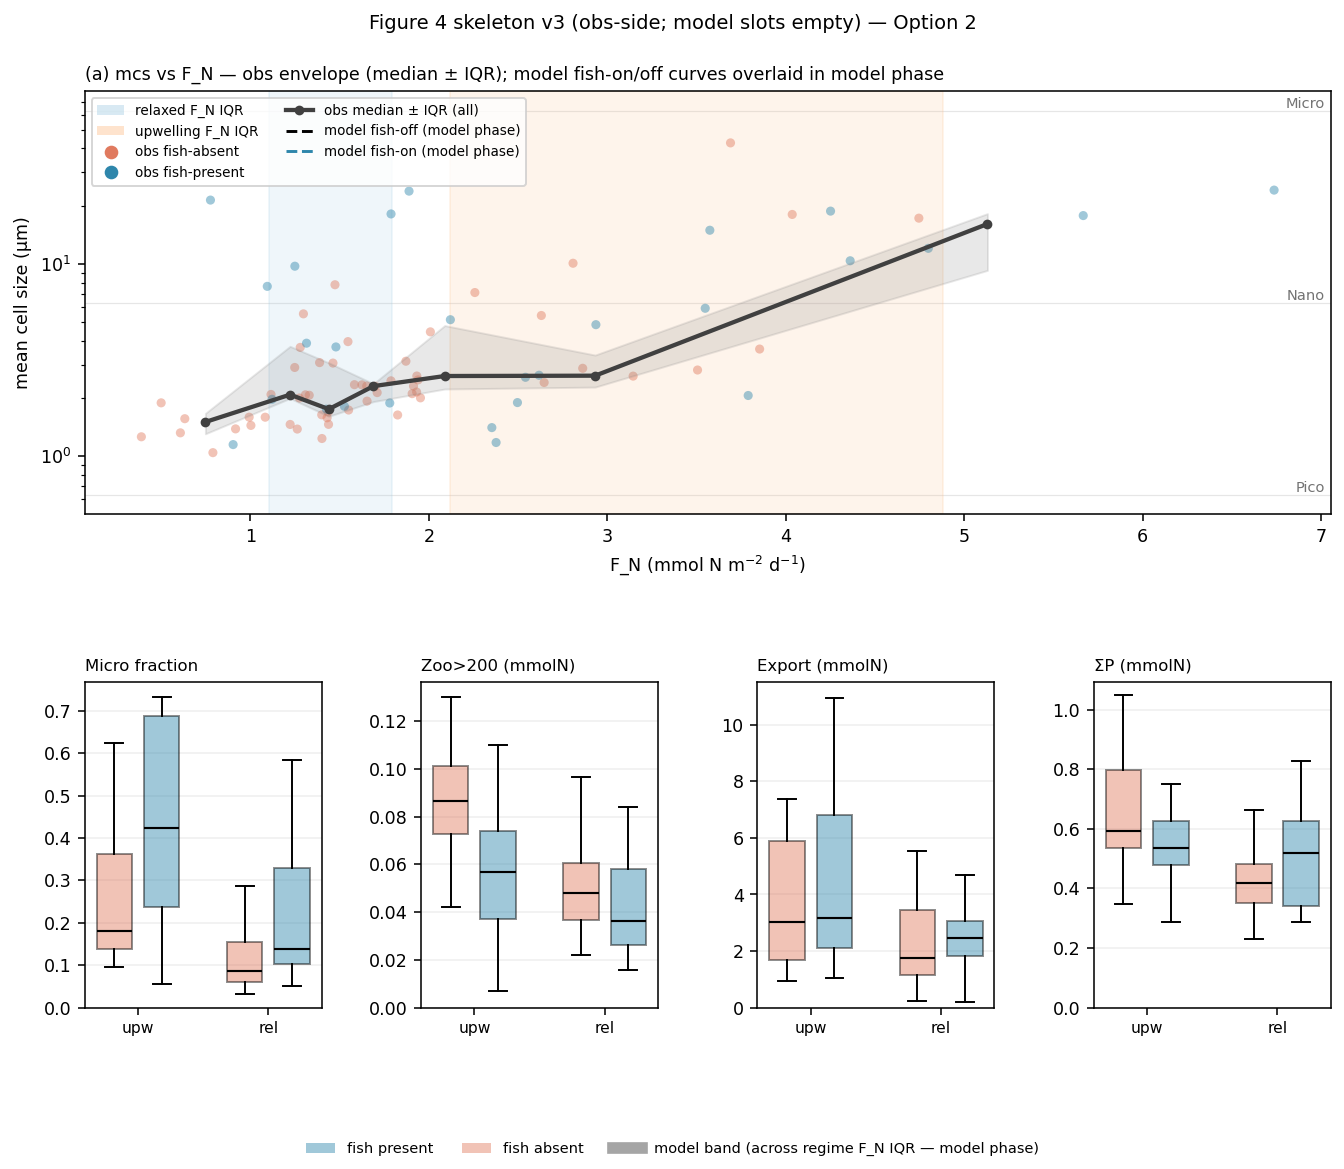

In [2]:
# ============================================================================
# Fig 4 SKELETON v3 (obs-side). Panel (a): single all-obs envelope (binned
# median ± IQR) + faint points by fish; NO per-fish trend lines (their F_N
# ranges barely overlap → leverage artifact; high-F_N fish-absent is unobserved).
# Model fish-on/off curves reserved for the model phase. Panel (b) unchanged.
# ============================================================================
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from matplotlib.gridspec import GridSpec
try:
    from cariaco_obs import DEFAULT_CSV_PATH as CSV
except Exception:
    CSV = "data/processed/cariaco_monthly_euphotic_dynamic.csv"

PHYTO=["pico_mmolN","nano_mmolN","micro_mmolN"]; LOG_GEO=np.log10([0.63,6.3,63.0]); GEO=np.array([0.63,6.3,63.0])
FN="FN_mmolN_m2_d"; PRE,REC=pd.Timestamp("2005-01-01"),pd.Timestamp("2014-01-01")
COLF={"present":"#2E86AB","absent":"#E07A5F"}

df=pd.read_csv(CSV); df["date"]=pd.to_datetime(df["date"])
Aa=df[PHYTO].to_numpy(float); tot=Aa.sum(1)
with np.errstate(invalid="ignore",divide="ignore"):
    fr=np.where(tot[:,None]>0,Aa/tot[:,None],np.nan)
df["centroid"]=np.where(tot>0,np.nansum(fr*LOG_GEO,1),np.nan); df["mcs"]=10**df["centroid"]
df["micro_frac"]=fr[:,2]; df["phyto_total"]=tot
era=np.where(df.date<PRE,"pre",np.where(df.date>=REC,"recovery","post"))
df["fish"]=np.where(era=="post","absent","present")
df["regime"]=df["regime_adjusted"] if "regime_adjusted" in df.columns else df["upwelling"]
d=df[df["regime"].isin(["upwelling","relaxed"])].copy()
dm=d[d["centroid"].notna() & d[FN].notna()]

plt.rcParams.update({"figure.dpi":140,"font.size":9})
fig=plt.figure(figsize=(10,8.5))
gs=GridSpec(2,4,figure=fig,height_ratios=[1.3,1],top=0.90,bottom=0.13,left=0.08,right=0.97,hspace=0.45,wspace=0.42)

axa=fig.add_subplot(gs[0,:])
for bg in GEO: axa.axhline(bg,color="0.9",lw=0.6,zorder=0)
band_h=[]
for reg,c in [("relaxed","#9ecae1"),("upwelling","#fdbb84")]:
    q=d.loc[d.regime==reg,FN].quantile([.25,.75])
    axa.axvspan(q[.25],q[.75],color=c,alpha=0.16,zorder=0); band_h.append(Patch(facecolor=c,alpha=0.4,label=f"{reg} F_N IQR"))
for fi in ["absent","present"]:
    s=dm[dm.fish==fi]; axa.scatter(s[FN],s["mcs"],s=22,c=COLF[fi],edgecolors="none",alpha=0.45,zorder=2)
bins=np.quantile(dm[FN],np.linspace(0,1,8)); ctr=0.5*(bins[:-1]+bins[1:]); med=[];lo=[];hi=[]
for i in range(len(bins)-1):
    v=dm.loc[(dm[FN]>=bins[i])&(dm[FN]<=bins[i+1]),"mcs"]; med.append(v.median()); lo.append(v.quantile(.25)); hi.append(v.quantile(.75))
axa.fill_between(ctr,lo,hi,color="0.5",alpha=0.18,zorder=3)
axa.plot(ctr,med,color="0.25",lw=2.2,marker="o",ms=4,zorder=4)
axa.set_yscale("log"); axa.set_xlabel("F_N (mmol N m$^{-2}$ d$^{-1}$)"); axa.set_ylabel("mean cell size (µm)")
tr=axa.get_yaxis_transform()
for bg,l in zip(GEO,["Pico","Nano","Micro"]): axa.text(0.995,bg,l,transform=tr,ha="right",va="bottom",fontsize=7.5,color="0.45")
axa.legend(handles=band_h+[
    Line2D([],[],marker='o',ls='',color=COLF['absent'],label='obs fish-absent'),
    Line2D([],[],marker='o',ls='',color=COLF['present'],label='obs fish-present'),
    Line2D([],[],color='0.25',lw=2.2,marker='o',ms=4,label='obs median ± IQR (all)'),
    Line2D([],[],color='k',ls='--',label='model fish-off (model phase)'),
    Line2D([],[],color=COLF['present'],ls='--',label='model fish-on (model phase)')],
    fontsize=7,ncol=2,loc="upper left")
axa.set_title("(a) mcs vs F_N — obs envelope (median ± IQR); model fish-on/off curves overlaid in model phase",loc="left",fontsize=9)

cells=[("upwelling","absent"),("upwelling","present"),("relaxed","absent"),("relaxed","present")]
pos=[1,1.8,3.2,4.0]
metr=[("micro_frac","Micro fraction"),("zoo_gt200_mmolN","Zoo>200 (mmolN)"),
      ("export_flux_corrected_mmolN","Export (mmolN)"),("phyto_total","ΣP (mmolN)")]
for j,(col,lab) in enumerate(metr):
    ax=fig.add_subplot(gs[1,j])
    if col not in d.columns: ax.set_title(f"[missing] {lab}"); ax.axis("off"); continue
    data=[d[(d.regime==r)&(d.fish==f)][col].dropna().values for r,f in cells]
    bp=ax.boxplot(data,positions=pos,widths=0.6,patch_artist=True,showfliers=False,medianprops=dict(color="k",lw=1.1))
    for b,(r,f) in zip(bp["boxes"],cells): b.set_facecolor(COLF[f]); b.set_alpha(0.45)
    ax.set_xticks([1.4,3.6]); ax.set_xticklabels(["upw","rel"],fontsize=8); ax.set_ylim(bottom=0)
    ax.set_title(lab,loc="left",fontsize=8.5); ax.grid(alpha=0.2,axis="y")
fig.legend(handles=[Patch(facecolor=COLF['present'],alpha=0.45,label='fish present'),
                    Patch(facecolor=COLF['absent'],alpha=0.45,label='fish absent'),
                    Line2D([],[],color='0.3',lw=6,alpha=0.5,label='model band (across regime F_N IQR — model phase)')],
           fontsize=7.5,loc="lower center",ncol=3,frameon=False)
fig.suptitle("Figure 4 skeleton v3 (obs-side; model slots empty) — Option 2",fontsize=10,y=0.965)
plt.show()

In [3]:
# ============================================================================
# Fig 4 — Step 1: mcs-vs-F_N era separation in the overlap window (SWEEP TABLE)
# Quantifies the size level-shift on the F_N axis, restricted to the F_N range
# the eras share. Sweeps every "check both" toggle:
#   scope    : pooled (all regimes) | within-upwelling
#   metric   : raw centroid | deseasonalised (monthly climatology removed)
#   window   : strict (full F_N intersection) | trimmed (5-95 pct intersection)
#   grouping : pre vs post | (pre+recovery) vs post
# Per combo: n/group, F_N window, F_N-controlled level-shift (OLS centroid ~
# F_N + is_high; coef in centroid units + 10^coef fold in µm), 95% CI & p, the
# F_N*era interaction p (clean-level-shift check vs the full-range p=0.002), and
# a non-parametric median cross-check (one-sided Mann-Whitney, high>low). No model.
# ============================================================================
import numpy as np, pandas as pd
import statsmodels.formula.api as smf
from scipy.stats import mannwhitneyu

try:
    from cariaco_obs import DEFAULT_CSV_PATH as CSV
except Exception:
    CSV = "data/processed/cariaco_monthly_euphotic_dynamic.csv"  # adjust to your path

PHYTO  = ["pico_mmolN", "nano_mmolN", "micro_mmolN"]
LOG_GEO = np.log10([0.63, 6.3, 63.0])          # Sieburth bin geomeans (µm)
FN = "FN_mmolN_m2_d"
PRE_CUT, REC_CUT = pd.Timestamp("2005-01-01"), pd.Timestamp("2014-01-01")

# ---- load + per-month centroid (= R size_centroid) -------------------------
df = pd.read_csv(CSV); df["date"] = pd.to_datetime(df["date"])
P = df[PHYTO].to_numpy(float); tot = P.sum(1)
with np.errstate(invalid="ignore", divide="ignore"):
    fr = np.where(tot[:, None] > 0, P / tot[:, None], np.nan)
df["centroid"] = np.where(tot > 0, np.nansum(fr * LOG_GEO, 1), np.nan)
# deseasonalised: subtract monthly climatology, re-centre on overall mean (Fig 3 procedure)
df["centroid_ds"] = (df["centroid"]
                     - df.groupby(df["date"].dt.month)["centroid"].transform("mean")
                     + df["centroid"].mean())
df["era"] = np.where(df["date"] < PRE_CUT, "pre",
            np.where(df["date"] >= REC_CUT, "recovery", "post"))
df["regime"] = df["regime_adjusted"] if "regime_adjusted" in df.columns else df["upwelling"]

d = df[df["centroid"].notna() & df[FN].notna()].copy()   # HPLC months w/ valid F_N

def overlap(a, b, q):
    return max(a.quantile(q), b.quantile(q)), min(a.quantile(1 - q), b.quantile(1 - q))

def one(scope, metric, window, grouping):
    sub  = d if scope == "pooled" else d[d["regime"] == "upwelling"]
    high = ["pre", "recovery"] if grouping == "prerec_vs_post" else ["pre"]
    g = sub[sub["era"].isin(high + ["post"])].copy()
    g["is_high"] = g["era"].isin(high).astype(int)
    q = 0.0 if window == "strict" else 0.05
    lo, hi = overlap(g.loc[g.is_high == 1, FN], g.loc[g.is_high == 0, FN], q)
    w = g[(g[FN] >= lo) & (g[FN] <= hi)]
    y = "centroid" if metric == "raw" else "centroid_ds"
    nh, nl = int((w.is_high == 1).sum()), int((w.is_high == 0).sum())
    r = dict(scope=scope, metric=metric, window=window, grouping=grouping,
             n_hi=nh, n_lo=nl, FN_lo=round(lo, 2), FN_hi=round(hi, 2))
    if nh >= 3 and nl >= 3:
        m  = smf.ols(f"{y} ~ {FN} + is_high", data=w).fit()
        mi = smf.ols(f"{y} ~ {FN} * is_high", data=w).fit()
        coef, ci = m.params["is_high"], m.conf_int().loc["is_high"]
        hv, lv = w.loc[w.is_high == 1, y], w.loc[w.is_high == 0, y]
        try: pmw = mannwhitneyu(hv, lv, alternative="greater").pvalue
        except ValueError: pmw = np.nan
        r.update(dshift=round(coef, 3), fold_um=round(10 ** coef, 2),
                 ci=f"[{ci[0]:+.2f},{ci[1]:+.2f}]", p_shift=round(m.pvalues["is_high"], 4),
                 p_inter=round(mi.pvalues[f"{FN}:is_high"], 4),
                 med_hi=round(hv.median(), 3), med_lo=round(lv.median(), 3),
                 p_mwu=round(pmw, 4))
    else:
        r.update(dshift=np.nan, fold_um=np.nan, ci="-", p_shift=np.nan,
                 p_inter=np.nan, med_hi=np.nan, med_lo=np.nan, p_mwu=np.nan)
    return r

tab = pd.DataFrame([one(s, m, w, gr)
                    for s  in ("pooled", "within-upwelling")
                    for m  in ("raw", "deseason")
                    for w  in ("strict", "trimmed")
                    for gr in ("pre_vs_post", "prerec_vs_post")])
pd.set_option("display.width", 220, "display.max_columns", 50)
print(f"HPLC+F_N months: {len(d)} | regimes: {dict(d['regime'].value_counts())}")
print(f"era n: {dict(d['era'].value_counts())}\n")
print(tab.to_string(index=False))

HPLC+F_N months: 88 | regimes: {'relaxed': np.int64(54), 'upwelling': np.int64(28), 'transition': np.int64(6)}
era n: {'post': np.int64(57), 'pre': np.int64(17), 'recovery': np.int64(14)}

           scope   metric  window       grouping  n_hi  n_lo  FN_lo  FN_hi  dshift  fold_um            ci  p_shift  p_inter  med_hi  med_lo  p_mwu
          pooled      raw  strict    pre_vs_post    13    53   0.65   4.92   0.106     1.28 [-0.06,+0.27]   0.2033   0.1838   0.685   0.372 0.0589
          pooled      raw  strict prerec_vs_post    27    53   0.65   4.92   0.100     1.26 [-0.05,+0.25]   0.1929   0.0072   0.569   0.372 0.0701
          pooled      raw trimmed    pre_vs_post    11    46   1.01   3.89   0.107     1.28 [-0.08,+0.29]   0.2518   0.4683   0.685   0.372 0.1184
          pooled      raw trimmed prerec_vs_post    22    49   0.84   3.89   0.074     1.19 [-0.08,+0.23]   0.3400   0.0710   0.416   0.366 0.2412
          pooled deseason  strict    pre_vs_post    13    53   0.65   4.92  

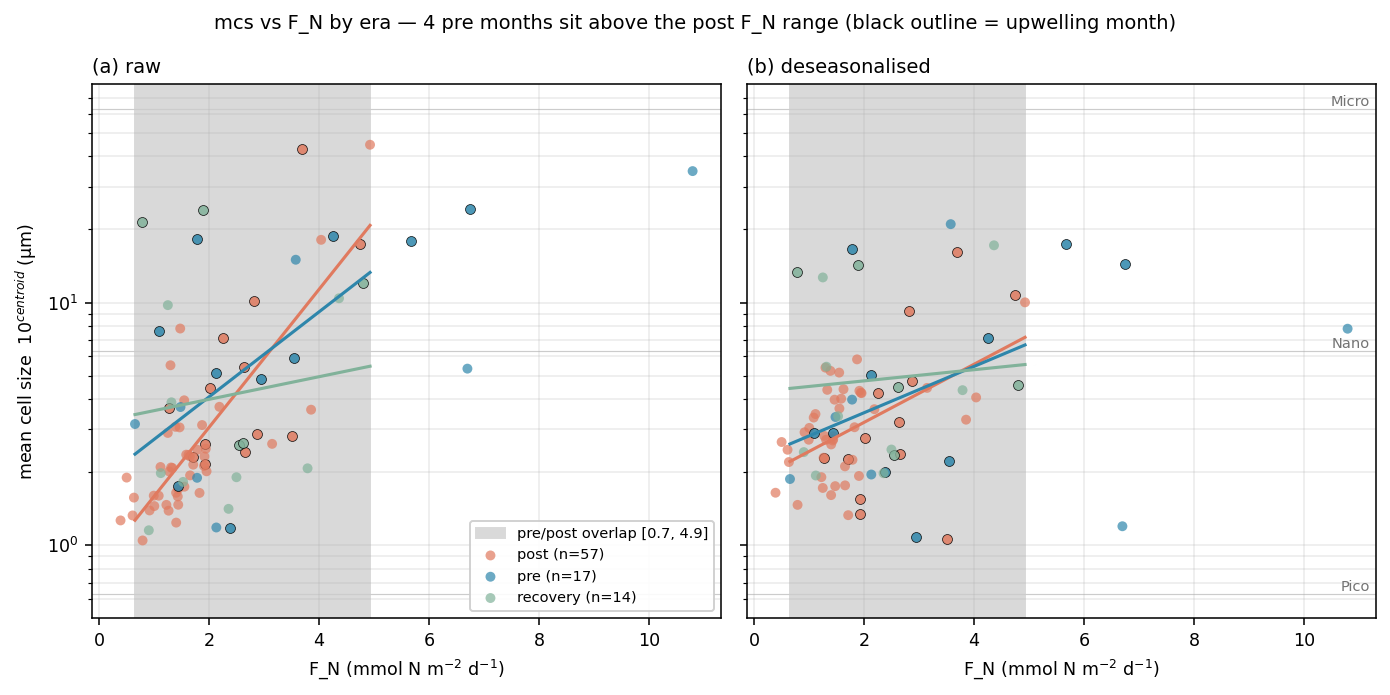

In [4]:
# ============================================================================
# Fig 4 — Step 1 (visual): mcs vs F_N by era, raw | deseasonalised
# Shows the out-of-overlap pre bloom months + the seasonal collapse.
# Self-contained (reloads + recomputes; matches the sweep-table cell).
# ============================================================================
import numpy as np, pandas as pd
import matplotlib.pyplot as plt

try:
    from cariaco_obs import DEFAULT_CSV_PATH as CSV
except Exception:
    CSV = "data/processed/cariaco_monthly_euphotic_dynamic.csv"  # adjust to your path

PHYTO = ["pico_mmolN", "nano_mmolN", "micro_mmolN"]
GEO = np.array([0.63, 6.3, 63.0]); LOG_GEO = np.log10(GEO)
FN = "FN_mmolN_m2_d"
PRE_CUT, REC_CUT = pd.Timestamp("2005-01-01"), pd.Timestamp("2014-01-01")
ERA_C = {"pre": "#2E86AB", "post": "#E07A5F", "recovery": "#81B29A"}  # handover palette

df = pd.read_csv(CSV); df["date"] = pd.to_datetime(df["date"])
P = df[PHYTO].to_numpy(float); tot = P.sum(1)
with np.errstate(invalid="ignore", divide="ignore"):
    fr = np.where(tot[:, None] > 0, P / tot[:, None], np.nan)
df["centroid"] = np.where(tot > 0, np.nansum(fr * LOG_GEO, 1), np.nan)
df["centroid_ds"] = (df["centroid"]
                     - df.groupby(df["date"].dt.month)["centroid"].transform("mean")
                     + df["centroid"].mean())
df["era"] = np.where(df["date"] < PRE_CUT, "pre",
            np.where(df["date"] >= REC_CUT, "recovery", "post"))
df["regime"] = df["regime_adjusted"] if "regime_adjusted" in df.columns else df["upwelling"]
d = df[df["centroid"].notna() & df[FN].notna()].copy()

fp, fq = d.loc[d.era == "pre", FN], d.loc[d.era == "post", FN]
LO, HI = max(fp.min(), fq.min()), min(fp.max(), fq.max())   # pre/post strict overlap
n_pre_above = int((fp > HI).sum())

plt.rcParams.update({"figure.dpi": 140, "font.size": 9})
fig, axes = plt.subplots(1, 2, figsize=(10, 5), sharey=True)
for ax, (ycol, title) in zip(axes, [("centroid", "(a) raw"),
                                     ("centroid_ds", "(b) deseasonalised")]):
    ax.axvspan(LO, HI, color="0.85", zorder=0, label=f"pre/post overlap [{LO:.1f}, {HI:.1f}]")
    for bg in GEO:
        ax.axhline(bg, color="0.8", lw=0.6, zorder=0)
    for era in ["post", "pre", "recovery"]:
        s = d[d.era == era]; up = s.regime == "upwelling"
        ax.scatter(s.loc[up, FN], 10**s.loc[up, ycol], s=26, c=ERA_C[era],
                   edgecolors="k", linewidths=0.4, alpha=0.85, zorder=3)
        ax.scatter(s.loc[~up, FN], 10**s.loc[~up, ycol], s=26, c=ERA_C[era],
                   edgecolors="none", alpha=0.7, zorder=3, label=f"{era} (n={len(s)})")
        w = s[(s[FN] >= LO) & (s[FN] <= HI)]
        if len(w) >= 3:
            b = np.polyfit(w[FN], w[ycol], 1); xx = np.linspace(LO, HI, 20)
            ax.plot(xx, 10**(b[0]*xx + b[1]), color=ERA_C[era], lw=1.6, zorder=4)
    ax.set_yscale("log")
    ax.set_xlabel("F_N (mmol N m$^{-2}$ d$^{-1}$)")
    ax.set_title(title, loc="left", fontsize=10)
    ax.grid(alpha=0.25, which="both")
axes[0].set_ylabel("mean cell size  10$^{centroid}$ (µm)")
trans = axes[1].get_yaxis_transform()
for bg, lab in zip(GEO, ["Pico", "Nano", "Micro"]):
    axes[1].text(0.99, bg, lab, transform=trans, ha="right", va="bottom",
                 fontsize=7.5, color="0.45")
axes[0].legend(fontsize=7.5, loc="lower right", framealpha=0.9)
fig.suptitle(f"mcs vs F_N by era — {n_pre_above} pre months sit above the post F_N range "
             f"(black outline = upwelling month)", fontsize=10)
fig.tight_layout(); plt.show()

regime x fish cross-tab (n):
fish        absent  present
regime                     
relaxed         42       12
transition       2        4
upwelling       13       15 

mcs present(pre+rec) vs absent(post):
  all          present med=4.84µm (n=31) | absent med=2.32µm (n=57) | fold=2.09x | MWU(>)=0.0072
  upwelling    present med=7.66µm (n=15) | absent med=3.69µm (n=13) | fold=2.08x | MWU(>)=0.1068
  relaxed      present med=2.03µm (n=12) | absent med=2.05µm (n=42) | fold=0.99x | MWU(>)=0.1719


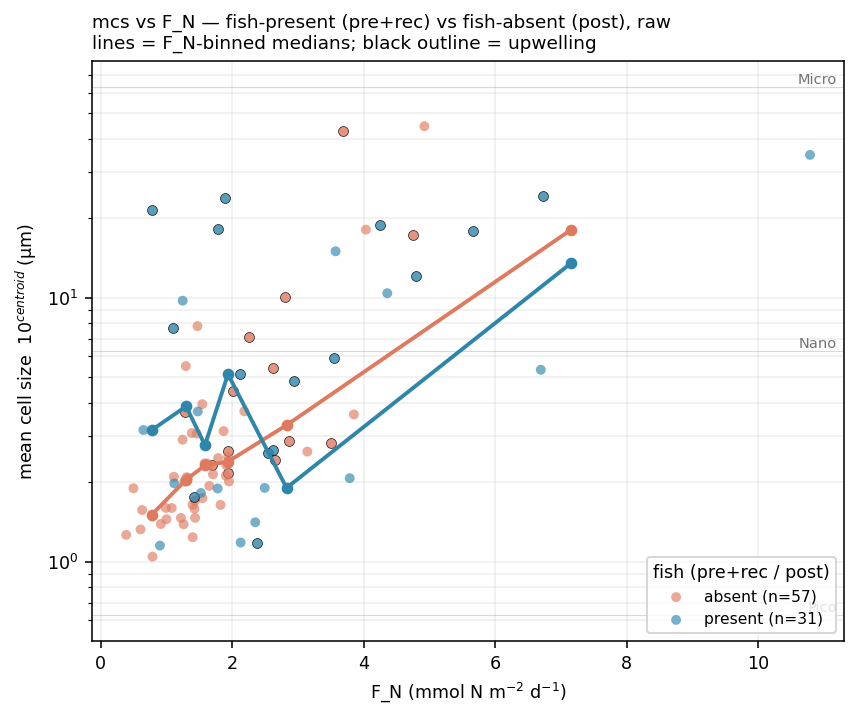

In [5]:
# ============================================================================
# Fig 4 — Step 1 redo: mcs vs F_N, fish-present (pre+rec) vs fish-absent (post),
# RAW, full range. + regime x fish cross-tab + categorical contrast preview
# (a numeric peek at what the 2x2 boxplot would formalize).
# ============================================================================
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu

try:
    from cariaco_obs import DEFAULT_CSV_PATH as CSV
except Exception:
    CSV = "data/processed/cariaco_monthly_euphotic_dynamic.csv"

PHYTO = ["pico_mmolN", "nano_mmolN", "micro_mmolN"]
GEO = np.array([0.63, 6.3, 63.0]); LOG_GEO = np.log10(GEO)
FN = "FN_mmolN_m2_d"
PRE_CUT, REC_CUT = pd.Timestamp("2005-01-01"), pd.Timestamp("2014-01-01")
COL = {"present": "#2E86AB", "absent": "#E07A5F"}

df = pd.read_csv(CSV); df["date"] = pd.to_datetime(df["date"])
P = df[PHYTO].to_numpy(float); tot = P.sum(1)
with np.errstate(invalid="ignore", divide="ignore"):
    fr = np.where(tot[:, None] > 0, P / tot[:, None], np.nan)
df["centroid"] = np.where(tot > 0, np.nansum(fr * LOG_GEO, 1), np.nan)
era = np.where(df["date"] < PRE_CUT, "pre",
       np.where(df["date"] >= REC_CUT, "recovery", "post"))
df["fish"] = np.where(era == "post", "absent", "present")   # pre+recovery = present
df["regime"] = df["regime_adjusted"] if "regime_adjusted" in df.columns else df["upwelling"]
df["mcs"] = 10 ** df["centroid"]
d = df[df["centroid"].notna() & df[FN].notna()].copy()

print("regime x fish cross-tab (n):")
print(pd.crosstab(d["regime"], d["fish"]), "\n")
def contrast(sub, label):
    pres = sub.loc[sub.fish == "present", "mcs"]; abse = sub.loc[sub.fish == "absent", "mcs"]
    if len(pres) >= 3 and len(abse) >= 3:
        p = mannwhitneyu(pres, abse, alternative="greater").pvalue
        print(f"  {label:12s} present med={pres.median():.2f}µm (n={len(pres):2d}) | "
              f"absent med={abse.median():.2f}µm (n={len(abse):2d}) | "
              f"fold={pres.median()/abse.median():.2f}x | MWU(>)={p:.4f}")
    else:
        print(f"  {label:12s} too thin (present n={len(pres)}, absent n={len(abse)})")
print("mcs present(pre+rec) vs absent(post):")
for lab, sub in [("all", d), ("upwelling", d[d.regime=="upwelling"]), ("relaxed", d[d.regime=="relaxed"])]:
    contrast(sub, lab)

plt.rcParams.update({"figure.dpi": 140, "font.size": 9})
fig, ax = plt.subplots(figsize=(6.2, 5.2))
for bg in GEO: ax.axhline(bg, color="0.85", lw=0.6, zorder=0)
bins = np.quantile(d[FN], np.linspace(0, 1, 7)); ctr = 0.5*(bins[:-1]+bins[1:])
for grp in ["absent", "present"]:
    s = d[d.fish == grp]; up = s.regime == "upwelling"
    ax.scatter(s.loc[up, FN], s.loc[up, "mcs"], s=26, c=COL[grp],
               edgecolors="k", linewidths=0.4, alpha=0.8, zorder=3)
    ax.scatter(s.loc[~up, FN], s.loc[~up, "mcs"], s=26, c=COL[grp],
               edgecolors="none", alpha=0.65, zorder=3, label=f"{grp} (n={len(s)})")
    med = [s.loc[(s[FN]>=bins[i]) & (s[FN]<=bins[i+1]), "mcs"].median() for i in range(len(bins)-1)]
    ax.plot(ctr, med, color=COL[grp], lw=2.0, marker="o", ms=5, zorder=5)
ax.set_yscale("log")
ax.set_xlabel("F_N (mmol N m$^{-2}$ d$^{-1}$)"); ax.set_ylabel("mean cell size  10$^{centroid}$ (µm)")
trans = ax.get_yaxis_transform()
for bg, lab in zip(GEO, ["Pico","Nano","Micro"]):
    ax.text(0.99, bg, lab, transform=trans, ha="right", va="bottom", fontsize=7.5, color="0.45")
ax.legend(fontsize=8, loc="lower right", title="fish (pre+rec / post)")
ax.set_title("mcs vs F_N — fish-present (pre+rec) vs fish-absent (post), raw\n"
             "lines = F_N-binned medians; black outline = upwelling", loc="left", fontsize=9.5)
ax.grid(alpha=0.2, which="both"); fig.tight_layout(); plt.show()

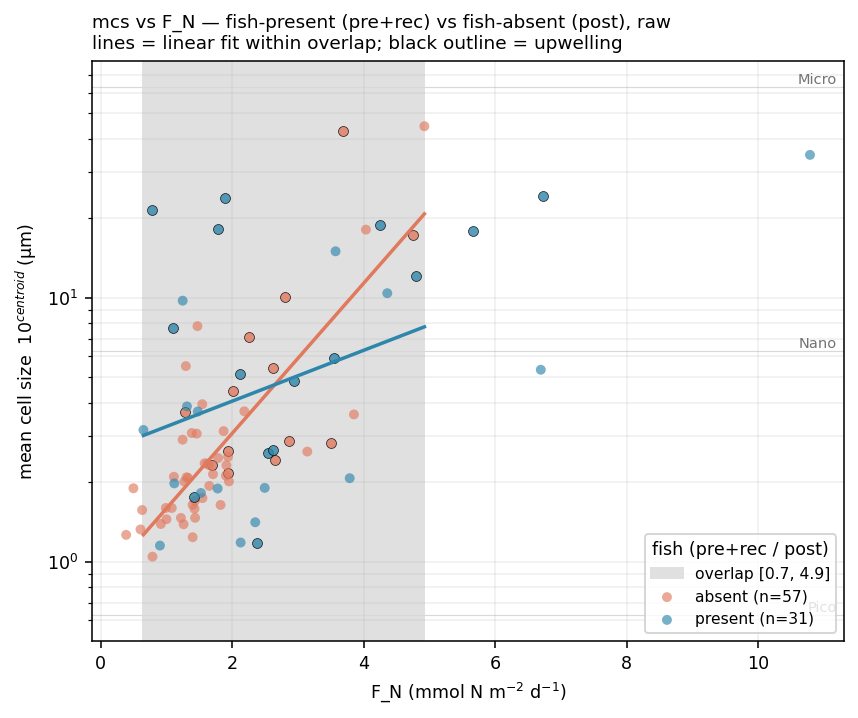

In [6]:
# Fig 4 — Step 1: mcs vs F_N, fish-present (pre+rec) vs fish-absent (post), RAW.
# Same linear fit as the first plot (within the present/absent overlap window).
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
try:
    from cariaco_obs import DEFAULT_CSV_PATH as CSV
except Exception:
    CSV = "data/processed/cariaco_monthly_euphotic_dynamic.csv"

PHYTO = ["pico_mmolN","nano_mmolN","micro_mmolN"]
GEO = np.array([0.63,6.3,63.0]); LOG_GEO = np.log10(GEO)
FN = "FN_mmolN_m2_d"
PRE_CUT, REC_CUT = pd.Timestamp("2005-01-01"), pd.Timestamp("2014-01-01")
COL = {"present":"#2E86AB","absent":"#E07A5F"}

df = pd.read_csv(CSV); df["date"] = pd.to_datetime(df["date"])
P = df[PHYTO].to_numpy(float); tot = P.sum(1)
with np.errstate(invalid="ignore", divide="ignore"):
    fr = np.where(tot[:,None]>0, P/tot[:,None], np.nan)
df["centroid"] = np.where(tot>0, np.nansum(fr*LOG_GEO,1), np.nan)
era = np.where(df["date"]<PRE_CUT,"pre", np.where(df["date"]>=REC_CUT,"recovery","post"))
df["fish"] = np.where(era=="post","absent","present")        # pre+recovery = present
df["regime"] = df["regime_adjusted"] if "regime_adjusted" in df.columns else df["upwelling"]
d = df[df["centroid"].notna() & df[FN].notna()].copy()

fp, fa = d.loc[d.fish=="present",FN], d.loc[d.fish=="absent",FN]
LO, HI = max(fp.min(),fa.min()), min(fp.max(),fa.max())

plt.rcParams.update({"figure.dpi":140,"font.size":9})
fig, ax = plt.subplots(figsize=(6.2,5.2))
ax.axvspan(LO,HI,color="0.88",zorder=0,label=f"overlap [{LO:.1f}, {HI:.1f}]")
for bg in GEO: ax.axhline(bg,color="0.85",lw=0.6,zorder=0)
for grp in ["absent","present"]:
    s = d[d.fish==grp]; up = s.regime=="upwelling"
    ax.scatter(s.loc[up,FN], 10**s.loc[up,"centroid"], s=26, c=COL[grp],
               edgecolors="k", linewidths=0.4, alpha=0.8, zorder=3)
    ax.scatter(s.loc[~up,FN], 10**s.loc[~up,"centroid"], s=26, c=COL[grp],
               edgecolors="none", alpha=0.65, zorder=3, label=f"{grp} (n={len(s)})")
    w = s[(s[FN]>=LO)&(s[FN]<=HI)]
    if len(w)>=3:
        b = np.polyfit(w[FN], w["centroid"], 1); xx = np.linspace(LO,HI,20)
        ax.plot(xx, 10**(b[0]*xx+b[1]), color=COL[grp], lw=1.8, zorder=5)
ax.set_yscale("log")
ax.set_xlabel("F_N (mmol N m$^{-2}$ d$^{-1}$)"); ax.set_ylabel("mean cell size  10$^{centroid}$ (µm)")
trans = ax.get_yaxis_transform()
for bg,lab in zip(GEO,["Pico","Nano","Micro"]):
    ax.text(0.99,bg,lab,transform=trans,ha="right",va="bottom",fontsize=7.5,color="0.45")
ax.legend(fontsize=8, loc="lower right", title="fish (pre+rec / post)")
ax.set_title("mcs vs F_N — fish-present (pre+rec) vs fish-absent (post), raw\n"
             "lines = linear fit within overlap; black outline = upwelling", loc="left", fontsize=9.5)
ax.grid(alpha=0.2, which="both"); fig.tight_layout(); plt.show()

REGIME_SRC = regime_adjusted   (n total = 82)
cell summary [regime x fish]:  n | F_N med[IQR] | mcs med[IQR] µm
  upwelling absent  n=13 | F_N 2.63[1.93,2.86] | mcs 3.69[2.62,7.11]
  upwelling present n=15 | F_N 2.54[1.84,3.90] | mcs 7.66[3.74,18.56]
  relaxed   absent  n=42 | F_N 1.43[1.23,1.70] | mcs 2.05[1.59,2.49]
  relaxed   present n=12 | F_N 1.65[1.30,2.77] | mcs 2.03[1.88,5.35]

fish effect (present vs absent) per regime:
  upwelling raw fold=2.08x (MWU p=0.107) | F_N-controlled fold=1.36x (p=0.373, n=28)
  relaxed   raw fold=0.99x (MWU p=0.172) | F_N-controlled fold=1.12x (p=0.536, n=54)

conditional test (regime x fish interaction on centroid, F_N-controlled):
  C(regime)[T.upwelling]:is_present: coef=+0.062 p=0.669


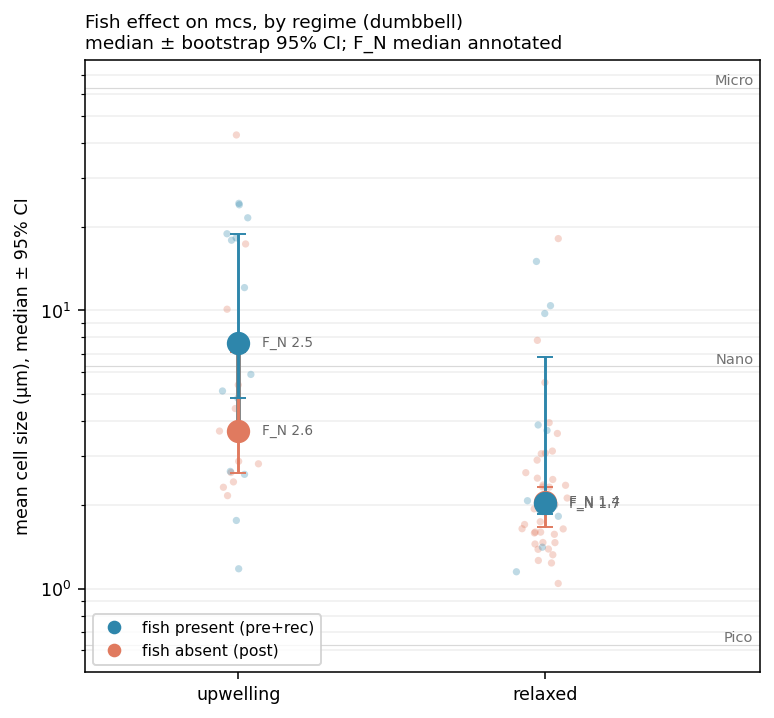

In [7]:
# ============================================================================
# Fig 4 — Step 1: dumbbell view + diagnostic print.
# Dumbbell = median mcs absent->present per regime (bootstrap 95% CI), F_N
# median annotated. Diagnostic: per-cell n/F_N/mcs, raw + F_N-controlled fish
# effect per regime, and the regime x fish interaction (the conditional test).
# ============================================================================
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
from scipy.stats import mannwhitneyu
from matplotlib.lines import Line2D
np.random.seed(0)
try:
    from cariaco_obs import DEFAULT_CSV_PATH as CSV
except Exception:
    CSV = "data/processed/cariaco_monthly_euphotic_dynamic.csv"

PHYTO = ["pico_mmolN","nano_mmolN","micro_mmolN"]
GEO = np.array([0.63,6.3,63.0]); LOG_GEO = np.log10(GEO)
FN = "FN_mmolN_m2_d"
PRE_CUT, REC_CUT = pd.Timestamp("2005-01-01"), pd.Timestamp("2014-01-01")
COL = {"present":"#2E86AB","absent":"#E07A5F"}
REGIME_SRC = "regime_adjusted"   # cleaner; "upwelling" = raw sharp 22C (keeps transition months)

df = pd.read_csv(CSV); df["date"] = pd.to_datetime(df["date"])
P = df[PHYTO].to_numpy(float); tot = P.sum(1)
with np.errstate(invalid="ignore", divide="ignore"):
    fr = np.where(tot[:,None]>0, P/tot[:,None], np.nan)
df["centroid"] = np.where(tot>0, np.nansum(fr*LOG_GEO,1), np.nan)
df["mcs"] = 10**df["centroid"]
era = np.where(df["date"]<PRE_CUT,"pre", np.where(df["date"]>=REC_CUT,"recovery","post"))
df["fish"] = np.where(era=="post","absent","present")
df["regime"] = df[REGIME_SRC] if REGIME_SRC in df.columns else df["upwelling"]
df["is_present"] = (df["fish"]=="present").astype(int)
d = df[df["centroid"].notna() & df[FN].notna() & df["regime"].isin(["upwelling","relaxed"])].copy()

def med_ci(v, n=2000):
    v = np.asarray(v)
    if len(v)<2: return (np.median(v) if len(v) else np.nan), np.nan, np.nan
    bs = [np.median(np.random.choice(v, len(v), replace=True)) for _ in range(n)]
    return np.median(v), np.percentile(bs,2.5), np.percentile(bs,97.5)

# ---------- diagnostic print ----------
print(f"REGIME_SRC = {REGIME_SRC}   (n total = {len(d)})")
print("cell summary [regime x fish]:  n | F_N med[IQR] | mcs med[IQR] µm")
for reg in ["upwelling","relaxed"]:
    for fi in ["absent","present"]:
        s = d[(d.regime==reg)&(d.fish==fi)]
        fq = s[FN].quantile([.25,.5,.75]); mq = s["mcs"].quantile([.25,.5,.75])
        print(f"  {reg:9s} {fi:7s} n={len(s):2d} | "
              f"F_N {fq[.5]:4.2f}[{fq[.25]:.2f},{fq[.75]:.2f}] | "
              f"mcs {mq[.5]:4.2f}[{mq[.25]:.2f},{mq[.75]:.2f}]")
print("\nfish effect (present vs absent) per regime:")
for reg in ["upwelling","relaxed"]:
    s = d[d.regime==reg]; pres, abse = s[s.fish=='present']['mcs'], s[s.fish=='absent']['mcs']
    pmw = mannwhitneyu(pres, abse, alternative='greater').pvalue if min(len(pres),len(abse))>=3 else np.nan
    m = smf.ols(f"centroid ~ {FN} + is_present", data=s).fit()
    print(f"  {reg:9s} raw fold={pres.median()/abse.median():.2f}x (MWU p={pmw:.3f}) | "
          f"F_N-controlled fold={10**m.params['is_present']:.2f}x (p={m.pvalues['is_present']:.3f}, n={len(s)})")
mi = smf.ols(f"centroid ~ {FN} + C(regime)*is_present", data=d).fit()
print("\nconditional test (regime x fish interaction on centroid, F_N-controlled):")
for k in [k for k in mi.pvalues.index if ":" in k]:
    print(f"  {k}: coef={mi.params[k]:+.3f} p={mi.pvalues[k]:.3f}")

# ---------- dumbbell viz ----------
plt.rcParams.update({"figure.dpi":140,"font.size":9})
fig, ax = plt.subplots(figsize=(5.6,5.2))
for bg in GEO: ax.axhline(bg,color="0.85",lw=0.6,zorder=0)
for i,reg in enumerate(["upwelling","relaxed"]):
    x = i+1; st = {}
    for fi in ["absent","present"]:
        v = d[(d.regime==reg)&(d.fish==fi)]["mcs"].values
        st[fi] = med_ci(v)
        ax.scatter(np.random.normal(x,0.03,len(v)), v, s=14, c=COL[fi],
                   edgecolors="none", alpha=0.30, zorder=2)
    ax.plot([x,x],[st['absent'][0],st['present'][0]], color="0.5", lw=2.5, zorder=3)
    for fi in ["absent","present"]:
        m,lo,hi = st[fi]
        ax.errorbar(x, m, yerr=[[m-lo],[hi-m]], fmt='o', ms=11, color=COL[fi],
                    ecolor=COL[fi], elinewidth=1.5, capsize=4, zorder=4)
        fnmed = np.median(d[(d.regime==reg)&(d.fish==fi)][FN])
        ax.annotate(f"F_N {fnmed:.1f}", (x,m), xytext=(12,0), textcoords="offset points",
                    fontsize=7, color="0.4", va="center")
ax.set_yscale("log"); ax.set_xticks([1,2]); ax.set_xticklabels(["upwelling","relaxed"])
ax.set_xlim(0.5,2.7); ax.set_ylabel("mean cell size (µm), median ± 95% CI")
trans = ax.get_yaxis_transform()
for bg,lab in zip(GEO,["Pico","Nano","Micro"]):
    ax.text(0.99,bg,lab,transform=trans,ha="right",va="bottom",fontsize=7.5,color="0.45")
ax.legend(handles=[Line2D([],[],marker='o',ls='',color=COL['present'],label='fish present (pre+rec)'),
                   Line2D([],[],marker='o',ls='',color=COL['absent'],label='fish absent (post)')],
          fontsize=8, loc="lower left")
ax.set_title("Fish effect on mcs, by regime (dumbbell)\nmedian ± bootstrap 95% CI; F_N median annotated",
             loc="left", fontsize=9.5)
ax.grid(alpha=0.2, axis="y", which="both"); fig.tight_layout(); plt.show()

=== era level-shift  ANCOVA  centroid ~ temp + era  (fold = 10^coef) ===
  temp_50m  pre_post      fold=1.52x  p_shift=0.087  p_inter=0.843  n=81
  temp_50m  prerec_post   fold=1.42x  p_shift=0.067  p_inter=0.572  n=95
  Temp_C    pre_post      fold=1.56x  p_shift=0.074  p_inter=0.908  n=80
  Temp_C    prerec_post   fold=1.35x  p_shift=0.127  p_inter=0.298  n=94

=== where it lives: within-regime raw mcs contrast (median fold, MWU>) ===
  upwelling(<=22)  pre/post     fold=2.07x (n=10/16, MWU p=0.081)
  upwelling(<=22)  prerec/post  fold=2.34x (n=15/16, MWU p=0.050)
  relaxed(>22)     pre/post     fold=1.81x (n=7/48, MWU p=0.040)
  relaxed(>22)     prerec/post  fold=1.28x (n=16/48, MWU p=0.100)


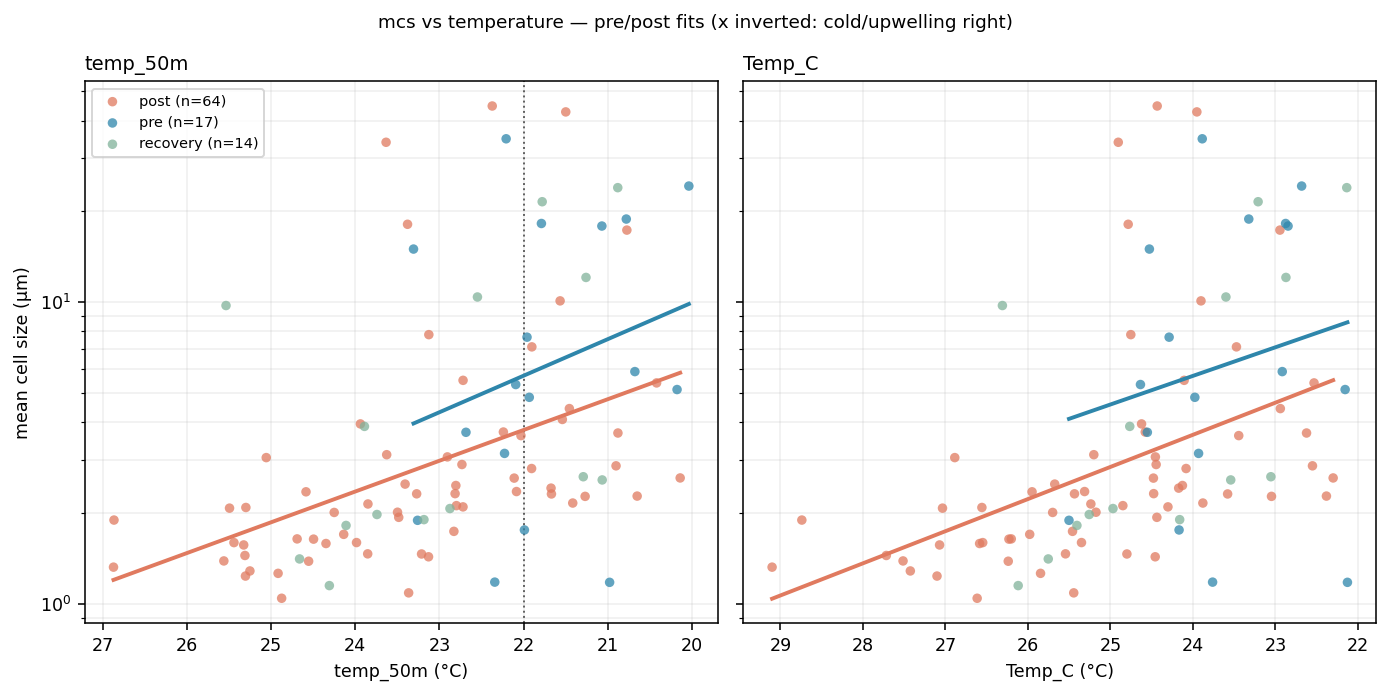

In [8]:
# ============================================================================
# Fig 4 — reconcile with Fig 3: era level-shift on temp_50m vs Temp_C (euphotic),
# pre-vs-post AND pre+rec-vs-post, + WHERE on the temp axis it lives
# (within-upwelling vs within-relaxed). Resolves "does relaxed actually separate?"
# ============================================================================
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
from scipy.stats import mannwhitneyu
try:
    from cariaco_obs import DEFAULT_CSV_PATH as CSV
except Exception:
    CSV = "data/processed/cariaco_monthly_euphotic_dynamic.csv"

PHYTO = ["pico_mmolN","nano_mmolN","micro_mmolN"]; LOG_GEO = np.log10([0.63,6.3,63.0])
PRE_CUT, REC_CUT = pd.Timestamp("2005-01-01"), pd.Timestamp("2014-01-01")
ERA_C = {"pre":"#2E86AB","post":"#E07A5F","recovery":"#81B29A"}

df = pd.read_csv(CSV); df["date"] = pd.to_datetime(df["date"])
P = df[PHYTO].to_numpy(float); tot = P.sum(1)
with np.errstate(invalid="ignore", divide="ignore"):
    fr = np.where(tot[:,None]>0, P/tot[:,None], np.nan)
df["centroid"] = np.where(tot>0, np.nansum(fr*LOG_GEO,1), np.nan)
df["mcs"] = 10**df["centroid"]
df["era"] = np.where(df["date"]<PRE_CUT,"pre", np.where(df["date"]>=REC_CUT,"recovery","post"))

def ancova(tcol, group):
    d2 = df.dropna(subset=["centroid", tcol]).copy()
    if group=="pre_post":
        d2 = d2[d2.era.isin(["pre","post"])]; d2["hi"]=(d2.era=="pre").astype(int)
    else:
        d2 = d2[d2.era.isin(["pre","recovery","post"])]; d2["hi"]=(d2.era!="post").astype(int)
    m  = smf.ols(f"centroid ~ {tcol} + hi", data=d2).fit()
    mi = smf.ols(f"centroid ~ {tcol} * hi", data=d2).fit()
    return 10**m.params["hi"], m.pvalues["hi"], mi.pvalues[f"{tcol}:hi"], len(d2)

print("=== era level-shift  ANCOVA  centroid ~ temp + era  (fold = 10^coef) ===")
for tcol in ["temp_50m","Temp_C"]:
    for grp in ["pre_post","prerec_post"]:
        fold,p,pi,n = ancova(tcol, grp)
        print(f"  {tcol:9s} {grp:12s}  fold={fold:.2f}x  p_shift={p:.3f}  p_inter={pi:.3f}  n={n}")

print("\n=== where it lives: within-regime raw mcs contrast (median fold, MWU>) ===")
d2 = df.dropna(subset=["centroid","temp_50m"])
for side, mask in [("upwelling(<=22)", d2.temp_50m<=22), ("relaxed(>22)", d2.temp_50m>22)]:
    s = d2[mask]
    for grp, hi in [("pre/post", s.era=="pre"), ("prerec/post", s.era!="post")]:
        a, b = s[hi]["mcs"], s[s.era=="post"]["mcs"]
        if min(len(a),len(b))>=3:
            p = mannwhitneyu(a,b,alternative="greater").pvalue
            print(f"  {side:16s} {grp:12s} fold={a.median()/b.median():.2f}x (n={len(a)}/{len(b)}, MWU p={p:.3f})")
        else:
            print(f"  {side:16s} {grp:12s} too thin (n={len(a)}/{len(b)})")

plt.rcParams.update({"figure.dpi":140,"font.size":9})
fig, axes = plt.subplots(1,2, figsize=(10,5), sharey=True)
for ax, tcol in zip(axes, ["temp_50m","Temp_C"]):
    s_all = df.dropna(subset=["centroid", tcol])
    for era in ["post","pre","recovery"]:
        s = s_all[s_all.era==era]
        ax.scatter(s[tcol], s["mcs"], s=24, c=ERA_C[era], edgecolors="none",
                   alpha=0.75, label=f"{era} (n={len(s)})", zorder=3)
    for era in ["pre","post"]:           # Fig 3 comparison: pre vs post fits
        s = s_all[s_all.era==era]
        if len(s)>=3:
            b = np.polyfit(s[tcol], s["centroid"],1); xx=np.linspace(s[tcol].min(),s[tcol].max(),20)
            ax.plot(xx, 10**(b[0]*xx+b[1]), color=ERA_C[era], lw=2, zorder=4)
    if tcol=="temp_50m": ax.axvline(22, ls=":", c="k", lw=1, alpha=0.6)
    ax.invert_xaxis(); ax.set_yscale("log")
    ax.set_xlabel(f"{tcol} (°C)"); ax.grid(alpha=0.2, which="both"); ax.set_title(tcol, loc="left", fontsize=10)
axes[0].set_ylabel("mean cell size (µm)"); axes[0].legend(fontsize=7.5, loc="upper left")
fig.suptitle("mcs vs temperature — pre/post fits (x inverted: cold/upwelling right)", fontsize=9.5)
fig.tight_layout(); plt.show()

metric             | regime    | present med (n) | absent med (n) | MWU p
  mcs (µm)           upwelling pres=7.66 (n=15) | abs=3.28 (n=16) | p=0.101
  mcs (µm)           relaxed   pres=2.03 (n=12) | abs=2.01 (n=46) | p=0.295
  Micro fraction     upwelling pres=0.424 (n=15) | abs=0.181 (n=16) | p=0.109
  Micro fraction     relaxed   pres=0.139 (n=12) | abs=0.0866 (n=46) | p=0.097
  Nano fraction      upwelling pres=0.193 (n=15) | abs=0.255 (n=16) | p=0.093
  Nano fraction      relaxed   pres=0.217 (n=12) | abs=0.268 (n=46) | p=0.153
  Pico fraction      upwelling pres=0.339 (n=15) | abs=0.498 (n=16) | p=0.199
  Pico fraction      relaxed   pres=0.59 (n=12) | abs=0.607 (n=46) | p=0.393
  Zoo >200 (mmolN)   upwelling pres=0.0566 (n=23) | abs=0.0866 (n=28) | p=0.000
  Zoo >200 (mmolN)   relaxed   pres=0.0364 (n=31) | abs=0.0481 (n=59) | p=0.051
  PhaeoChl ratio     upwelling pres=0.816 (n=50) | abs=1.01 (n=28) | p=0.015
  PhaeoChl ratio     relaxed   pres=1.03 (n=51) | abs=1.09 (n=57) | p

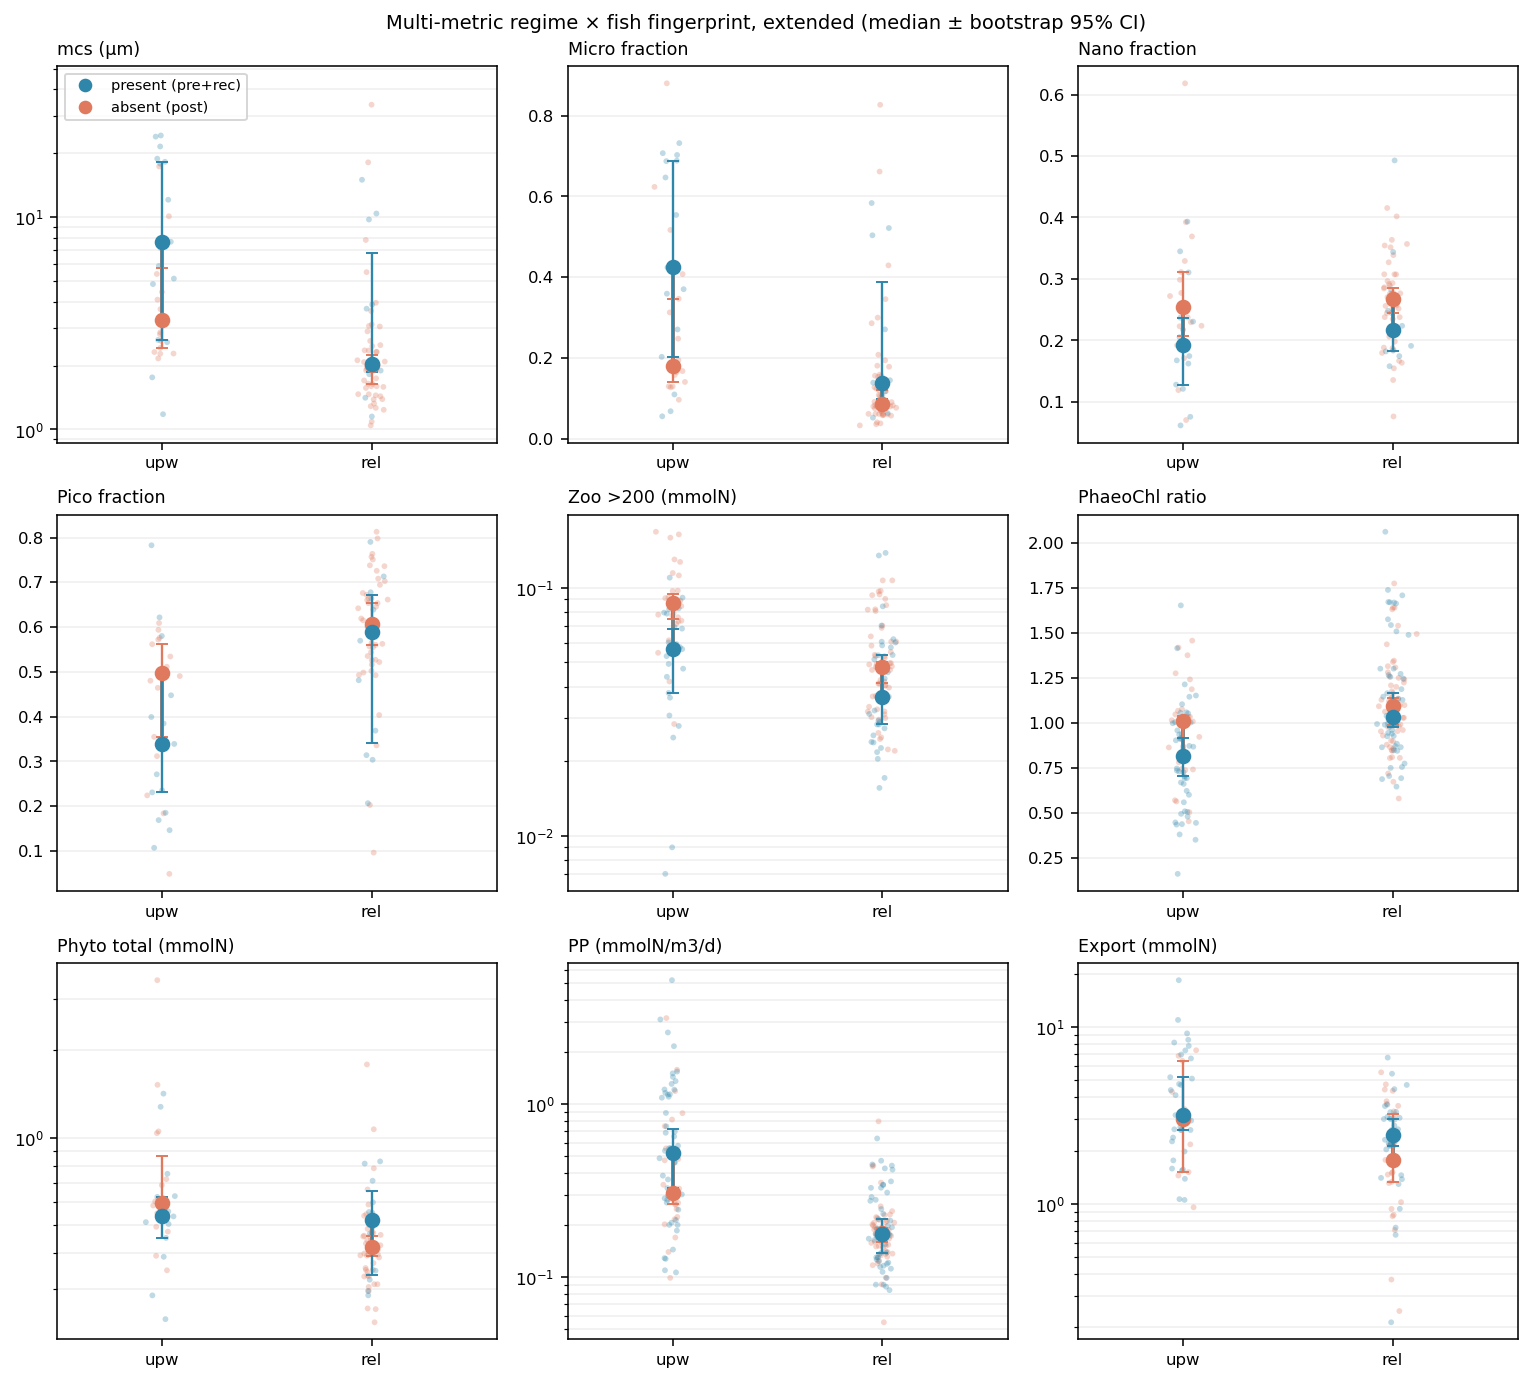

In [13]:
# ============================================================================
# Fig 4 — Step 1: multi-metric regime x fish fingerprint, EXTENDED.
# Adds phyto total biomass, PP, export to mcs + composition + zoo + PhaeoChl.
# regime_adjusted (clean), fish = pre+rec (present) vs post (absent).
# ============================================================================
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu
from matplotlib.lines import Line2D
np.random.seed(0)
try:
    from cariaco_obs import DEFAULT_CSV_PATH as CSV
except Exception:
    CSV = "data/processed/cariaco_monthly_euphotic_dynamic.csv"

PHYTO = ["pico_mmolN","nano_mmolN","micro_mmolN"]; LOG_GEO = np.log10([0.63,6.3,63.0])
PRE_CUT, REC_CUT = pd.Timestamp("2005-01-01"), pd.Timestamp("2014-01-01")
COL = {"present":"#2E86AB","absent":"#E07A5F"}

df = pd.read_csv(CSV); df["date"] = pd.to_datetime(df["date"])
A = df[PHYTO].to_numpy(float); tot = A.sum(1)
with np.errstate(invalid="ignore", divide="ignore"):
    fr = np.where(tot[:,None]>0, A/tot[:,None], np.nan)
df["centroid"] = np.where(tot>0, np.nansum(fr*LOG_GEO,1), np.nan)
df["mcs"]=10**df["centroid"]; df["pico_frac"],df["nano_frac"],df["micro_frac"]=fr[:,0],fr[:,1],fr[:,2]
df["phyto_total"] = tot                                  # ΣP (mmolN), HPLC-complete months only
era = np.where(df["date"]<PRE_CUT,"pre", np.where(df["date"]>=REC_CUT,"recovery","post"))
df["fish"] = np.where(era=="post","absent","present")
df["regime"] = df["regime_adjusted"] if "regime_adjusted" in df.columns else df["upwelling"]
d = df[df["regime"].isin(["upwelling","relaxed"])].copy()

metrics = [("mcs","mcs (µm)",True),("micro_frac","Micro fraction",False),
           ("nano_frac","Nano fraction",False),("pico_frac","Pico fraction",False),
           ("zoo_gt200_mmolN","Zoo >200 (mmolN)",True),("PhaeoChl_ratio","PhaeoChl ratio",False),
           ("phyto_total","Phyto total (mmolN)",True),("PP_mmolN_m3_d","PP (mmolN/m3/d)",True),
           ("export_flux_corrected_mmolN","Export (mmolN)",True)]

def med_ci(v,n=2000):
    v=np.asarray(v,float); v=v[np.isfinite(v)]
    if len(v)<2: return (v.mean() if len(v) else np.nan),np.nan,np.nan
    bs=[np.median(np.random.choice(v,len(v),True)) for _ in range(n)]
    return np.median(v),np.percentile(bs,2.5),np.percentile(bs,97.5)

print("metric             | regime    | present med (n) | absent med (n) | MWU p")
for col,lab,_ in metrics:
    if col not in d.columns: print(f"  {lab}: column missing"); continue
    for reg in ["upwelling","relaxed"]:
        s=d[d.regime==reg]; pv=s[s.fish=="present"][col].dropna(); av=s[s.fish=="absent"][col].dropna()
        p=mannwhitneyu(pv,av).pvalue if min(len(pv),len(av))>=3 else np.nan
        print(f"  {lab:18s} {reg:9s} pres={pv.median():.3g} (n={len(pv):2d}) | "
              f"abs={av.median():.3g} (n={len(av):2d}) | p={p:.3f}")

plt.rcParams.update({"figure.dpi":140,"font.size":8.5})
fig, axes = plt.subplots(3,3, figsize=(11,10))
for ax,(col,lab,logy) in zip(axes.flat, metrics):
    if col not in d.columns: ax.set_title(f"[missing] {lab}"); ax.axis("off"); continue
    for i,reg in enumerate(["upwelling","relaxed"]):
        x=i+1; st={}
        for fi in ["absent","present"]:
            v=d[(d.regime==reg)&(d.fish==fi)][col].dropna().values; st[fi]=med_ci(v)
            ax.scatter(np.random.normal(x,0.03,len(v)), v, s=9, c=COL[fi], edgecolors="none", alpha=0.30, zorder=2)
        ax.plot([x,x],[st['absent'][0],st['present'][0]], color="0.5", lw=2, zorder=3)
        for fi in ["absent","present"]:
            m,lo,hi=st[fi]
            ax.errorbar(x,m,yerr=([[m-lo],[hi-m]] if np.isfinite(lo) else None), fmt='o',
                        ms=7, color=COL[fi], ecolor=COL[fi], elinewidth=1.2, capsize=3, zorder=4)
    if logy: ax.set_yscale("log")
    ax.set_xticks([1,2]); ax.set_xticklabels(["upw","rel"]); ax.set_xlim(0.5,2.6)
    ax.set_title(lab, loc="left", fontsize=9); ax.grid(alpha=0.2, axis="y", which="both")
axes[0,0].legend(handles=[Line2D([],[],marker='o',ls='',color=COL['present'],label='present (pre+rec)'),
                          Line2D([],[],marker='o',ls='',color=COL['absent'],label='absent (post)')],
                 fontsize=7.5, loc="upper left")
fig.suptitle("Multi-metric regime × fish fingerprint, extended (median ± bootstrap 95% CI)", fontsize=10)
fig.tight_layout(); plt.show()